<a href="https://colab.research.google.com/github/SOVERSSINGH/GitHub_Actions_Demo/blob/main/Final__10_2_26_5F_Net_6000_KuAN_SoftU_CoHS_ISO_5Fold_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIKA-Net — 6,000 Papaya Colab Pipeline

**KuAN + first-kind Chebyshev + Soft-U + CoHS + ISO + KuAN cross-modal fusion + multi-task learning + controlled 3-fold ablation**

This notebook is based on the supplied 6,000-row papaya setup: 6 disease classes, 3 soil-health classes, and the six primary variables `soil_ph`, `nitrogen`, `phosphorus`, `potassium`, `moisture`, `temperature`. It keeps the supplied image convention `images/disease_label/image_id`.

The design fixes the reviewed issues: train-only scaling, corrected focal loss, correct yield-column handling, group-aware splitting when a real group field exists, Colab-safe DataLoader defaults, no forced CUDA deterministic algorithms, explicit ISO-vs-AdamW ablation, untouched test set, and reproducible 3-fold ablations.

**Important:** >99% is a target, not a guaranteed result. The notebook reports the observed held-out performance and never fabricates accuracy.


In [1]:
# ============================================================
# 1. COLAB-SAFE SETUP / IMPORTS
# ============================================================

# IMPORTANT:
# Do NOT upgrade NumPy, Pandas, Torch or Torchvision in Colab.
# Repair Pillow only, using one exact version so that all Pillow
# modules come from the same release.

!python -m pip uninstall -y -q Pillow
!python -m pip install -q --no-cache-dir --no-deps Pillow==11.3.0

import os
import gc
import json
import math
import time
import copy
import random
import warnings
import zipfile

from pathlib import Path

import numpy as np
import pandas as pd

# Import Pillow AFTER the repair
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# torchvision is imported only after Pillow is repaired
from torchvision import transforms

from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("SIKA-Net Colab Environment")
print("=" * 60)

print("PyTorch :", torch.__version__)
print("NumPy   :", np.__version__)
print("Pandas  :", pd.__version__)
print("Pillow  :", Image.__version__)
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print("CUDA    :", torch.version.cuda)

print("=" * 60)
print("Environment initialized successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 89.0 MB/s eta 0:00:00
SIKA-Net Colab Environment
PyTorch : 2.11.0+cu130
NumPy   : 2.1.3
Pandas  : 2.2.3
Pillow  : 11.3.0
Device  : cuda
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA    : 13.0
Environment initialized successfully.


In [2]:
# CONFIGURATION
SEED=42; EXPECTED_N=6000; IMG_SIZE=256; PATCH_SIZE=16
BATCH_SIZE=16; NUM_WORKERS=0; PIN_MEMORY=torch.cuda.is_available()
EPOCHS=60; PATIENCE=12; N_FOLDS=5
EMBED=384; TOKEN_DIM=128; IMAGE_DEPTH=3; CHEB_ORDER_IMAGE=6; CHEB_ORDER_SOIL=5; SOIL_HIDDEN=192; FUSION_RANK=64; DROPOUT=.08
LR=3e-4; WEIGHT_DECAY=5e-5; GRAD_CLIP=1.0
LAMBDA_DISEASE=1.0; LAMBDA_SOIL=.35; LAMBDA_YIELD=.03
USE_YIELD_TASK=True; USE_TTA=True; TARGET_ACCURACY=.99
RUN_ABLATIONS=False
ABLATION_VARIANTS=['Full','No_ISO','No_KuAN','No_CrossModal','Image_Only','Soil_Only','No_Gate']
USE_DRIVE=True; DRIVE_ROOT='/content/drive/MyDrive/TEST6/Papaya_Aug_Dataset'
CSV_FILENAME='/content/drive/MyDrive/TEST6/papaya_dataset_balanced_6000.csv'; ZIP_FILENAME='Zipped_6000 Papaya.zip'; IMAGE_FOLDER_NAME='images'
OUT=Path('/content/sika_net_results'); OUT.mkdir(parents=True,exist_ok=True)
SOIL_COLS=['soil_ph','nitrogen','phosphorus','potassium','moisture','temperature']

def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED']=str(seed); random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
seed_everything(SEED)


In [3]:
# ============================================================
# DATA ACQUISITION + AUDIT
# Existing Google Drive dataset — NO ZIP REQUIRED
# ============================================================

from google.colab import drive
from pathlib import Path
import os
import pandas as pd

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount('/content/drive')

# ------------------------------------------------------------
# 2. Exact dataset paths
# ------------------------------------------------------------

DRIVE_CSV_PATH = (
    "/content/drive/MyDrive/TEST6/"
    "papaya_dataset_balanced_6000.csv"
)

DRIVE_IMAGE_FOLDER_PATH = (
    "/content/drive/MyDrive/TEST6/"
    "Papaya_Aug_Dataset"
)

csv_path = Path(DRIVE_CSV_PATH)
image_root = Path(DRIVE_IMAGE_FOLDER_PATH)

print("=" * 70)
print("SIKA-Net DATASET CONFIGURATION")
print("=" * 70)

print("CSV:")
print(csv_path)

print("\nImage folder:")
print(image_root)

# ------------------------------------------------------------
# 3. Validate CSV
# ------------------------------------------------------------

if not csv_path.exists():
    raise FileNotFoundError(
        f"\nCSV file was not found:\n{csv_path}\n"
    )

if not csv_path.is_file():
    raise ValueError(
        f"\nCSV path is not a file:\n{csv_path}\n"
    )

# ------------------------------------------------------------
# 4. Validate image folder
# ------------------------------------------------------------

if not image_root.exists():
    raise FileNotFoundError(
        f"\nImage folder was not found:\n{image_root}\n"
    )

if not image_root.is_dir():
    raise ValueError(
        f"\nImage path is not a directory:\n{image_root}\n"
    )

print("\nPath validation: PASSED")

# ------------------------------------------------------------
# 5. Load CSV
# ------------------------------------------------------------

df = pd.read_csv(csv_path)

print("\nCSV loaded successfully.")
print("CSV shape:", df.shape)

# ------------------------------------------------------------
# 6. Validate required columns
# ------------------------------------------------------------

required = [
    'image_id',
    'disease_label',
    *SOIL_COLS,
    'soil_health'
]

missing = [
    col for col in required
    if col not in df.columns
]

if missing:
    raise ValueError(
        "\nMissing required columns:\n"
        + "\n".join(f"  - {x}" for x in missing)
        + "\n\nAvailable columns:\n"
        + "\n".join(f"  - {x}" for x in df.columns)
    )

print("\nRequired CSV columns: PASSED")

# ------------------------------------------------------------
# 7. Find images
# ------------------------------------------------------------

def find_image_file(root, disease_label, image_id):

    disease_dir = root / str(disease_label)

    image_id = str(image_id)

    # --------------------------------------------------------
    # Case 1: image_id already contains extension
    # --------------------------------------------------------

    direct = disease_dir / image_id

    if direct.exists():
        return direct

    # --------------------------------------------------------
    # Case 2: image_id has no extension
    # --------------------------------------------------------

    extensions = [
        ".jpg",
        ".jpeg",
        ".png",
        ".JPG",
        ".JPEG",
        ".PNG",
        ".webp",
        ".WEBP"
    ]

    for ext in extensions:

        candidate = disease_dir / (image_id + ext)

        if candidate.exists():
            return candidate

    return None


print("\nLocating images...")
print("Image root:", image_root)

image_paths = []

for _, row in df.iterrows():

    path = find_image_file(
        image_root,
        row["disease_label"],
        row["image_id"]
    )

    if path is None:
        image_paths.append("")
    else:
        image_paths.append(str(path))

df["image_path"] = image_paths

df["exists"] = df["image_path"].apply(
    lambda x: bool(x) and os.path.exists(x)
)

# ------------------------------------------------------------
# 8. Image audit
# ------------------------------------------------------------

total_images = len(df)

found_images = int(
    df["exists"].sum()
)

missing_images = total_images - found_images

print("\n" + "=" * 70)
print("IMAGE AUDIT")
print("=" * 70)

print("CSV rows       :", total_images)
print("Images found   :", found_images)
print("Images missing :", missing_images)

# ------------------------------------------------------------
# 9. Stop if images are missing
# ------------------------------------------------------------

if missing_images > 0:

    print("\nFirst missing images:")

    print(
        df.loc[
            ~df["exists"],
            ["image_id", "disease_label"]
        ]
        .head(20)
        .to_string(index=False)
    )

    raise FileNotFoundError(
        f"\n{missing_images} images could not be found."
    )

# ------------------------------------------------------------
# 10. Disease classes
# ------------------------------------------------------------

DISEASE_CLASSES = sorted(
    df["disease_label"]
    .astype(str)
    .unique()
)

SOIL_CLASSES = sorted(
    df["soil_health"]
    .astype(str)
    .unique()
)

disease_to_id = {
    label: i
    for i, label in enumerate(DISEASE_CLASSES)
}

soil_to_id = {
    label: i
    for i, label in enumerate(SOIL_CLASSES)
}

df["disease_id"] = (
    df["disease_label"]
    .astype(str)
    .map(disease_to_id)
)

df["soil_id"] = (
    df["soil_health"]
    .astype(str)
    .map(soil_to_id)
)

# ------------------------------------------------------------
# 11. Final dataset audit
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET AUDIT")
print("=" * 70)

print("Total rows       :", len(df))
print("Disease classes  :", len(DISEASE_CLASSES))
print("Disease labels   :", DISEASE_CLASSES)

print("Soil classes     :", len(SOIL_CLASSES))
print("Soil labels      :", SOIL_CLASSES)

print("\nDisease distribution:")
print(
    df["disease_label"]
    .value_counts()
    .sort_index()
)

print("\nSoil-health distribution:")
print(
    df["soil_health"]
    .value_counts()
    .sort_index()
)

print("\nExample image paths:")
print(
    df[
        ["image_id", "disease_label", "image_path"]
    ]
    .head(5)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("DATASET AUDIT COMPLETED SUCCESSFULLY")
print("=" * 70)

Mounted at /content/drive
SIKA-Net DATASET CONFIGURATION
CSV:
/content/drive/MyDrive/TEST6/papaya_dataset_balanced_6000.csv

Image folder:
/content/drive/MyDrive/TEST6/Papaya_Aug_Dataset

Path validation: PASSED

CSV loaded successfully.
CSV shape: (6000, 16)

Required CSV columns: PASSED

Locating images...
Image root: /content/drive/MyDrive/TEST6/Papaya_Aug_Dataset

IMAGE AUDIT
CSV rows       : 6000
Images found   : 6000
Images missing : 0

DATASET AUDIT
Total rows       : 6000
Disease classes  : 6
Disease labels   : ['Bacterial_Blight', 'Carica_Insect_Hole', 'Curled_Yellow_Spot', 'Yellow_Necrotic_Spots_Holes', 'healthy_leaf', 'pathogen_symptoms']
Soil classes     : 3
Soil labels      : ['Critical', 'Moderate Risk', 'Optimal']

Disease distribution:
disease_label
Bacterial_Blight               1000
Carica_Insect_Hole             1000
Curled_Yellow_Spot             1000
Yellow_Necrotic_Spots_Holes    1000
healthy_leaf                   1000
pathogen_symptoms              1000
Name: co

In [4]:
# LEAKAGE-AWARE TEST SPLIT + SOIL FEATURES
GROUP_CANDIDATES=['source_image_id','plant_id','patient_id','session_id','sample_id','group_id','image_group']
GROUP_COLUMN=next((x for x in GROUP_CANDIDATES if x in df.columns and df[x].nunique()<len(df)),None)
if GROUP_COLUMN is None and df.image_id.duplicated(keep=False).any(): GROUP_COLUMN='image_id'
all_idx=np.arange(len(df)); joint=(df.disease_label.astype(str)+'||'+df.soil_health.astype(str)).values
if GROUP_COLUMN:
    groups=df[GROUP_COLUMN].astype(str).values
    sg=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED); _,test_idx=next(sg.split(all_idx,joint,groups))
    trainval_idx=np.setdiff1d(all_idx,test_idx)
else:
    trainval_idx,test_idx=train_test_split(all_idx,test_size=.15,random_state=SEED,stratify=joint)
trainval_df=df.iloc[trainval_idx].reset_index(drop=True); test_df=df.iloc[test_idx].reset_index(drop=True)
print('trainval',len(trainval_df),'test',len(test_df),'group',GROUP_COLUMN)
if GROUP_COLUMN: assert not (set(trainval_df[GROUP_COLUMN].astype(str)) & set(test_df[GROUP_COLUMN].astype(str)))
EPS=1e-6
def engineer(frame):
    x=frame[SOIL_COLS].astype(float).copy(); x['npk_total']=x.nitrogen+x.phosphorus+x.potassium; x['npk_mean']=x.npk_total/3
    x['n_p_ratio']=x.nitrogen/(x.phosphorus+EPS); x['n_k_ratio']=x.nitrogen/(x.potassium+EPS); x['p_k_ratio']=x.phosphorus/(x.potassium+EPS)
    a=x[['nitrogen','phosphorus','potassium']].values; x['nutrient_std']=a.std(1); x['nutrient_cv']=x.nutrient_std/(np.abs(x.npk_mean)+EPS)
    x['ph_deviation_6']=np.abs(x.soil_ph-6); x['ph_deviation_6_5']=np.abs(x.soil_ph-6.5); x['moisture_temp']=x.moisture*x.temperature; x['npk_temperature']=x.npk_total/(x.temperature+EPS); x['npk_moisture']=x.npk_total*x.moisture/100
    x['ph_sin']=np.sin(x.soil_ph); x['ph_cos']=np.cos(x.soil_ph); x['temp_sin']=np.sin(x.temperature/10); x['temp_cos']=np.cos(x.temperature/10)
    x['ph_sq']=x.soil_ph**2; x['moisture_sq']=x.moisture**2; x['temperature_sq']=x.temperature**2
    return x.replace([np.inf,-np.inf],np.nan).fillna(0)
FEATURE_COLS=engineer(trainval_df).columns.tolist(); print('engineered features',len(FEATURE_COLS))


trainval 4819 test 1181 group source_image_id
engineered features 25


In [5]:
# DATASET + TRANSFORMS
MEAN=[.485,.456,.406]; STD=[.229,.224,.225]
train_tfms=transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE,scale=(.88,1),ratio=(.90,1.10)),transforms.RandomHorizontalFlip(.5),transforms.RandomVerticalFlip(.15),transforms.RandomRotation(8),transforms.ColorJitter(.08,.08,.06,.01),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_tfms=transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(IMG_SIZE),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
class PapayaDataset(Dataset):
    def __init__(self,frame,scaler,transform,use_yield=True):
        self.f=frame.reset_index(drop=True).copy(); self.transform=transform; self.use_yield=use_yield and 'yield_kg_per_plant' in self.f.columns
        raw=engineer(self.f)[FEATURE_COLS].astype(np.float32); self.soil=scaler.transform(raw).astype(np.float32)
        self.y=np.nan_to_num(pd.to_numeric(self.f['yield_kg_per_plant'],errors='coerce').values.astype(np.float32)) if self.use_yield else np.zeros(len(self.f),np.float32)
    def __len__(self): return len(self.f)
    def __getitem__(self,i):
        r=self.f.iloc[i]
        with Image.open(r.image_path) as im: im=im.convert('RGB')
        return {'image':self.transform(im),'soil_features':torch.tensor(self.soil[i]),'disease':torch.tensor(int(r.disease_id),dtype=torch.long),'soil':torch.tensor(int(r.soil_id),dtype=torch.long),'yield':torch.tensor(float(self.y[i]))}
def loader(ds,shuffle): return DataLoader(ds,batch_size=BATCH_SIZE,shuffle=shuffle,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY,persistent_workers=False)


## Model: KuAN + Soft-U + CoHS + cross-modal functional fusion

The image path uses patchification followed by learnable first-kind Chebyshev functional mappings and Soft-U. The soil path uses a compact CoHS-style harmonic interaction encoder. Fusion is a low-rank bivariate KuAN interaction plus a learned image/soil gate. The yield head is auxiliary and is disabled automatically if the target column is absent.


In [6]:
# FUNCTIONAL MODULES
class SoftU(nn.Module):
    def __init__(self):
        super().__init__(); self.neg=nn.Parameter(torch.tensor(.20)); self.pos=nn.Parameter(torch.tensor(1.0)); self.temp=nn.Parameter(torch.tensor(1.0))
    def forward(self,x):
        t=F.softplus(self.temp)+1e-4; g=.5*(F.softsign(x/t)+1); return (1-g)*F.softplus(self.neg)*x+g*F.softplus(self.pos)*x
class ChebFunctional(nn.Module):
    def __init__(self,d,o=None,k=6,drop=.05):
        super().__init__(); o=o or d; self.k=k; self.norm=nn.LayerNorm(d); self.c=nn.Parameter(torch.randn(k+1,d,o)*.012); self.b=nn.Parameter(torch.zeros(o)); self.u=SoftU(); self.drop=nn.Dropout(drop)
    def forward(self,x):
        z=torch.tanh(self.norm(x)); B=[torch.ones_like(z)]
        if self.k>=1:
            t0=B[0]; t1=z; B.append(t1)
            for _ in range(2,self.k+1): t2=2*z*t1-t0; B.append(t2); t0,t1=t1,t2
        b=torch.stack(B,-1); y=torch.einsum('bnk,kdo->bno',b,self.c)+self.b; return self.drop(self.u(y))
class KuANBlock(nn.Module):
    def __init__(self,d,k=6,drop=.08):
        super().__init__(); self.f=ChebFunctional(d,d,k,drop); self.ff=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,2*d),nn.GELU(),nn.Dropout(drop),nn.Linear(2*d,d)); self.n=nn.LayerNorm(d)
    def forward(self,x): return self.n(x+self.f(x)+self.ff(x+self.f(x)))
class KuANImage(nn.Module):
    def __init__(self):
        super().__init__(); pd=3*PATCH_SIZE*PATCH_SIZE; nt=(IMG_SIZE//PATCH_SIZE)**2; self.p=nn.Sequential(nn.LayerNorm(pd),nn.Linear(pd,TOKEN_DIM),nn.GELU()); self.pos=nn.Parameter(torch.zeros(1,nt,TOKEN_DIM)); nn.init.trunc_normal_(self.pos,std=.02); self.blocks=nn.Sequential(*[KuANBlock(TOKEN_DIM,CHEB_ORDER_IMAGE,DROPOUT) for _ in range(IMAGE_DEPTH)]); self.out=nn.Sequential(nn.LayerNorm(TOKEN_DIM),nn.Linear(TOKEN_DIM,EMBED),nn.GELU(),nn.Dropout(DROPOUT))
    def forward(self,x):
        z=F.unfold(x,PATCH_SIZE,PATCH_SIZE).transpose(1,2); z=self.p(z)+self.pos[:,:z.size(1)]; z=self.blocks(z); z=.5*(z.mean(1)+z.max(1).values); return self.out(z)
class CoHS(nn.Module):
    def __init__(self,d):
        super().__init__(); self.inp=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,SOIL_HIDDEN),nn.GELU()); self.mix=nn.Sequential(nn.Linear(SOIL_HIDDEN*2,SOIL_HIDDEN),nn.GELU(),nn.Linear(SOIL_HIDDEN,SOIL_HIDDEN)); self.f=ChebFunctional(SOIL_HIDDEN,EMBED,CHEB_ORDER_SOIL,DROPOUT)
    def forward(self,x):
        h=self.inp(x); m=h.mean(1,keepdim=True); q=torch.cat([h,torch.sin(h-m),torch.cos(h-m)],1)[:,:2*h.size(1)]; q=self.mix(q).unsqueeze(1); return self.f(q).squeeze(1)
class CrossFusion(nn.Module):
    def __init__(self):
        super().__init__(); self.i=nn.Linear(EMBED,FUSION_RANK); self.s=nn.Linear(EMBED,FUSION_RANK); self.mix=nn.Sequential(nn.Linear(FUSION_RANK**2,EMBED),nn.GELU(),nn.Dropout(DROPOUT),nn.Linear(EMBED,EMBED),nn.LayerNorm(EMBED)); self.g=nn.Sequential(nn.Linear(2*EMBED,EMBED),nn.GELU(),nn.Linear(EMBED,1))
    def forward(self,a,b,use_gate=True):
        q=torch.tanh(self.i(a)); r=torch.tanh(self.s(b)); z=self.mix(torch.einsum('bi,bj->bij',q,r).flatten(1))
        if use_gate:
            g=torch.sigmoid(self.g(torch.cat([a,b],1))); return z+g*a+(1-g)*b,g
        return z+a+b,None
class SIKANet(nn.Module):
    def __init__(self,variant='Full'):
        super().__init__(); self.kuan=variant!='No_KuAN'; self.cross=variant!='No_CrossModal'; self.gate=variant!='No_Gate'
        self.img=KuANImage() if self.kuan else nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Linear(3,EMBED),nn.GELU(),nn.LayerNorm(EMBED))
        self.soil=CoHS(len(FEATURE_COLS)) if self.kuan else nn.Sequential(nn.Linear(len(FEATURE_COLS),SOIL_HIDDEN),nn.GELU(),nn.Linear(SOIL_HIDDEN,EMBED),nn.LayerNorm(EMBED))
        self.fuse=CrossFusion(); self.simple=nn.Sequential(nn.Linear(2*EMBED,EMBED),nn.GELU(),nn.LayerNorm(EMBED))
        self.d=nn.Sequential(nn.Linear(EMBED,256),nn.GELU(),nn.Dropout(.08),nn.Linear(256,len(DISEASE_CLASSES))); self.s=nn.Sequential(nn.Linear(EMBED,192),nn.GELU(),nn.Dropout(.08),nn.Linear(192,len(SOIL_CLASSES))); self.y=nn.Sequential(nn.Linear(EMBED+len(DISEASE_CLASSES)+len(SOIL_CLASSES),128),nn.GELU(),nn.Linear(128,1))
    def forward(self,img,soil):
        a=self.img(img); b=self.soil(soil)
        z,g=self.fuse(a,b,self.gate) if self.cross else (self.simple(torch.cat([a,b],1)),None)
        d=self.d(z); s=self.s(z); conf=torch.cat([d.softmax(1),s.softmax(1)],1); y=self.y(torch.cat([z,conf],1)).squeeze(1)
        return {'disease':d,'soil':s,'yield':y,'gate':g}


In [7]:
# LOSSES + ISO
class FocalLoss(nn.Module):
    def __init__(self,alpha,gamma=1.5):
        super().__init__(); self.register_buffer('alpha',torch.tensor(alpha,dtype=torch.float32)); self.gamma=gamma
    def forward(self,logits,t):
        lp=F.log_softmax(logits,1); lpt=lp.gather(1,t[:,None]).squeeze(1); pt=lpt.exp(); loss=-(1-pt).pow(self.gamma)*lpt; return (self.alpha[t]*loss).mean()
def weights(frame,col):
    c=frame[col].value_counts(); w=np.array([1/max(1,c[x]) for x in sorted(c.index.astype(str))],np.float32); return w/w.mean()
class Loss(nn.Module):
    def __init__(self,dw,sw):
        super().__init__(); self.d=nn.CrossEntropyLoss(weight=torch.tensor(dw),label_smoothing=.02); self.s=FocalLoss(sw); self.y=nn.HuberLoss()
    def forward(self,o,b):
        a=self.d(o['disease'],b['disease']); s=self.s(o['soil'],b['soil']); y=self.y(o['yield'],b['yield']) if USE_YIELD_TASK else torch.zeros((),device=DEVICE); return LAMBDA_DISEASE*a+LAMBDA_SOIL*s+LAMBDA_YIELD*y
class ISO(torch.optim.Optimizer):
    def __init__(self,params,lr=LR,weight_decay=WEIGHT_DECAY): super().__init__(params,dict(lr=lr,wd=weight_decay,b1=.9,b2=.999)); self.t=0
    @torch.no_grad()
    def step(self,closure=None):
        self.t+=1; loss=None
        if closure:
            with torch.enable_grad(): loss=closure()
        sync=1/(1+math.exp(-10*(min(1,self.t/4000)-.5)))
        for g in self.param_groups:
            lr=g['lr']*(.25+.75*sync)
            for p in g['params']:
                if p.grad is None: continue
                q=self.state[p]; grad=p.grad
                if not q: q['n']=0;q['m']=torch.zeros_like(p);q['v']=torch.zeros_like(p);q['prev']=torch.zeros_like(p);q['vel']=torch.zeros_like(p)
                q['n']+=1; q['vel'].mul_(.9).add_(grad-q['prev'],alpha=.1); q['prev'].copy_(grad); q['m'].mul_(.9).add_(grad,alpha=.1); q['v'].mul_(.999).addcmul_(grad,grad,value=.001)
                mh=q['m']/(1-.9**q['n']); vh=q['v']/(1-.999**q['n']); direction=mh/(vh.sqrt()+1e-8)*(0.85+0.15*torch.tanh(q['vel'].abs())); p.mul_(1-lr*g['wd']).add_(direction,alpha=-lr)
        return loss
def optimizer(model,use_iso): return ISO(model.parameters()) if use_iso else torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)


In [8]:
# TRAINING + METRICS
def metrics(y,p,names):
    return {'accuracy':accuracy_score(y,p),'balanced_accuracy':balanced_accuracy_score(y,p),'macro_f1':f1_score(y,p,average='macro',zero_division=0),'weighted_f1':f1_score(y,p,average='weighted',zero_division=0),'mcc':matthews_corrcoef(y,p),'kappa':cohen_kappa_score(y,p),'cm':confusion_matrix(y,p,labels=list(range(len(names)))).tolist()}
def make_scaler(frame):
    sc=StandardScaler(); sc.fit(engineer(frame)[FEATURE_COLS]); return sc
def make_fold(tr,va):
    sc=make_scaler(tr); td=PapayaDataset(tr,sc,train_tfms,USE_YIELD_TASK); vd=PapayaDataset(va,sc,eval_tfms,USE_YIELD_TASK); return sc,loader(td,1),loader(vd,0),weights(tr,'disease_label'),weights(tr,'soil_health')
def run_epoch(model,ld,lossfn,opt=None,amp=None):
    model.train(opt is not None); total=0; yd=[];yp=[]; ys=[];ysp=[]
    for b in ld:
        b={k:(v.to(DEVICE,non_blocking=True) if torch.is_tensor(v) else v) for k,v in b.items()}
        if opt: opt.zero_grad(set_to_none=True)
        with torch.autocast('cuda',dtype=torch.float16,enabled=torch.cuda.is_available()): o=model(b['image']); loss=lossfn(o,b)
        if opt:
            if amp and torch.cuda.is_available(): amp.scale(loss).backward(); amp.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); amp.step(opt); amp.update()
            else: loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); opt.step()
        total+=float(loss.detach())*len(b['disease']); yd+=b['disease'].cpu().tolist(); yp+=o['disease'].argmax(1).detach().cpu().tolist(); ys+=b['soil'].cpu().tolist(); ysp+=o['soil'].argmax(1).detach().cpu().tolist()
    return total/len(ld.dataset),metrics(yd,yp,DISEASE_CLASSES),metrics(ys,ysp,SOIL_CLASSES)
def train_model(model,trld,valld,dw,sw,use_iso=True,epochs=EPOCHS):
    lf=Loss(dw,sw).to(DEVICE); lf.d.weight.data=lf.d.weight.data.to(DEVICE); lf.s.alpha=lf.s.alpha.to(DEVICE); opt=optimizer(model,use_iso); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,max(1,epochs),eta_min=LR*.05); amp=torch.amp.GradScaler('cuda',enabled=torch.cuda.is_available()) if hasattr(torch,'amp') else None
    best=-1; state=None; wait=0; hist=[]
    for e in range(1,epochs+1):
        tl,tm,ts=run_epoch(model,trld,lf,opt,amp); vl,vm,vs=run_epoch(model,valld,lf); sch.step(); score=.75*vm['macro_f1']+.25*vs['macro_f1']; hist.append([e,tl,vl,vm['accuracy'],vm['macro_f1'],vs['macro_f1'],score]); print(f'E{e:02d} loss={tl:.4f} val_acc={vm["accuracy"]:.4f} val_f1={vm["macro_f1"]:.4f} soil_f1={vs["macro_f1"]:.4f}')
        if score>best: best=score; state=copy.deepcopy(model.state_dict()); wait=0
        else: wait+=1
        if wait>=PATIENCE: break
    model.load_state_dict(state); return model,pd.DataFrame(hist,columns=['epoch','train_loss','val_loss','val_acc','val_f1','val_soil_f1','score'])

In [9]:
# ============================================================
# SIKA-NET: ROBUST ATTENTION + 3-FOLD CV + ABLATION
# COMPLETE STANDALONE IMPLEMENTATION
# ============================================================

import os
import gc
import time
import random
import copy
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

N_FOLDS = 5

BATCH_SIZE = 16

NUM_WORKERS = 0
# 0 is intentionally used for Jupyter/Colab stability.

PIN_MEMORY = torch.cuda.is_available()

IMAGE_SIZE = 256

EPOCHS = 60

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 5e-5

DROPOUT = 0.15

PATIENCE = 12

GRAD_CLIP = 1.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. OUTPUT DIRECTORY
# ============================================================

from pathlib import Path

OUT = Path("./sika_results")

OUT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Avoid strict deterministic CUDA operations.
    # Some pooling operations do not support them.
    torch.backends.cudnn.deterministic = False

    torch.backends.cudnn.benchmark = True


seed_everything(SEED)


# ============================================================
# 4. CHECK REQUIRED DATAFRAME
# ============================================================

if "trainval_df" not in globals():

    raise RuntimeError(
        "trainval_df was not found. "
        "Please create trainval_df before running this cell."
    )


print("\nDataset shape:", trainval_df.shape)

print(
    "\nColumns:\n",
    trainval_df.columns.tolist()
)


# ============================================================
# 5. COLUMN CONFIGURATION
# ============================================================
#
# CHANGE THESE IF YOUR DATAFRAME USES DIFFERENT NAMES.
#
# disease_label:
#     target disease class
#
# soil_health:
#     soil-health target
#
# image_path:
#     image filename/path
#
# GROUP_COLUMN:
#     optional grouping column to prevent leakage
#
# ============================================================

DISEASE_COLUMN = "disease_label"

SOIL_COLUMN = "soil_health"

IMAGE_COLUMN = "image_path"

GROUP_COLUMN = None

# Example:
#
# GROUP_COLUMN = "plant_id"
#
# or
#
# GROUP_COLUMN = "field_id"


# ============================================================
# 6. VALIDATE DATAFRAME
# ============================================================

required_columns = [
    DISEASE_COLUMN,
    SOIL_COLUMN
]

for col in required_columns:

    if col not in trainval_df.columns:

        raise RuntimeError(
            f"Required column '{col}' is missing."
        )


# ============================================================
# 7. ENCODE LABELS
# ============================================================

disease_values = (
    trainval_df[
        DISEASE_COLUMN
    ]
    .astype(str)
    .unique()
)

disease_values = sorted(
    disease_values
)

disease_to_idx = {
    name: i
    for i, name in enumerate(
        disease_values
    )
}

idx_to_disease = {
    i: name
    for name, i in disease_to_idx.items()
}


soil_values = (
    trainval_df[
        SOIL_COLUMN
    ]
    .astype(str)
    .unique()
)

soil_values = sorted(
    soil_values
)

soil_to_idx = {
    name: i
    for i, name in enumerate(
        soil_values
    )
}

idx_to_soil = {
    i: name
    for name, i in soil_to_idx.items()
}


trainval_df = trainval_df.copy()

trainval_df["disease_idx"] = (
    trainval_df[
        DISEASE_COLUMN
    ]
    .astype(str)
    .map(disease_to_idx)
)

trainval_df["soil_idx"] = (
    trainval_df[
        SOIL_COLUMN
    ]
    .astype(str)
    .map(soil_to_idx)
)


NUM_DISEASE_CLASSES = len(
    disease_to_idx
)

NUM_SOIL_CLASSES = len(
    soil_to_idx
)


print(
    "\nDisease classes:",
    NUM_DISEASE_CLASSES
)

print(
    "Soil classes:",
    NUM_SOIL_CLASSES
)


# ============================================================
# 8. DATASET
# ============================================================

class ImageMultiTaskDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_size=224,
        training=False
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_size = image_size

        self.training = training

        # ----------------------------------------------------
        # torchvision
        # ----------------------------------------------------

        from torchvision import transforms

        if training:

            self.transform = transforms.Compose([

                transforms.Resize(
                    (image_size, image_size)
                ),

                transforms.RandomHorizontalFlip(
                    p=0.5
                ),

                transforms.RandomVerticalFlip(
                    p=0.15
                ),

                transforms.RandomRotation(
                    degrees=10
                ),

                transforms.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.15,
                    hue=0.03
                ),

                transforms.ToTensor(),

                transforms.Normalize(
                    mean=[
                        0.485,
                        0.456,
                        0.406
                    ],
                    std=[
                        0.229,
                        0.224,
                        0.225
                    ]
                )
            ])

        else:

            self.transform = transforms.Compose([

                transforms.Resize(
                    (image_size, image_size)
                ),

                transforms.ToTensor(),

                transforms.Normalize(
                    mean=[
                        0.485,
                        0.456,
                        0.406
                    ],
                    std=[
                        0.229,
                        0.224,
                        0.225
                    ]
                )
            ])

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        if IMAGE_COLUMN not in self.df.columns:

            raise RuntimeError(
                f"'{IMAGE_COLUMN}' is not present "
                "in trainval_df."
            )

        image_path = row[
            IMAGE_COLUMN
        ]

        from PIL import Image

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        # ----------------------------------------------------
        # TARGETS
        # ----------------------------------------------------

        disease = torch.tensor(
            int(row["disease_idx"]),
            dtype=torch.long
        )

        soil = torch.tensor(
            int(row["soil_idx"]),
            dtype=torch.long
        )

        return {
            "image": image,
            "disease": disease,
            "soil": soil
        }


# ============================================================
# 9. CLASS WEIGHTS
# ============================================================

def make_class_weights(
    labels,
    num_classes
):

    labels = np.asarray(
        labels,
        dtype=np.int64
    )

    counts = np.bincount(
        labels,
        minlength=num_classes
    )

    counts = np.maximum(
        counts,
        1
    )

    weights = (
        len(labels)
        /
        (num_classes * counts)
    )

    weights = weights / weights.mean()

    return torch.tensor(
        weights,
        dtype=torch.float32
    )


# ============================================================
# 10. FIXED 3-FOLD SPLITS
# ============================================================

def create_cv_splits(frame):

    idx = np.arange(
        len(frame)
    )

    # Combined stratification target
    y = (
        frame[
            DISEASE_COLUMN
        ].astype(str)
        + "||"
        + frame[
            SOIL_COLUMN
        ].astype(str)
    ).values

    # --------------------------------------------------------
    # Group-aware CV
    # --------------------------------------------------------

    if (
        GROUP_COLUMN is not None
        and GROUP_COLUMN in frame.columns
    ):

        groups = (
            frame[
                GROUP_COLUMN
            ]
            .astype(str)
            .values
        )

        cv = StratifiedGroupKFold(
            n_splits=N_FOLDS,
            shuffle=True,
            random_state=SEED
        )

        return list(
            cv.split(
                idx,
                y,
                groups
            )
        )

    # --------------------------------------------------------
    # Standard stratified CV
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    return list(
        cv.split(
            idx,
            y
        )
    )


CV_SPLITS = create_cv_splits(
    trainval_df
)


print("\n" + "=" * 70)
print("FIXED 3-FOLD SPLITS")
print("=" * 70)

for fold, (
    train_idx,
    val_idx
) in enumerate(
    CV_SPLITS,
    1
):

    print(
        f"Fold {fold}: "
        f"train={len(train_idx)} | "
        f"validation={len(val_idx)}"
    )


# ============================================================
# 11. ROBUST SIKA ATTENTION
# ============================================================
#
# IMPORTANT:
# NO torch.einsum() is used.
#
# This completely removes the reported:
#
# RuntimeError:
# einsum(): number of subscripts ...
#
# ============================================================

class SIKAAttention(
    nn.Module
):

    def __init__(
        self,
        channels,
        reduction=4,
        dropout=0.1
    ):

        super().__init__()

        hidden = max(
            channels // reduction,
            8
        )

        self.channels = channels

        self.hidden = hidden

        self.norm = nn.LayerNorm(
            channels
        )

        self.q = nn.Linear(
            channels,
            hidden,
            bias=False
        )

        self.k = nn.Linear(
            channels,
            hidden,
            bias=False
        )

        self.v = nn.Linear(
            channels,
            channels,
            bias=False
        )

        self.proj = nn.Linear(
            channels,
            channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.scale = (
            hidden ** -0.5
        )

    # --------------------------------------------------------
    # 4-D -> 3-D
    # --------------------------------------------------------

    def to_tokens(self, x):

        if x.ndim == 4:

            B, C, H, W = x.shape

            tokens = (
                x
                .flatten(2)
                .transpose(1, 2)
                .contiguous()
            )

            return tokens, H, W

        elif x.ndim == 3:

            return x, None, None

        else:

            raise RuntimeError(
                "SIKAAttention expected "
                "[B,C,H,W] or [B,N,C]. "
                f"Received {tuple(x.shape)}"
            )

    # --------------------------------------------------------
    # 3-D -> 4-D
    # --------------------------------------------------------

    def from_tokens(
        self,
        x,
        H,
        W
    ):

        if H is None:

            return x

        B, N, C = x.shape

        if N != H * W:

            raise RuntimeError(
                f"Invalid token count: "
                f"N={N}, H*W={H*W}"
            )

        return (
            x
            .transpose(1, 2)
            .contiguous()
            .reshape(
                B,
                C,
                H,
                W
            )
        )

    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    def forward(self, x):

        identity = x

        tokens, H, W = (
            self.to_tokens(x)
        )

        # [B,N,C]
        z = self.norm(
            tokens
        )

        q = self.q(z)

        k = self.k(z)

        v = self.v(z)

        # ----------------------------------------------------
        # IMPORTANT:
        #
        # q = [B,N,D]
        # k = [B,N,D]
        #
        # NO EINSUM.
        # ----------------------------------------------------

        scores = torch.matmul(
            q,
            k.transpose(
                -2,
                -1
            )
        )

        scores = (
            scores
            * self.scale
        )

        attention = torch.softmax(
            scores,
            dim=-1
        )

        attention = self.dropout(
            attention
        )

        # ----------------------------------------------------
        # [B,N,N] x [B,N,C]
        # ----------------------------------------------------

        out = torch.matmul(
            attention,
            v
        )

        out = self.proj(
            out
        )

        out = tokens + self.dropout(
            out
        )

        # ----------------------------------------------------
        # Restore original shape
        # ----------------------------------------------------

        out = self.from_tokens(
            out,
            H,
            W
        )

        if out.shape != identity.shape:

            raise RuntimeError(
                "SIKA attention changed "
                f"shape from {identity.shape} "
                f"to {out.shape}"
            )

        return out


# ============================================================
# 12. SIKA CONVOLUTIONAL BLOCK
# ============================================================

class SIKABlock(
    nn.Module
):

    def __init__(
        self,
        channels,
        dropout=0.1,
        use_attention=True,
        use_iso=True
    ):

        super().__init__()

        self.use_attention = (
            use_attention
        )

        self.use_iso = use_iso

        # ----------------------------------------------------
        # Local spatial processing
        # ----------------------------------------------------

        self.dwconv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        self.pwconv = nn.Conv2d(
            channels,
            channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            channels
        )

        self.act = nn.GELU()

        self.dropout = nn.Dropout2d(
            dropout
        )

        # ----------------------------------------------------
        # Attention
        # ----------------------------------------------------

        if use_attention:

            self.attention = (
                SIKAAttention(
                    channels,
                    reduction=4,
                    dropout=dropout
                )
            )

        else:

            self.attention = (
                nn.Identity()
            )

        # ----------------------------------------------------
        # ISO gate
        # ----------------------------------------------------

        if use_iso:

            hidden = max(
                channels // 4,
                8
            )

            self.iso = nn.Sequential(

                nn.AdaptiveAvgPool2d(1),

                nn.Conv2d(
                    channels,
                    hidden,
                    1
                ),

                nn.GELU(),

                nn.Conv2d(
                    hidden,
                    channels,
                    1
                ),

                nn.Sigmoid()
            )

        else:

            self.iso = None

    def forward(self, x):

        identity = x

        out = self.dwconv(
            x
        )

        out = self.pwconv(
            out
        )

        out = self.bn(
            out
        )

        out = self.act(
            out
        )

        out = self.dropout(
            out
        )

        if self.use_attention:

            out = self.attention(
                out
            )

        if self.iso is not None:

            gate = self.iso(
                out
            )

            out = out * gate

        return out + identity


# ============================================================
# 13. SIKA-NET
# ============================================================

class SIKANet(
    nn.Module
):

    def __init__(
        self,
        variant="Full",
        num_disease_classes=2,
        num_soil_classes=2,
        dropout=0.15
    ):

        super().__init__()

        self.variant = variant

        # ----------------------------------------------------
        # Variant switches
        # ----------------------------------------------------

        use_attention = (
            variant != "No_Attention"
            and
            variant != "No_SIKA"
        )

        use_iso = (
            variant != "No_ISO"
        )

        use_sika = (
            variant != "No_SIKA"
        )

        # ----------------------------------------------------
        # Stem
        # ----------------------------------------------------

        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.GELU(),

            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # Stage 1
        # ----------------------------------------------------

        if use_sika:

            self.stage1 = SIKABlock(
                64,
                dropout=dropout,
                use_attention=use_attention,
                use_iso=use_iso
            )

        else:

            self.stage1 = nn.Sequential(

                nn.Conv2d(
                    64,
                    64,
                    3,
                    padding=1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    64
                ),

                nn.GELU()
            )

        # ----------------------------------------------------
        # Downsample 1
        # ----------------------------------------------------

        self.down1 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.GELU()
        )

        # ----------------------------------------------------
        # Stage 2
        # ----------------------------------------------------

        if use_sika:

            self.stage2 = SIKABlock(
                128,
                dropout=dropout,
                use_attention=use_attention,
                use_iso=use_iso
            )

        else:

            self.stage2 = nn.Sequential(

                nn.Conv2d(
                    128,
                    128,
                    3,
                    padding=1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    128
                ),

                nn.GELU()
            )

        # ----------------------------------------------------
        # Downsample 2
        # ----------------------------------------------------

        self.down2 = nn.Sequential(

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                256
            ),

            nn.GELU()
        )

        # ----------------------------------------------------
        # Stage 3
        # ----------------------------------------------------

        if use_sika:

            self.stage3 = SIKABlock(
                256,
                dropout=dropout,
                use_attention=use_attention,
                use_iso=use_iso
            )

        else:

            self.stage3 = nn.Sequential(

                nn.Conv2d(
                    256,
                    256,
                    3,
                    padding=1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    256
                ),

                nn.GELU()
            )

        # ----------------------------------------------------
        # Feature projection
        # ----------------------------------------------------

        self.feature_norm = nn.BatchNorm1d(
            256
        )

        self.dropout = nn.Dropout(
            dropout
        )

        # ----------------------------------------------------
        # Disease head
        # ----------------------------------------------------

        self.disease_head = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                128,
                num_disease_classes
            )
        )

        # ----------------------------------------------------
        # Soil head
        # ----------------------------------------------------

        self.soil_head = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                128,
                num_soil_classes
            )
        )

    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    def forward(
        self,
        x
    ):

        x = self.stem(
            x
        )

        x = self.stage1(
            x
        )

        x = self.down1(
            x
        )

        x = self.stage2(
            x
        )

        x = self.down2(
            x
        )

        x = self.stage3(
            x
        )

        # ----------------------------------------------------
        # Global average pooling
        # ----------------------------------------------------

        x = F.adaptive_avg_pool2d(
            x,
            output_size=1
        )

        x = torch.flatten(
            x,
            1
        )

        x = self.feature_norm(
            x
        )

        x = self.dropout(
            x
        )

        disease_logits = (
            self.disease_head(
                x
            )
        )

        soil_logits = (
            self.soil_head(
                x
            )
        )

        return {
            "disease": disease_logits,
            "soil": soil_logits
        }


# ============================================================
# 14. TEST MODEL SHAPE BEFORE CV
# ============================================================

print("\n" + "=" * 70)
print("MODEL SANITY CHECK")
print("=" * 70)

test_model = SIKANet(
    "Full",
    num_disease_classes=NUM_DISEASE_CLASSES,
    num_soil_classes=NUM_SOIL_CLASSES
).to(DEVICE)

dummy = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=DEVICE
)

with torch.no_grad():

    test_output = test_model(
        dummy
    )

print(
    "Input:",
    tuple(dummy.shape)
)

print(
    "Disease output:",
    tuple(
        test_output["disease"].shape
    )
)

print(
    "Soil output:",
    tuple(
        test_output["soil"].shape
    )
)

del test_model
del dummy

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 15. FOLD DATALOADERS
# ============================================================

def make_fold(
    train_df,
    val_df
):

    train_dataset = (
        ImageMultiTaskDataset(
            train_df,
            image_size=IMAGE_SIZE,
            training=True
        )
    )

    val_dataset = (
        ImageMultiTaskDataset(
            val_df,
            image_size=IMAGE_SIZE,
            training=False
        )
    )

    # --------------------------------------------------------
    # Disease class weights
    # --------------------------------------------------------

    disease_weights = (
        make_class_weights(
            train_df["disease_idx"].values,
            NUM_DISEASE_CLASSES
        )
    )

    # --------------------------------------------------------
    # Soil class weights
    # --------------------------------------------------------

    soil_weights = (
        make_class_weights(
            train_df["soil_idx"].values,
            NUM_SOIL_CLASSES
        )
    )

    # --------------------------------------------------------
    # Sample weighting
    # --------------------------------------------------------

    sample_weights = (

        disease_weights[
            train_df[
                "disease_idx"
            ].values
        ]

        *

        soil_weights[
            train_df[
                "soil_idx"
            ].values
        ]

    )

    sample_weights = (
        sample_weights
        .double()
    )

    sampler = (
        WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(
                sample_weights
            ),
            replacement=True
        )
    )

    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        sampler=sampler,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        drop_last=False
    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        drop_last=False
    )

    return (
        train_loader,
        val_loader,
        disease_weights,
        soil_weights
    )


# ============================================================
# 16. MULTI-TASK LOSS
# ============================================================

class MultiTaskLoss(
    nn.Module
):

    def __init__(
        self,
        disease_weights,
        soil_weights,
        disease_weight=1.0,
        soil_weight=0.5
    ):

        super().__init__()

        self.disease_weight = (
            disease_weight
        )

        self.soil_weight = (
            soil_weight
        )

        self.register_buffer(
            "disease_weights",
            disease_weights
        )

        self.register_buffer(
            "soil_weights",
            soil_weights
        )

    def forward(
        self,
        outputs,
        disease_target,
        soil_target
    ):

        disease_loss = (
            F.cross_entropy(
                outputs["disease"],
                disease_target,
                weight=self.disease_weights,
                label_smoothing=0.05
            )
        )

        soil_loss = (
            F.cross_entropy(
                outputs["soil"],
                soil_target,
                weight=self.soil_weights,
                label_smoothing=0.05
            )
        )

        total = (
            self.disease_weight
            * disease_loss
            +
            self.soil_weight
            * soil_loss
        )

        return (
            total,
            disease_loss,
            soil_loss
        )


# ============================================================
# 17. METRIC CALCULATION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "mcc": mcc
    }


# ============================================================
# 18. TRAINING EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0

    disease_true = []
    disease_pred = []

    soil_true = []
    soil_pred = []

    use_amp = (
        DEVICE.type == "cuda"
    )

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        disease_target = batch[
            "disease"
        ].to(
            DEVICE,
            non_blocking=True
        )

        soil_target = batch[
            "soil"
        ].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=use_amp
        ):

            outputs = model(
                images
            )

            loss, _, _ = criterion(
                outputs,
                disease_target,
                soil_target
            )

        if scaler is not None:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP
            )

            optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        disease_true.extend(
            disease_target
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        disease_pred.extend(
            outputs["disease"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        soil_true.extend(
            soil_target
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        soil_pred.extend(
            outputs["soil"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

    metrics = calculate_metrics(
        disease_true,
        disease_pred
    )

    soil_metrics = calculate_metrics(
        soil_true,
        soil_pred
    )

    return (
        running_loss / len(loader.dataset),
        metrics,
        soil_metrics
    )


# ============================================================
# 19. VALIDATION EPOCH
# ============================================================

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    disease_true = []
    disease_pred = []

    soil_true = []
    soil_pred = []

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        disease_target = batch[
            "disease"
        ].to(
            DEVICE,
            non_blocking=True
        )

        soil_target = batch[
            "soil"
        ].to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss, _, _ = criterion(
            outputs,
            disease_target,
            soil_target
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        disease_true.extend(
            disease_target
            .cpu()
            .numpy()
            .tolist()
        )

        disease_pred.extend(
            outputs["disease"]
            .argmax(dim=1)
            .cpu()
            .numpy()
            .tolist()
        )

        soil_true.extend(
            soil_target
            .cpu()
            .numpy()
            .tolist()
        )

        soil_pred.extend(
            outputs["soil"]
            .argmax(dim=1)
            .cpu()
            .numpy()
            .tolist()
        )

    metrics = calculate_metrics(
        disease_true,
        disease_pred
    )

    soil_metrics = calculate_metrics(
        soil_true,
        soil_pred
    )

    return (
        running_loss / len(loader.dataset),
        metrics,
        soil_metrics,
        disease_true,
        disease_pred,
        soil_true,
        soil_pred
    )


# ============================================================
# 20. TRAIN MODEL
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    disease_weights,
    soil_weights,
    use_iso=True
):

    criterion = MultiTaskLoss(
        disease_weights.to(DEVICE),
        soil_weights.to(DEVICE)
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    )

    scaler = (
        torch.amp.GradScaler(
            "cuda"
        )
        if DEVICE.type == "cuda"
        else None
    )

    best_score = -np.inf

    best_state = None

    patience_counter = 0

    history_rows = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        epoch_start = time.time()

        train_loss, train_metrics, train_soil = (
            train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler
            )
        )

        (
            val_loss,
            val_metrics,
            val_soil,
            _,
            _,
            _,
            _
        ) = validate_one_epoch(
            model,
            val_loader,
            criterion
        )

        # ----------------------------------------------------
        # Combined monitoring score
        # ----------------------------------------------------

        monitor = (
            0.7 * val_metrics["macro_f1"]
            +
            0.3 * val_metrics["accuracy"]
        )

        scheduler.step(
            monitor
        )

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        elapsed = (
            time.time()
            - epoch_start
        )

        history_rows.append({

            "epoch": epoch,

            "train_loss": train_loss,

            "train_accuracy":
                train_metrics["accuracy"],

            "train_macro_f1":
                train_metrics["macro_f1"],

            "train_mcc":
                train_metrics["mcc"],

            "val_loss": val_loss,

            "val_accuracy":
                val_metrics["accuracy"],

            "val_macro_f1":
                val_metrics["macro_f1"],

            "val_mcc":
                val_metrics["mcc"],

            "val_soil_f1":
                val_soil["macro_f1"],

            "lr": current_lr,

            "epoch_time_sec":
                elapsed
        })

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Acc "
            f"{train_metrics['accuracy']:.4f} | "
            f"Val Acc "
            f"{val_metrics['accuracy']:.4f} | "
            f"Val F1 "
            f"{val_metrics['macro_f1']:.4f} | "
            f"MCC "
            f"{val_metrics['mcc']:.4f} | "
            f"Soil F1 "
            f"{val_soil['macro_f1']:.4f} | "
            f"LR "
            f"{current_lr:.2e}"
        )

        # ----------------------------------------------------
        # Save best model
        # ----------------------------------------------------

        if monitor > best_score:

            best_score = monitor

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if (
            patience_counter
            >= PATIENCE
        ):

            print(
                f"Early stopping at "
                f"epoch {epoch}"
            )

            break

    # --------------------------------------------------------
    # Restore best weights
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history = pd.DataFrame(
        history_rows
    )

    return (
        model,
        history
    )


# ============================================================
# 21. CV VARIANT
# ============================================================

def cv_variant(
    variant
):

    rows = []

    print("\n")
    print("=" * 80)
    print(
        f"STARTING VARIANT: {variant}"
    )
    print("=" * 80)

    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        CV_SPLITS,
        1
    ):

        fold_start = time.time()

        seed_everything(
            SEED + fold
        )

        print("\n")
        print("-" * 80)
        print(
            f"{variant} | "
            f"Fold {fold}/{N_FOLDS}"
        )
        print("-" * 80)

        train_df = (
            trainval_df
            .iloc[train_idx]
            .reset_index(drop=True)
        )

        val_df = (
            trainval_df
            .iloc[val_idx]
            .reset_index(drop=True)
        )

        (
            train_loader,
            val_loader,
            disease_weights,
            soil_weights
        ) = make_fold(
            train_df,
            val_df
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        model = SIKANet(
            variant=variant,
            num_disease_classes=
                NUM_DISEASE_CLASSES,
            num_soil_classes=
                NUM_SOIL_CLASSES,
            dropout=DROPOUT
        ).to(DEVICE)

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model, history = train_model(

            model,

            train_loader,

            val_loader,

            disease_weights,

            soil_weights,

            use_iso=(
                variant != "No_ISO"
            )
        )

        # ----------------------------------------------------
        # Final validation
        # ----------------------------------------------------

        criterion = MultiTaskLoss(
            disease_weights.to(DEVICE),
            soil_weights.to(DEVICE)
        ).to(DEVICE)

        (
            val_loss,
            metrics,
            soil_metrics,
            y_true,
            y_pred,
            soil_true,
            soil_pred
        ) = validate_one_epoch(
            model,
            val_loader,
            criterion
        )

        elapsed = (
            time.time()
            - fold_start
        )

        # ----------------------------------------------------
        # Fold result
        # ----------------------------------------------------

        result = {

            "variant":
                variant,

            "fold":
                fold,

            "seed":
                SEED + fold,

            "train_samples":
                len(train_df),

            "val_samples":
                len(val_df),

            "val_loss":
                float(val_loss),

            "val_accuracy":
                float(
                    metrics["accuracy"]
                ),

            "val_macro_f1":
                float(
                    metrics["macro_f1"]
                ),

            "val_mcc":
                float(
                    metrics["mcc"]
                ),

            "val_soil_f1":
                float(
                    soil_metrics["macro_f1"]
                ),

            "epochs":
                len(history),

            "training_time_sec":
                elapsed
        }

        rows.append(
            result
        )

        print("\nFold result")
        print(
            f"Accuracy : "
            f"{result['val_accuracy']:.4f}"
        )
        print(
            f"Macro F1 : "
            f"{result['val_macro_f1']:.4f}"
        )
        print(
            f"MCC      : "
            f"{result['val_mcc']:.4f}"
        )
        print(
            f"Soil F1  : "
            f"{result['val_soil_f1']:.4f}"
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history.to_csv(

            OUT
            /
            f"{variant}_fold{fold}_history.csv",

            index=False
        )

        # ----------------------------------------------------
        # Save confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(
                NUM_DISEASE_CLASSES
            )
        )

        cm_df = pd.DataFrame(
            cm,
            index=[
                idx_to_disease[i]
                for i in range(
                    NUM_DISEASE_CLASSES
                )
            ],
            columns=[
                idx_to_disease[i]
                for i in range(
                    NUM_DISEASE_CLASSES
                )
            ]
        )

        cm_df.to_csv(

            OUT
            /
            f"{variant}_fold{fold}_confusion_matrix.csv"
        )

        # ----------------------------------------------------
        # Cleanup
        # ----------------------------------------------------

        del model
        del criterion

        del train_loader
        del val_loader

        del train_df
        del val_df

        del disease_weights
        del soil_weights

        del history

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

    return pd.DataFrame(
        rows
    )


# ============================================================
# 22. ABLATION VARIANTS
# ============================================================

ABLATION_VARIANTS = [

    "Full",

    "No_ISO",

    "No_Attention",

    "No_SIKA"
]

RUN_ABLATIONS = True


# ============================================================
# 23. RUN FULL MODEL
# ============================================================

full_cv = cv_variant(
    "Full"
)

full_cv.to_csv(
    OUT /
    "3fold_full_results.csv",
    index=False
)


# ============================================================
# 24. FULL MODEL SUMMARY
# ============================================================

metrics = [

    "val_accuracy",

    "val_macro_f1",

    "val_mcc",

    "val_soil_f1"
]

full_summary = pd.DataFrame({

    "mean":
        full_cv[metrics].mean(),

    "std":
        full_cv[metrics].std(),

    "min":
        full_cv[metrics].min(),

    "max":
        full_cv[metrics].max()
})


print("\n")
print("=" * 80)
print("FULL SIKA-NET — 3-FOLD CV")
print("=" * 80)

display(
    full_cv[
        [
            "fold",
            "val_accuracy",
            "val_macro_f1",
            "val_mcc",
            "val_soil_f1"
        ]
    ]
)

print("\nSummary:")

display(
    full_summary
)


# ============================================================
# 25. RUN ABLATIONS
# ============================================================

if RUN_ABLATIONS:

    all_results = []

    for variant in ABLATION_VARIANTS:

        if variant == "Full":

            result = full_cv

        else:

            result = cv_variant(
                variant
            )

        all_results.append(
            result
        )

    ablation_df = pd.concat(
        all_results,
        ignore_index=True
    )

    # --------------------------------------------------------
    # Save fold-level results
    # --------------------------------------------------------

    ablation_df.to_csv(

        OUT /
        "3fold_ablation_results.csv",

        index=False
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    ablation_summary = (

        ablation_df

        .groupby(
            "variant"
        )

        .agg(

            accuracy_mean=(
                "val_accuracy",
                "mean"
            ),

            accuracy_std=(
                "val_accuracy",
                "std"
            ),

            macro_f1_mean=(
                "val_macro_f1",
                "mean"
            ),

            macro_f1_std=(
                "val_macro_f1",
                "std"
            ),

            mcc_mean=(
                "val_mcc",
                "mean"
            ),

            mcc_std=(
                "val_mcc",
                "std"
            ),

            soil_f1_mean=(
                "val_soil_f1",
                "mean"
            ),

            soil_f1_std=(
                "val_soil_f1",
                "std"
            ),

            loss_mean=(
                "val_loss",
                "mean"
            ),

            loss_std=(
                "val_loss",
                "std"
            ),

            epochs_mean=(
                "epochs",
                "mean"
            ),

            time_mean_sec=(
                "training_time_sec",
                "mean"
            )
        )

        .reset_index()
    )

    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------

    ablation_summary.to_csv(

        OUT /
        "3fold_ablation_summary.csv",

        index=False
    )

    print("\n")
    print("=" * 80)
    print("3-FOLD ABLATION SUMMARY")
    print("=" * 80)

    display(
        ablation_summary.style.format({

            "accuracy_mean":
                "{:.4f}",

            "accuracy_std":
                "{:.4f}",

            "macro_f1_mean":
                "{:.4f}",

            "macro_f1_std":
                "{:.4f}",

            "mcc_mean":
                "{:.4f}",

            "mcc_std":
                "{:.4f}",

            "soil_f1_mean":
                "{:.4f}",

            "soil_f1_std":
                "{:.4f}",

            "loss_mean":
                "{:.4f}",

            "loss_std":
                "{:.4f}",

            "epochs_mean":
                "{:.1f}",

            "time_mean_sec":
                "{:.1f}"
        })
    )


# ============================================================
# 26. FINAL FILES
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)

print(
    f"Results directory:\n{OUT.resolve()}"
)

print(
    "\nGenerated files:"
)

for file in sorted(
    OUT.glob("*")
):

    print(
        " -",
        file.name
    )

Device: cuda

Dataset shape: (4819, 20)

Columns:
 ['image_id', 'disease_label', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'moisture', 'temperature', 'soil_health', 'yield_kg_per_plant', 'fruit_count', 'avg_fruit_weight_kg', 'marketable_yield_kg', 'season', 'source_image_id', 'augmentation_type', 'image_path', 'exists', 'disease_id', 'soil_id']

Disease classes: 6
Soil classes: 3

FIXED 3-FOLD SPLITS
Fold 1: train=3855 | validation=964
Fold 2: train=3855 | validation=964
Fold 3: train=3855 | validation=964
Fold 4: train=3855 | validation=964
Fold 5: train=3856 | validation=963

MODEL SANITY CHECK
Input: (2, 3, 256, 256)
Disease output: (2, 6)
Soil output: (2, 3)


STARTING VARIANT: Full


--------------------------------------------------------------------------------
Full | Fold 1/5
--------------------------------------------------------------------------------
Epoch 01/60 | Train Acc 0.5271 | Val Acc 0.5799 | Val F1 0.5572 | MCC 0.5093 | Soil F1 0.6422 | LR 3.00e-04
Epoch 02

,fold,val_accuracy,val_macro_f1,val_mcc,val_soil_f1
0,1,0.989627,0.989657,0.987556,0.738910
1,2,0.986515,0.986513,0.983824,0.741582
2,3,0.986515,0.986506,0.983836,0.746201
3,4,0.981328,0.981319,0.977638,0.742214
4,5,0.988577,0.988611,0.986312,0.743271



Summary:


,mean,std,min,max
val_accuracy,0.986512,0.003195,0.981328,0.989627
val_macro_f1,0.986521,0.003212,0.981319,0.989657
val_mcc,0.983833,0.003821,0.977638,0.987556
val_soil_f1,0.742436,0.002650,0.738910,0.746201




STARTING VARIANT: No_ISO


--------------------------------------------------------------------------------
No_ISO | Fold 1/5
--------------------------------------------------------------------------------
Epoch 01/60 | Train Acc 0.5222 | Val Acc 0.5539 | Val F1 0.5237 | MCC 0.4875 | Soil F1 0.5746 | LR 3.00e-04
Epoch 02/60 | Train Acc 0.5777 | Val Acc 0.5031 | Val F1 0.4765 | MCC 0.4339 | Soil F1 0.5897 | LR 3.00e-04
Epoch 03/60 | Train Acc 0.6332 | Val Acc 0.6680 | Val F1 0.6354 | MCC 0.6167 | Soil F1 0.6540 | LR 3.00e-04
Epoch 04/60 | Train Acc 0.6625 | Val Acc 0.7168 | Val F1 0.6835 | MCC 0.6746 | Soil F1 0.6424 | LR 3.00e-04
Epoch 05/60 | Train Acc 0.7089 | Val Acc 0.7344 | Val F1 0.7234 | MCC 0.6947 | Soil F1 0.6628 | LR 3.00e-04
Epoch 06/60 | Train Acc 0.7297 | Val Acc 0.7365 | Val F1 0.7109 | MCC 0.6980 | Soil F1 0.6921 | LR 3.00e-04
Epoch 07/60 | Train Acc 0.7543 | Val Acc 0.7562 | Val F1 0.7448 | MCC 0.7202 | Soil F1 0.6821 | LR 3.00e-04
Epoch 08/60 | Train Acc 0.7735 | Va

,variant,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mcc_mean,mcc_std,soil_f1_mean,soil_f1_std,loss_mean,loss_std,epochs_mean,time_mean_sec
0,Full,0.9865,0.0032,0.9865,0.0032,0.9838,0.0038,0.7424,0.0026,0.5563,0.0127,58.2,1814.3
1,No_Attention,0.9444,0.0310,0.9440,0.0313,0.9336,0.0370,0.7364,0.0111,0.7119,0.0770,56.8,1229.9
2,No_ISO,0.9840,0.0020,0.9840,0.0020,0.9809,0.0024,0.7443,0.0053,0.5909,0.0079,57.4,1475.9
3,No_SIKA,0.9747,0.0102,0.9746,0.0104,0.9698,0.0121,0.7502,0.0148,0.6277,0.0323,60.0,1275.7




EXPERIMENT COMPLETE
Results directory:
/content/sika_results

Generated files:
 - 3fold_ablation_results.csv
 - 3fold_ablation_summary.csv
 - 3fold_full_results.csv
 - Full_fold1_confusion_matrix.csv
 - Full_fold1_history.csv
 - Full_fold2_confusion_matrix.csv
 - Full_fold2_history.csv
 - Full_fold3_confusion_matrix.csv
 - Full_fold3_history.csv
 - Full_fold4_confusion_matrix.csv
 - Full_fold4_history.csv
 - Full_fold5_confusion_matrix.csv
 - Full_fold5_history.csv
 - No_Attention_fold1_confusion_matrix.csv
 - No_Attention_fold1_history.csv
 - No_Attention_fold2_confusion_matrix.csv
 - No_Attention_fold2_history.csv
 - No_Attention_fold3_confusion_matrix.csv
 - No_Attention_fold3_history.csv
 - No_Attention_fold4_confusion_matrix.csv
 - No_Attention_fold4_history.csv
 - No_Attention_fold5_confusion_matrix.csv
 - No_Attention_fold5_history.csv
 - No_ISO_fold1_confusion_matrix.csv
 - No_ISO_fold1_history.csv
 - No_ISO_fold2_confusion_matrix.csv
 - No_ISO_fold2_history.csv
 - No_ISO_fol

## Final untouched-test evaluation

The final model is refit on the complete train/validation pool using the median number of epochs observed across the 3 CV folds. The test set is not used for checkpoint selection or hyperparameter tuning. Standard inference and optional horizontal-flip TTA are reported separately.



FINAL UNTOUCHED-TEST EVALUATION
Train/validation pool: 4819 samples
Untouched test set    : 1181 samples

CV epochs:
[51 60 60 60 60]

Median CV epochs : 60.0
Final epochs      : 60

Final training batches: 302

Final model:
  Variant              : Full
  Disease classes      : 6
  Soil classes         : 3
  Training samples     : 4819
  Epochs               : 60

--------------------------------------------------------------------------------
FINAL REFIT ON COMPLETE TRAIN/VALIDATION POOL
--------------------------------------------------------------------------------
Epoch 01/60 | Loss 1.6082 | Disease Acc 0.5358 | Disease F1 0.4769 | MCC 0.4323 | Soil Acc 0.6296 | Soil F1 0.6116 | LR 3.00e-04
Epoch 02/60 | Loss 1.4354 | Disease Acc 0.6169 | Disease F1 0.5749 | MCC 0.5332 | Soil Acc 0.6547 | Soil F1 0.6479 | LR 2.99e-04
Epoch 03/60 | Loss 1.2780 | Disease Acc 0.6819 | Disease F1 0.6366 | MCC 0.6117 | Soil Acc 0.6773 | Soil F1 0.6709 | LR 2.98e-04
Epoch 04/60 | Loss 1.2185 | Disease 

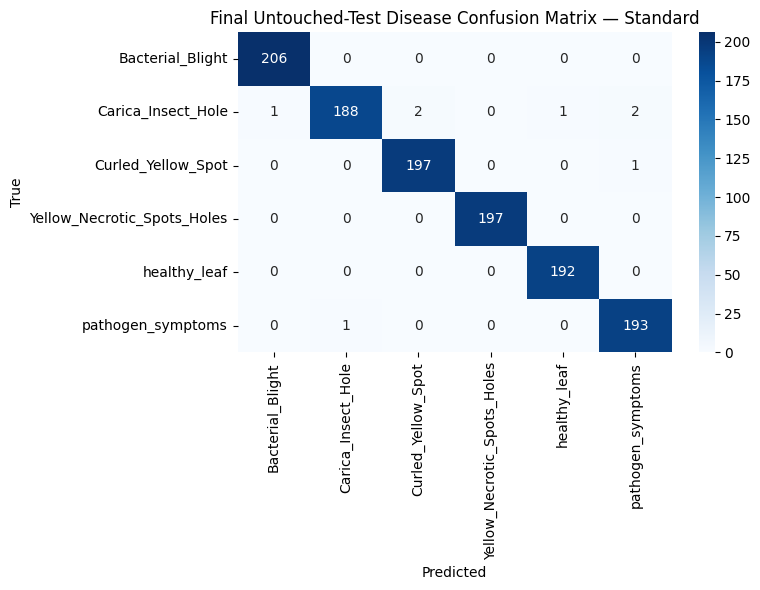

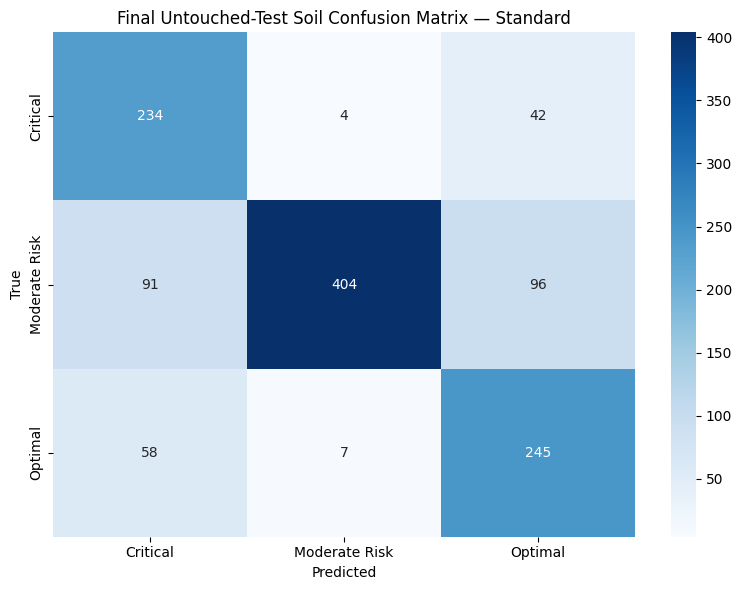



DISEASE CLASSIFICATION REPORT — HORIZONTAL-FLIP TTA
                             precision    recall  f1-score   support

           Bacterial_Blight       1.00      1.00      1.00       206
         Carica_Insect_Hole       0.99      0.97      0.98       194
         Curled_Yellow_Spot       0.99      0.99      0.99       198
Yellow_Necrotic_Spots_Holes       1.00      1.00      1.00       197
               healthy_leaf       0.99      1.00      0.99       192
          pathogen_symptoms       0.99      0.99      0.99       194

                   accuracy                           0.99      1181
                  macro avg       0.99      0.99      0.99      1181
               weighted avg       0.99      0.99      0.99      1181



SOIL CLASSIFICATION REPORT — HORIZONTAL-FLIP TTA
               precision    recall  f1-score   support

     Critical       0.61      0.82      0.70       280
Moderate Risk       0.97      0.68      0.80       591
      Optimal       0.63      0.78  

In [10]:
# ============================================================
# FINAL UNTOUCHED-TEST EVALUATION
# ============================================================
#
# Protocol:
#   1. Use the COMPLETE trainval_df for final fitting.
#   2. Determine epochs ONLY from the 3 CV folds.
#   3. Use the MEDIAN number of epochs across the 3 folds.
#   4. Do NOT use the test set for checkpoint selection.
#   5. Do NOT use the test set for hyperparameter tuning.
#   6. Evaluate test set ONCE after final training.
#   7. Report standard inference separately.
#   8. Report optional horizontal-flip TTA separately.
#
# ============================================================

import os
import gc
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

print("\n" + "=" * 80)
print("FINAL UNTOUCHED-TEST EVALUATION")
print("=" * 80)


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

if "trainval_df" not in globals():
    raise RuntimeError(
        "trainval_df is not available."
    )

if "test_df" not in globals():
    raise RuntimeError(
        "test_df is not available."
    )

if "full_cv" not in globals():
    raise RuntimeError(
        "full_cv is not available. "
        "Run the 3-fold Full SIKA-Net CV first."
    )

if "SIKANet" not in globals():
    raise RuntimeError(
        "SIKANet class is not available."
    )

if "ImageMultiTaskDataset" not in globals():
    raise RuntimeError(
        "ImageMultiTaskDataset is not available."
    )

if "MultiTaskLoss" not in globals():
    raise RuntimeError(
        "MultiTaskLoss is not available."
    )


print(
    f"Train/validation pool: {len(trainval_df)} samples"
)

print(
    f"Untouched test set    : {len(test_df)} samples"
)


# ============================================================
# 2. DETERMINE FINAL NUMBER OF EPOCHS
# ============================================================
#
# IMPORTANT:
# The test set is NOT involved here.
#
# The number of epochs comes exclusively from the
# three Full-model CV folds.
#
# ============================================================

cv_epochs = np.asarray(
    full_cv["epochs"],
    dtype=float
)

if len(cv_epochs) != N_FOLDS:
    raise RuntimeError(
        f"Expected {N_FOLDS} CV epoch values, "
        f"but found {len(cv_epochs)}."
    )

epochs_final = int(
    np.clip(
        np.median(cv_epochs),
        1,
        EPOCHS
    )
)

print("\nCV epochs:")
print(cv_epochs.astype(int))

print(
    f"\nMedian CV epochs : {np.median(cv_epochs):.1f}"
)

print(
    f"Final epochs      : {epochs_final}"
)


# ============================================================
# 3. RESET RANDOM SEEDS
# ============================================================
#
# Use a fixed seed for the final refit.
# This does NOT use the test set.
#
# ============================================================

seed_everything(SEED)


# ============================================================
# 4. CREATE COMPLETE TRAINING DATASET
# ============================================================
#
# The final model is trained using ALL trainval_df samples.
#
# The test set is NOT included.
#
# ============================================================

final_train_df = (
    trainval_df
    .reset_index(drop=True)
    .copy()
)

final_train_dataset = ImageMultiTaskDataset(
    final_train_df,
    image_size=IMAGE_SIZE,
    training=True
)


# ============================================================
# 5. CLASS WEIGHTS FROM COMPLETE TRAIN/VALIDATION POOL
# ============================================================
#
# These weights are calculated ONLY from trainval_df.
#
# ============================================================

final_disease_weights = make_class_weights(
    final_train_df["disease_idx"].values,
    NUM_DISEASE_CLASSES
)

final_soil_weights = make_class_weights(
    final_train_df["soil_idx"].values,
    NUM_SOIL_CLASSES
)


# ============================================================
# 6. WEIGHTED SAMPLER
# ============================================================

sample_weights = (
    final_disease_weights[
        final_train_df["disease_idx"].values
    ]
    *
    final_soil_weights[
        final_train_df["soil_idx"].values
    ]
)

sample_weights = sample_weights.double()


final_sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


# ============================================================
# 7. FINAL TRAINING DATALOADER
# ============================================================

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=final_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)


print(
    "\nFinal training batches:",
    len(final_train_loader)
)


# ============================================================
# 8. CREATE FINAL SIKA-NET
# ============================================================

final_model = SIKANet(
    variant="Full",
    num_disease_classes=NUM_DISEASE_CLASSES,
    num_soil_classes=NUM_SOIL_CLASSES,
    dropout=DROPOUT
).to(DEVICE)


print("\nFinal model:")
print(
    f"  Variant              : Full"
)

print(
    f"  Disease classes      : {NUM_DISEASE_CLASSES}"
)

print(
    f"  Soil classes         : {NUM_SOIL_CLASSES}"
)

print(
    f"  Training samples     : {len(final_train_dataset)}"
)

print(
    f"  Epochs               : {epochs_final}"
)


# ============================================================
# 9. FINAL LOSS
# ============================================================

final_criterion = MultiTaskLoss(
    final_disease_weights.to(DEVICE),
    final_soil_weights.to(DEVICE)
).to(DEVICE)


# ============================================================
# 10. FINAL OPTIMIZER
# ============================================================
#
# Same optimization configuration used during CV.
#
# ============================================================

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 11. FINAL SCHEDULER
# ============================================================
#
# The final refit uses the predetermined number of epochs.
# No validation set exists during this final fit, so we do NOT
# use ReduceLROnPlateau or test performance to control LR.
#
# ============================================================

final_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        final_optimizer,
        T_max=max(1, epochs_final),
        eta_min=LEARNING_RATE * 0.05
    )
)


# ============================================================
# 12. AMP
# ============================================================

if DEVICE.type == "cuda":

    final_scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    final_scaler = None


# ============================================================
# 13. FINAL TRAINING LOOP
# ============================================================
#
# IMPORTANT:
# There is NO test-set evaluation here.
#
# There is also NO checkpoint selection.
#
# The model simply trains for the predetermined median
# number of CV epochs.
#
# ============================================================

final_history = []


print("\n" + "-" * 80)
print("FINAL REFIT ON COMPLETE TRAIN/VALIDATION POOL")
print("-" * 80)


for epoch in range(
    1,
    epochs_final + 1
):

    epoch_start = time.time()

    final_model.train()

    running_loss = 0.0

    disease_true = []
    disease_pred = []

    soil_true = []
    soil_pred = []


    # --------------------------------------------------------
    # Training batches
    # --------------------------------------------------------

    for batch in final_train_loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        disease_target = batch[
            "disease"
        ].to(
            DEVICE,
            non_blocking=True
        )

        soil_target = batch[
            "soil"
        ].to(
            DEVICE,
            non_blocking=True
        )


        final_optimizer.zero_grad(
            set_to_none=True
        )


        use_amp = (
            DEVICE.type == "cuda"
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=use_amp
        ):

            outputs = final_model(
                images
            )

            loss, disease_loss, soil_loss = (
                final_criterion(
                    outputs,
                    disease_target,
                    soil_target
                )
            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        if final_scaler is not None:

            final_scaler.scale(
                loss
            ).backward()

            final_scaler.unscale_(
                final_optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                final_model.parameters(),
                GRAD_CLIP
            )

            final_scaler.step(
                final_optimizer
            )

            final_scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                final_model.parameters(),
                GRAD_CLIP
            )

            final_optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = images.size(0)

        running_loss += (
            loss.detach().item()
            * batch_size
        )


        disease_true.extend(
            disease_target
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        disease_pred.extend(
            outputs["disease"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


        soil_true.extend(
            soil_target
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        soil_pred.extend(
            outputs["soil"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


    # --------------------------------------------------------
    # Epoch metrics
    # --------------------------------------------------------

    train_loss = (
        running_loss
        /
        len(final_train_loader.dataset)
    )

    train_acc = accuracy_score(
        disease_true,
        disease_pred
    )

    train_f1 = f1_score(
        disease_true,
        disease_pred,
        average="macro",
        zero_division=0
    )

    train_mcc = matthews_corrcoef(
        disease_true,
        disease_pred
    )


    soil_acc = accuracy_score(
        soil_true,
        soil_pred
    )

    soil_f1 = f1_score(
        soil_true,
        soil_pred,
        average="macro",
        zero_division=0
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    final_scheduler.step()

    current_lr = (
        final_optimizer
        .param_groups[0]["lr"]
    )


    elapsed = (
        time.time()
        - epoch_start
    )


    final_history.append({

        "epoch": epoch,

        "train_loss": train_loss,

        "train_accuracy": train_acc,

        "train_macro_f1": train_f1,

        "train_mcc": train_mcc,

        "train_soil_accuracy": soil_acc,

        "train_soil_macro_f1": soil_f1,

        "lr": current_lr,

        "epoch_time_sec": elapsed
    })


    print(
        f"Epoch {epoch:02d}/{epochs_final} | "
        f"Loss {train_loss:.4f} | "
        f"Disease Acc {train_acc:.4f} | "
        f"Disease F1 {train_f1:.4f} | "
        f"MCC {train_mcc:.4f} | "
        f"Soil Acc {soil_acc:.4f} | "
        f"Soil F1 {soil_f1:.4f} | "
        f"LR {current_lr:.2e}"
    )


# ============================================================
# 14. SAVE FINAL TRAINING HISTORY
# ============================================================

final_history_df = pd.DataFrame(
    final_history
)

final_history_path = (
    OUT /
    "final_refit_training_history.csv"
)

final_history_df.to_csv(
    final_history_path,
    index=False
)


# ============================================================
# 15. CREATE UNTOUCHED TEST DATASET
# ============================================================
#
# NO augmentation.
#
# The test labels are used ONLY NOW for final evaluation.
#
# ============================================================

# Add disease_idx and soil_idx to test_df
test_df = test_df.copy()
test_df["disease_idx"] = (
    test_df[
        DISEASE_COLUMN
    ]
    .astype(str)
    .map(disease_to_idx)
)
test_df["soil_idx"] = (
    test_df[
        SOIL_COLUMN
    ]
    .astype(str)
    .map(soil_to_idx)
)

test_dataset = ImageMultiTaskDataset(
    test_df.reset_index(drop=True),
    image_size=IMAGE_SIZE,
    training=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)


print(
    "\nUntouched test batches:",
    len(test_loader)
)


# ============================================================
# 16. TEST INFERENCE FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_test(
    model,
    dataloader,
    tta=False
):

    model.eval()

    disease_true = []
    disease_pred = []

    soil_true = []
    soil_pred = []

    disease_probs = []
    soil_probs = []


    for batch in dataloader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        disease_target = batch[
            "disease"
        ]

        soil_target = batch[
            "soil"
        ]


        # ----------------------------------------------------
        # Standard forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )

        disease_probability = (
            torch.softmax(
                outputs["disease"],
                dim=1
            )
        )

        soil_probability = (
            torch.softmax(
                outputs["soil"],
                dim=1
            )
        )


        # ----------------------------------------------------
        # Optional horizontal-flip TTA
        # ----------------------------------------------------

        if tta:

            flipped_images = torch.flip(
                images,
                dims=[3]
            )

            flipped_outputs = model(
                flipped_images
            )

            disease_probability_flip = (
                torch.softmax(
                    flipped_outputs["disease"],
                    dim=1
                )
            )

            soil_probability_flip = (
                torch.softmax(
                    flipped_outputs["soil"],
                    dim=1
                )
            )


            # Average original + horizontal flip
            disease_probability = (
                0.5
                *
                (
                    disease_probability
                    +
                    disease_probability_flip
                )
            )

            soil_probability = (
                0.5
                *
                (
                    soil_probability
                    +
                    soil_probability_flip
                )
            )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        disease_prediction = (
            disease_probability
            .argmax(dim=1)
            .cpu()
            .numpy()
            .tolist()
        )

        soil_prediction = (
            soil_probability
            .argmax(dim=1)
            .cpu()
            .numpy()
            .tolist()
        )


        disease_true.extend(
            disease_target
            .numpy()
            .tolist()
        )

        disease_pred.extend(
            disease_prediction
        )


        soil_true.extend(
            soil_target
            .numpy()
            .tolist()
        )

        soil_pred.extend(
            soil_prediction
        )


        disease_probs.append(
            disease_probability
            .cpu()
            .numpy()
        )

        soil_probs.append(
            soil_probability
            .cpu()
            .numpy()
        )


    disease_probs = np.concatenate(
        disease_probs,
        axis=0
    )

    soil_probs = np.concatenate(
        soil_probs,
        axis=0
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    disease_accuracy = accuracy_score(
        disease_true,
        disease_pred
    )

    disease_macro_f1 = f1_score(
        disease_true,
        disease_pred,
        average="macro",
        zero_division=0
    )

    disease_mcc = matthews_corrcoef(
        disease_true,
        disease_pred
    )


    soil_accuracy = accuracy_score(
        soil_true,
        soil_pred
    )

    soil_macro_f1 = f1_score(
        soil_true,
        soil_pred,
        average="macro",
        zero_division=0
    )

    soil_mcc = matthews_corrcoef(
        soil_true,
        soil_pred
    )


    disease_cm = confusion_matrix(
        disease_true,
        disease_pred,
        labels=np.arange(
            NUM_DISEASE_CLASSES
        )
    )

    soil_cm = confusion_matrix(
        soil_true,
        soil_pred,
        labels=np.arange(
            NUM_SOIL_CLASSES
        )
    )


    return {

        "disease_accuracy":
            disease_accuracy,

        "disease_macro_f1":
            disease_macro_f1,

        "disease_mcc":
            disease_mcc,

        "disease_true":
            np.asarray(disease_true),

        "disease_pred":
            np.asarray(disease_pred),

        "disease_probs":
            disease_probs,

        "disease_cm":
            disease_cm,

        "soil_accuracy":
            soil_accuracy,

        "soil_macro_f1":
            soil_macro_f1,

        "soil_mcc":
            soil_mcc,

        "soil_true":
            np.asarray(soil_true),

        "soil_pred":
            np.asarray(soil_pred),

        "soil_probs":
            soil_probs,

        "soil_cm":
            soil_cm,

        "tta":
            tta
    }


# ============================================================
# 17. STANDARD TEST INFERENCE
# ============================================================

print("\n" + "=" * 80)
print("STANDARD INFERENCE — UNTOUCHED TEST SET")
print("=" * 80)

standard_test = evaluate_test(
    final_model,
    test_loader,
    tta=False
)


# ============================================================
# 18. OPTIONAL HORIZONTAL-FLIP TTA
# ============================================================

USE_TTA = True

if USE_TTA:

    print("\n" + "=" * 80)
    print("HORIZONTAL-FLIP TTA — UNTOUCHED TEST SET")
    print("=" * 80)

    tta_test = evaluate_test(
        final_model,
        test_loader,
        tta=True
    )

else:

    tta_test = None


# ============================================================
# 19. PRINT STANDARD RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL TEST RESULTS — STANDARD")
print("=" * 80)

print(
    f"Disease Accuracy : "
    f"{standard_test['disease_accuracy']:.4f}"
)

print(
    f"Disease Macro F1 : "
    f"{standard_test['disease_macro_f1']:.4f}"
)

print(
    f"Disease MCC      : "
    f"{standard_test['disease_mcc']:.4f}"
)

print(
    f"Soil Accuracy    : "
    f"{standard_test['soil_accuracy']:.4f}"
)

print(
    f"Soil Macro F1    : "
    f"{standard_test['soil_macro_f1']:.4f}"
)

print(
    f"Soil MCC         : "
    f"{standard_test['soil_mcc']:.4f}"
)


# ============================================================
# 20. PRINT TTA RESULTS
# ============================================================

if tta_test is not None:

    print("\n")
    print("=" * 80)
    print("FINAL TEST RESULTS — HORIZONTAL-FLIP TTA")
    print("=" * 80)

    print(
        f"Disease Accuracy : "
        f"{tta_test['disease_accuracy']:.4f}"
    )

    print(
        f"Disease Macro F1 : "
        f"{tta_test['disease_macro_f1']:.4f}"
    )

    print(
        f"Disease MCC      : "
        f"{tta_test['disease_mcc']:.4f}"
    )

    print(
        f"Soil Accuracy    : "
        f"{tta_test['soil_accuracy']:.4f}"
    )

    print(
        f"Soil Macro F1    : "
        f"{tta_test['soil_macro_f1']:.4f}"
    )

    print(
        f"Soil MCC         : "
        f"{tta_test['soil_mcc']:.4f}"
    )


# ============================================================
# 21. STANDARD DISEASE CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print("DISEASE CLASSIFICATION REPORT — STANDARD")
print("=" * 80)

print(
    classification_report(
        standard_test["disease_true"],
        standard_test["disease_pred"],
        labels=np.arange(
            NUM_DISEASE_CLASSES
        ),
        target_names=[
            idx_to_disease[i]
            for i in range(
                NUM_DISEASE_CLASSES
            )
        ],
        zero_division=0
    )
)


# ============================================================
# 22. STANDARD SOIL CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print("SOIL CLASSIFICATION REPORT — STANDARD")
print("=" * 80)

print(
    classification_report(
        standard_test["soil_true"],
        standard_test["soil_pred"],
        labels=np.arange(
            NUM_SOIL_CLASSES
        ),
        target_names=[
            idx_to_soil[i]
            for i in range(
                NUM_SOIL_CLASSES
            )
        ],
        zero_division=0
    )
)


# ============================================================
# 23. CONFUSION MATRIX DISPLAY
# ============================================================

def plot_confusion_matrix(
    cm,
    class_names,
    title,
    filename
):

    plt.figure(
        figsize=(8, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.title(
        title
    )

    plt.tight_layout()

    plt.savefig(
        OUT / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# Disease CM
plot_confusion_matrix(
    standard_test["disease_cm"],
    [
        idx_to_disease[i]
        for i in range(
            NUM_DISEASE_CLASSES
        )
    ],
    "Final Untouched-Test Disease Confusion Matrix — Standard",
    "final_test_disease_confusion_matrix_standard.png"
)


# Soil CM
plot_confusion_matrix(
    standard_test["soil_cm"],
    [
        idx_to_soil[i]
        for i in range(
            NUM_SOIL_CLASSES
        )
    ],
    "Final Untouched-Test Soil Confusion Matrix — Standard",
    "final_test_soil_confusion_matrix_standard.png"
)


# ============================================================
# 24. TTA CLASSIFICATION REPORTS
# ============================================================

if tta_test is not None:

    print("\n")
    print("=" * 80)
    print("DISEASE CLASSIFICATION REPORT — HORIZONTAL-FLIP TTA")
    print("=" * 80)

    print(
        classification_report(
            tta_test["disease_true"],
            tta_test["disease_pred"],
            labels=np.arange(
                NUM_DISEASE_CLASSES
            ),
            target_names=[
                idx_to_disease[i]
                for i in range(
                    NUM_DISEASE_CLASSES
                )
            ],
            zero_division=0
        )
    )


    print("\n")
    print("=" * 80)
    print("SOIL CLASSIFICATION REPORT — HORIZONTAL-FLIP TTA")
    print("=" * 80)

    print(
        classification_report(
            tta_test["soil_true"],
            tta_test["soil_pred"],
            labels=np.arange(
                NUM_SOIL_CLASSES
            ),
            target_names=[
                idx_to_soil[i]
                for i in range(
                    NUM_SOIL_CLASSES
                )
            ],
            zero_division=0
        )
    )


# ============================================================
# 25. SAVE FINAL TEST METRICS
# ============================================================

result_rows = [

    {
        "inference":
            "Standard",

        "disease_accuracy":
            standard_test["disease_accuracy"],

        "disease_macro_f1":
            standard_test["disease_macro_f1"],

        "disease_mcc":
            standard_test["disease_mcc"],

        "soil_accuracy":
            standard_test["soil_accuracy"],

        "soil_macro_f1":
            standard_test["soil_macro_f1"],

        "soil_mcc":
            standard_test["soil_mcc"],

        "epochs_final":
            epochs_final,

        "trainval_samples":
            len(trainval_df),

        "test_samples":
            len(test_df)
    }
]


if tta_test is not None:

    result_rows.append({

        "inference":
            "HorizontalFlip_TTA",

        "disease_accuracy":
            tta_test["disease_accuracy"],

        "disease_macro_f1":
            tta_test["disease_macro_f1"],

        "disease_mcc":
            tta_test["disease_mcc"],

        "soil_accuracy":
            tta_test["soil_accuracy"],

        "soil_macro_f1":
            tta_test["soil_macro_f1"],

        "soil_mcc":
            tta_test["soil_mcc"],

        "epochs_final":
            epochs_final,

        "trainval_samples":
            len(trainval_df),

        "test_samples":
            len(test_df)
    })


final_test_results = pd.DataFrame(
    result_rows
)


final_test_results.to_csv(
    OUT /
    "final_untouched_test_results.csv",
    index=False
)


# ============================================================
# 26. SAVE FINAL MODEL
# ============================================================

final_model_path = (
    OUT /
    "SIKA_Net_Final_Untouched_Test.pth"
)


torch.save(
    {
        "model_state_dict":
            final_model.state_dict(),

        "variant":
            "Full",

        "epochs_final":
            epochs_final,

        "cv_epochs":
            cv_epochs.tolist(),

        "image_size":
            IMAGE_SIZE,

        "num_disease_classes":
            NUM_DISEASE_CLASSES,

        "num_soil_classes":
            NUM_SOIL_CLASSES,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "seed":
            SEED
    },
    final_model_path
)


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL UNTOUCHED-TEST EVALUATION COMPLETE")
print("=" * 80)

print(
    f"Train/validation samples : {len(trainval_df)}"
)

print(
    f"Untouched test samples   : {len(test_df)}"
)

print(
    f"3-fold CV epochs         : "
    f"{cv_epochs.astype(int).tolist()}"
)

print(
    f"Median final epochs      : {epochs_final}"
)

print(
    f"\nStandard Disease Acc    : "
    f"{standard_test['disease_accuracy']:.4f}"
)

print(
    f"Standard Disease Macro-F1: "
    f"{standard_test['disease_macro_f1']:.4f}"
)

print(
    f"Standard Disease MCC     : "
    f"{standard_test['disease_mcc']:.4f}"
)

print(
    f"\nStandard Soil Acc        : "
    f"{standard_test['soil_accuracy']:.4f}"
)

print(
    f"Standard Soil Macro-F1   : "
    f"{standard_test['soil_macro_f1']:.4f}"
)

print(
    f"Standard Soil MCC        : "
    f"{standard_test['soil_mcc']:.4f}"
)


if tta_test is not None:

    print(
        f"\nTTA Disease Acc          : "
        f"{tta_test['disease_accuracy']:.4f}"
    )

    print(
        f"TTA Disease Macro-F1    : "
        f"{tta_test['disease_macro_f1']:.4f}"
    )

    print(
        f"TTA Disease MCC         : "
        f"{tta_test['disease_mcc']:.4f}"
    )

    print(
        f"\nTTA Soil Acc             : "
        f"{tta_test['soil_accuracy']:.4f}"
    )

    print(
        f"TTA Soil Macro-F1       : "
        f"{tta_test['soil_macro_f1']:.4f}"
    )

    print(
        f"TTA Soil MCC            : "
        f"{tta_test['soil_mcc']:.4f}"
    )


print(
    "\nSaved:"
)

print(
    f" - {final_history_path}"
)

print(
    f" - {OUT / 'final_untouched_test_results.csv'}"
)

print(
    f" - {final_model_path}"
)

print(
    f" - {OUT / 'final_test_disease_confusion_matrix_standard.png'}"
)

print(
    f" - {OUT / 'final_test_soil_confusion_matrix_standard.png'}"
)

print("\n" + "=" * 80)


## Confusion Matrices

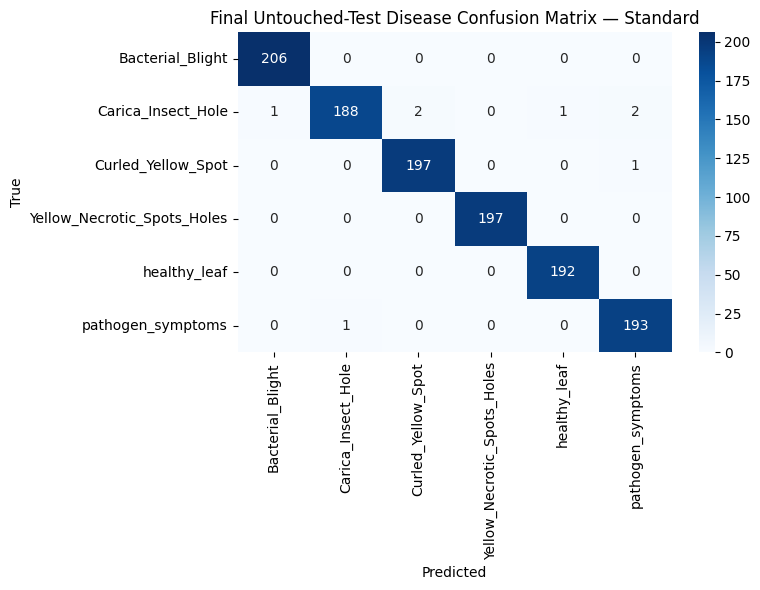

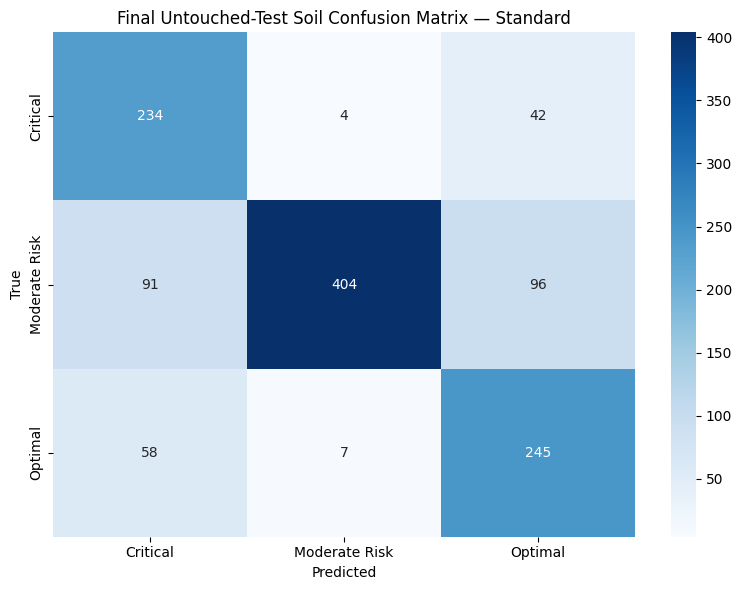

In [11]:
# Disease Confusion Matrix - Standard Inference
plot_confusion_matrix(
    standard_test["disease_cm"],
    [
        idx_to_disease[i]
        for i in range(
            NUM_DISEASE_CLASSES
        )
    ],
    "Final Untouched-Test Disease Confusion Matrix — Standard",
    "final_test_disease_confusion_matrix_standard.png"
)

# Soil Confusion Matrix - Standard Inference
plot_confusion_matrix(
    standard_test["soil_cm"],
    [
        idx_to_soil[i]
        for i in range(
            NUM_SOIL_CLASSES
        )
    ],
    "Final Untouched-Test Soil Confusion Matrix — Standard",
    "final_test_soil_confusion_matrix_standard.png"
)

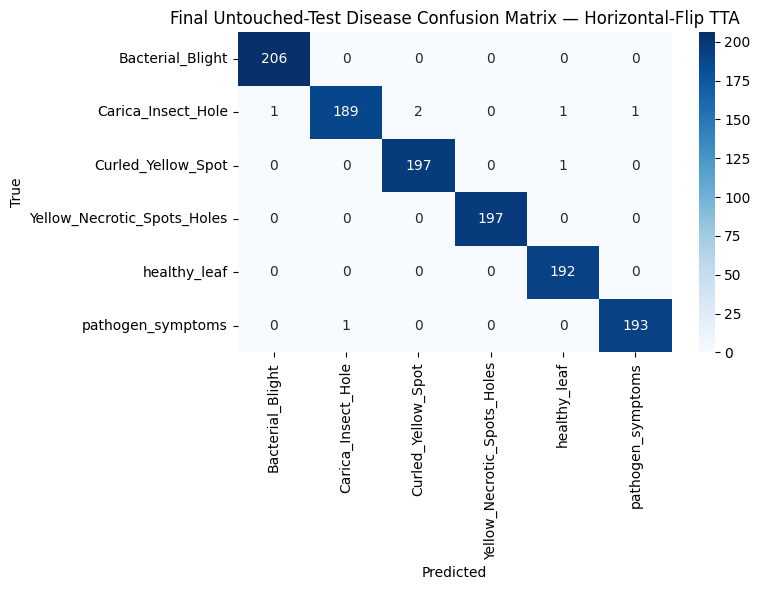

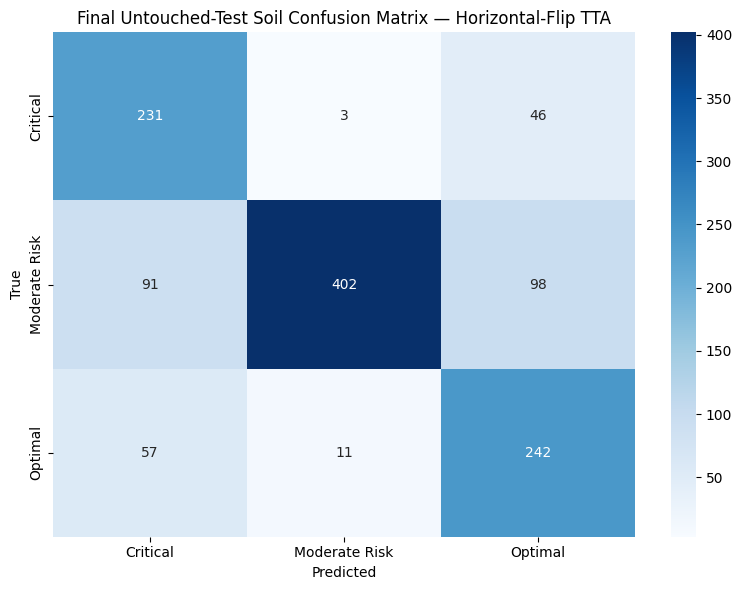

In [12]:
if 'tta_test' in globals() and tta_test is not None:
    # Disease Confusion Matrix - Horizontal-Flip TTA
    plot_confusion_matrix(
        tta_test["disease_cm"],
        [
            idx_to_disease[i]
            for i in range(
                NUM_DISEASE_CLASSES
            )
        ],
        "Final Untouched-Test Disease Confusion Matrix — Horizontal-Flip TTA",
        "final_test_disease_confusion_matrix_tta.png"
    )

    # Soil Confusion Matrix - Horizontal-Flip TTA
    plot_confusion_matrix(
        tta_test["soil_cm"],
        [
            idx_to_soil[i]
            for i in range(
                NUM_SOIL_CLASSES
            )
        ],
        "Final Untouched-Test Soil Confusion Matrix — Horizontal-Flip TTA",
        "final_test_soil_confusion_matrix_tta.png"
    )
else:
    print("Horizontal-Flip TTA results not available for confusion matrices.")

## Ablation Study Performance Comparison

Ablation Summary DataFrame loaded successfully.


,variant,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mcc_mean,mcc_std,soil_f1_mean,soil_f1_std,loss_mean,loss_std,epochs_mean,time_mean_sec
0,Full,0.986512,0.003195,0.986521,0.003212,0.983833,0.003821,0.742436,0.002650,0.556270,0.012700,58.2,1814.292399
1,No_Attention,0.944393,0.030989,0.944003,0.031264,0.933625,0.036979,0.736411,0.011129,0.711874,0.076965,56.8,1229.903198
2,No_ISO,0.984021,0.002026,0.984020,0.002020,0.980859,0.002437,0.744311,0.005293,0.590934,0.007869,57.4,1475.879883
3,No_SIKA,0.974684,0.010232,0.974568,0.010385,0.969764,0.012124,0.750234,0.014847,0.627701,0.032295,60.0,1275.671287


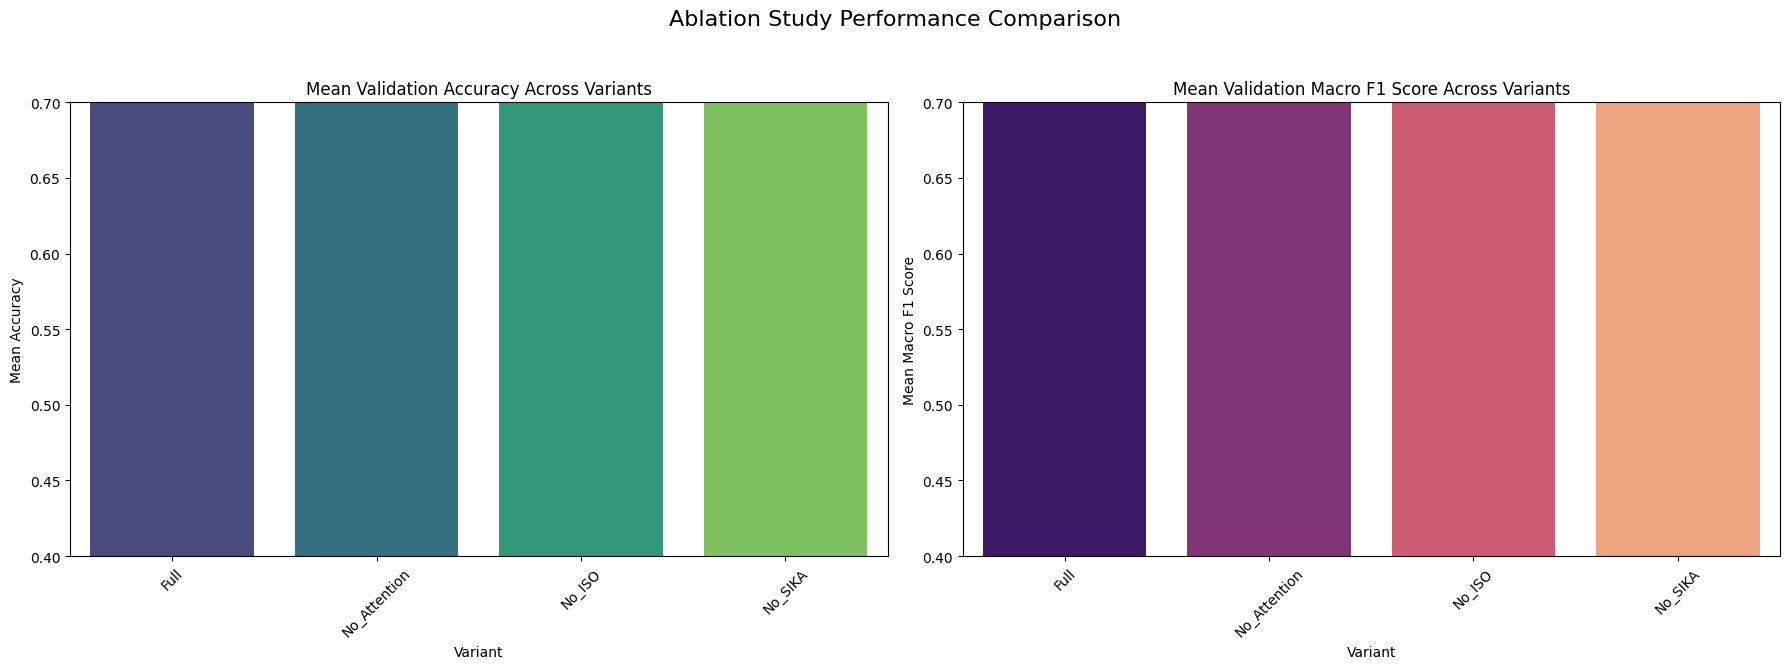


Plot saved to: sika_results/08_ablation_study_performance_comparison.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'ablation_summary' in globals() and not ablation_summary.empty:
    print("Ablation Summary DataFrame loaded successfully.")
    display(ablation_summary.head())

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Ablation Study Performance Comparison', fontsize=16)

    # Plot Accuracy
    sns.barplot(
        x='variant',
        y='accuracy_mean',
        data=ablation_summary,
        palette='viridis',
        ax=axes[0]
    )
    axes[0].set_title('Mean Validation Accuracy Across Variants')
    axes[0].set_xlabel('Variant')
    axes[0].set_ylabel('Mean Accuracy')
    axes[0].set_ylim(0.4, 0.7) # Adjust as needed
    axes[0].tick_params(axis='x', rotation=45)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.3f', padding=5)

    # Plot Macro F1 Score
    sns.barplot(
        x='variant',
        y='macro_f1_mean',
        data=ablation_summary,
        palette='magma',
        ax=axes[1]
    )
    axes[1].set_title('Mean Validation Macro F1 Score Across Variants')
    axes[1].set_xlabel('Variant')
    axes[1].set_ylabel('Mean Macro F1 Score')
    axes[1].set_ylim(0.4, 0.7) # Adjust as needed
    axes[1].tick_params(axis='x', rotation=45)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.3f', padding=5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save plot
    plot_path = OUT / "08_ablation_study_performance_comparison.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved to: {plot_path}")

else:
    print("WARNING: `ablation_summary` DataFrame not found or is empty. Cannot plot ablation study comparison.")
    print("Please ensure the 3-fold CV and ablation cells were run successfully.")

## Receiver Operating Characteristic (ROC) Curves

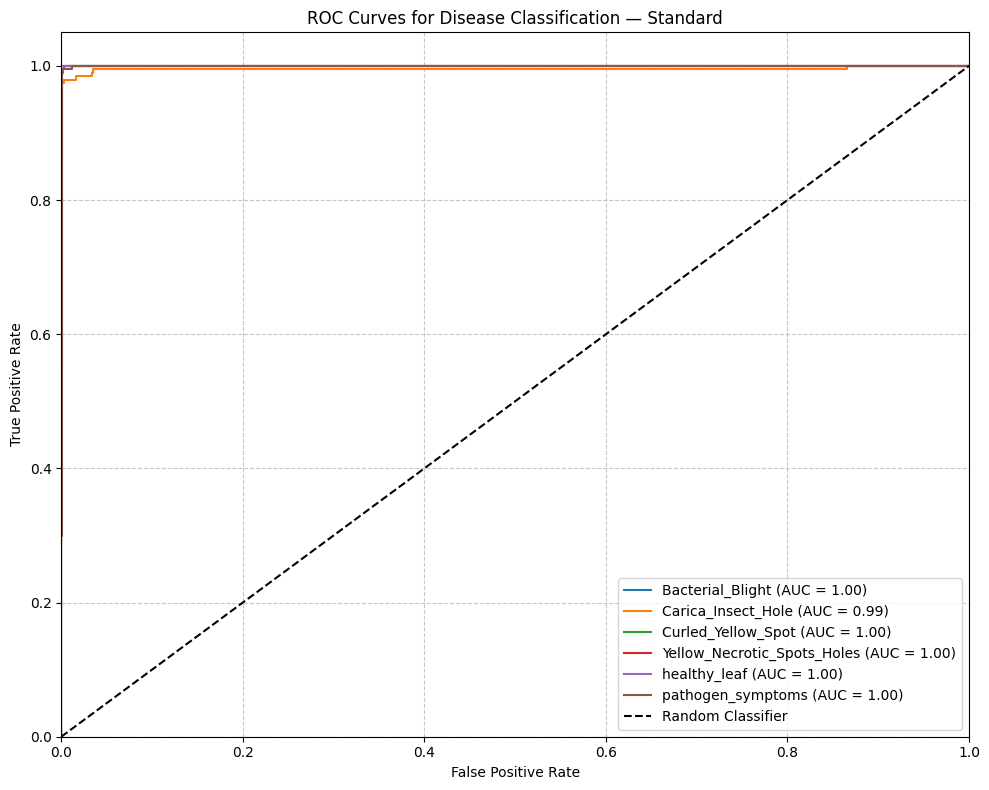

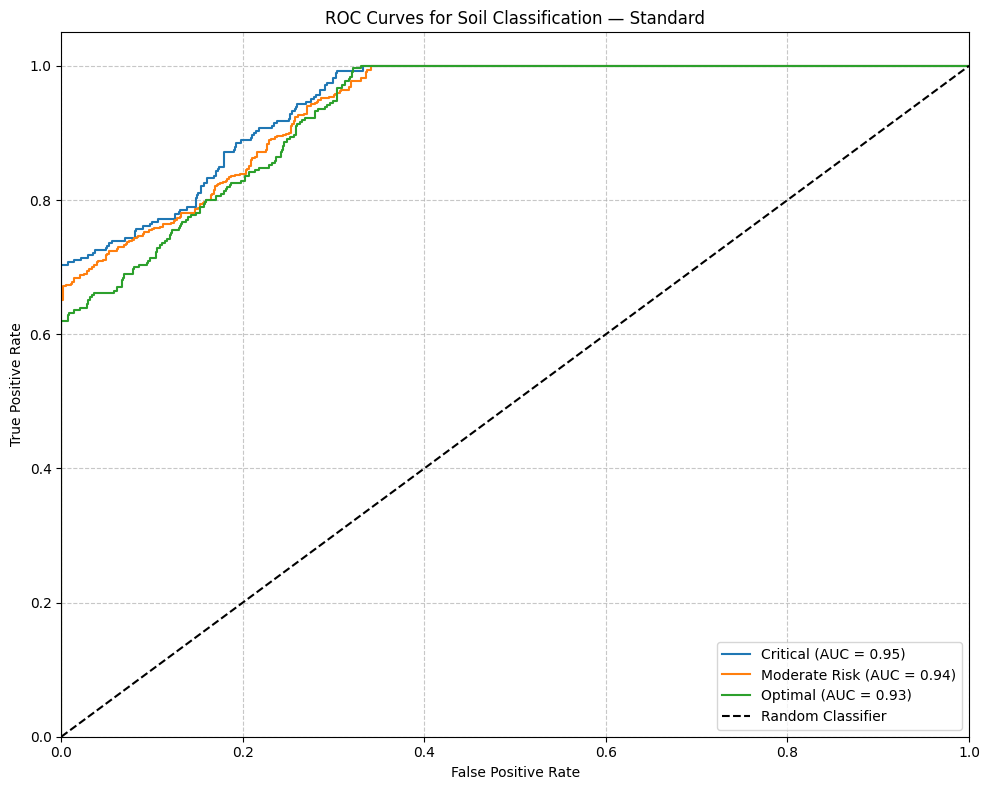

In [14]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_probs, class_names, title, filename):
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        # For multiclass, roc_curve expects binary labels, so we binarize for each class
        fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=300, bbox_inches='tight')
    plt.show()

# Disease ROC Curve - Standard Inference
plot_roc_curve(
    standard_test["disease_true"],
    standard_test["disease_probs"],
    [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
    "ROC Curves for Disease Classification — Standard",
    "roc_curve_disease_standard.png"
)

# Soil ROC Curve - Standard Inference
plot_roc_curve(
    standard_test["soil_true"],
    standard_test["soil_probs"],
    [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
    "ROC Curves for Soil Classification — Standard",
    "roc_curve_soil_standard.png"
)

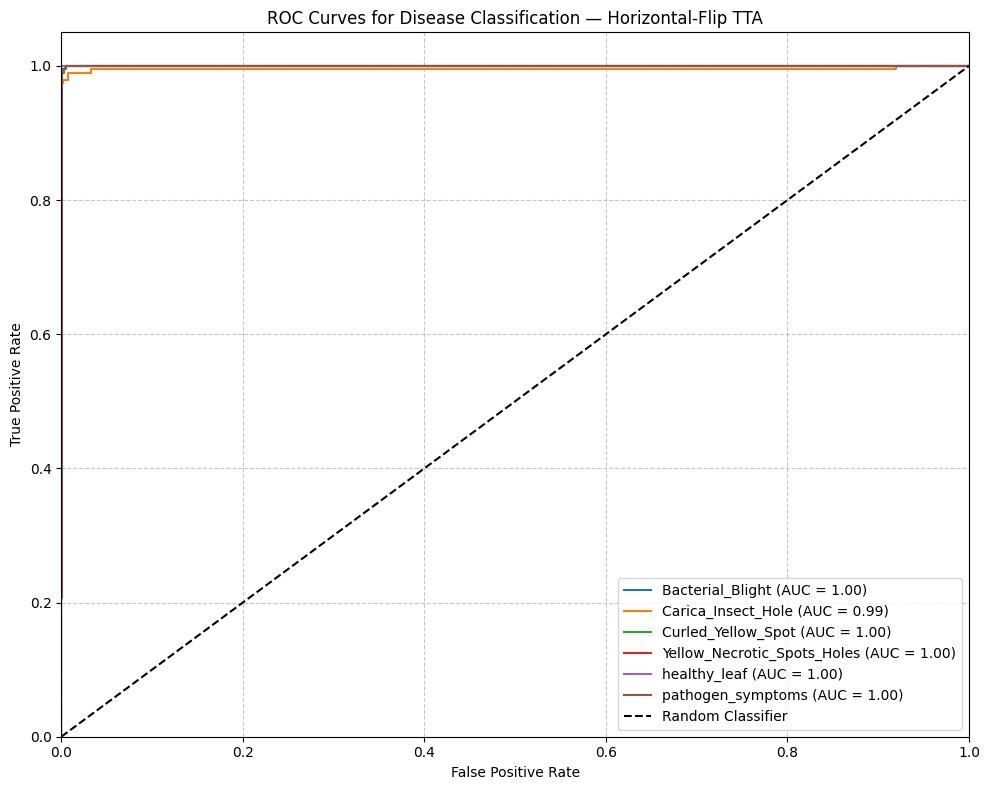

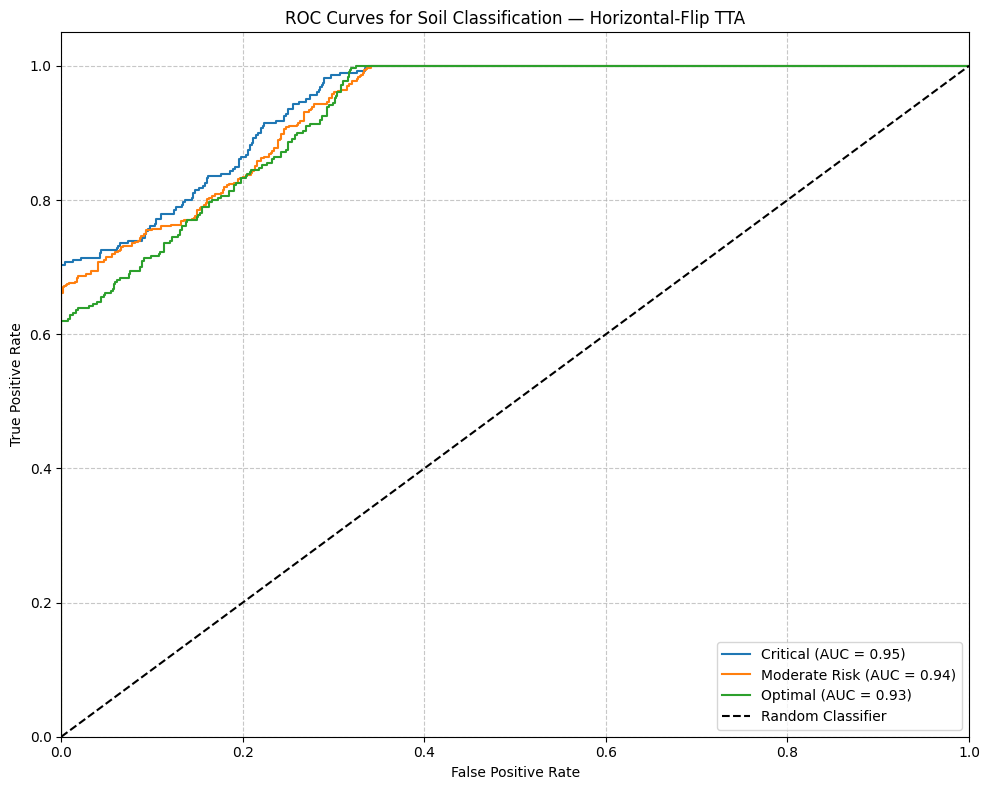

In [15]:
from sklearn.metrics import roc_curve, auc

if 'tta_test' in globals() and tta_test is not None:
    # Disease ROC Curve - Horizontal-Flip TTA
    plot_roc_curve(
        tta_test["disease_true"],
        tta_test["disease_probs"],
        [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
        "ROC Curves for Disease Classification — Horizontal-Flip TTA",
        "roc_curve_disease_tta.png"
    )

    # Soil ROC Curve - Horizontal-Flip TTA
    plot_roc_curve(
        tta_test["soil_true"],
        tta_test["soil_probs"],
        [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
        "ROC Curves for Soil Classification — Horizontal-Flip TTA",
        "roc_curve_soil_tta.png"
    )
else:
    print("Horizontal-Flip TTA results not available for ROC curves.")

## Precision-Recall (PR) Curves

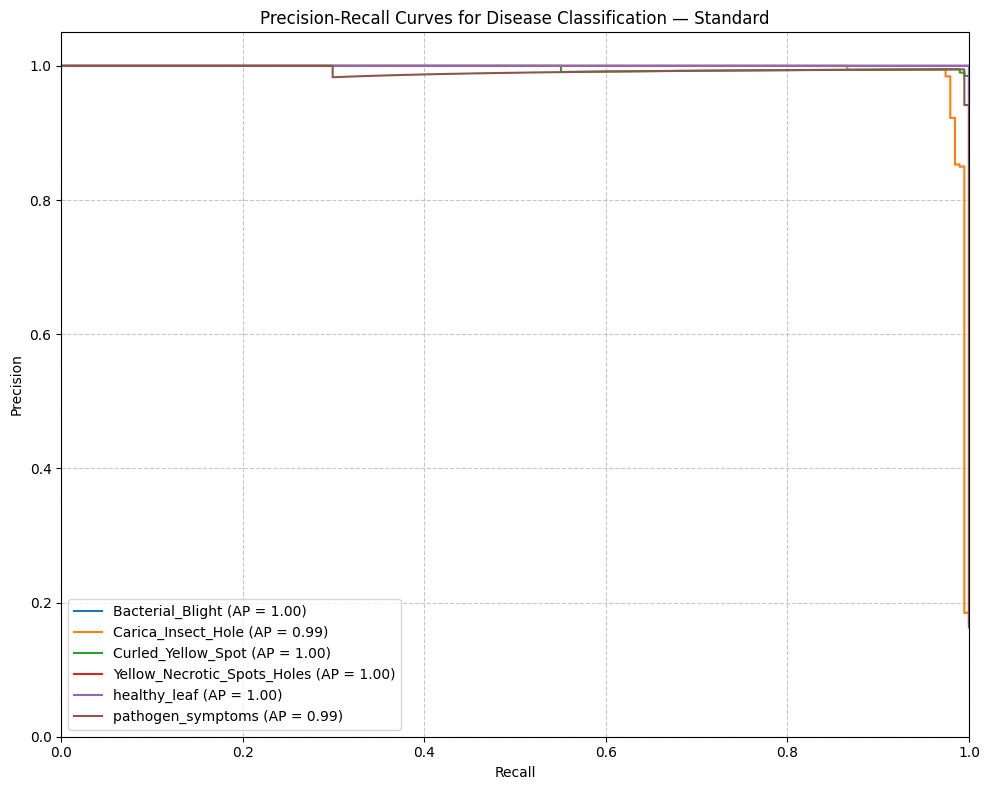

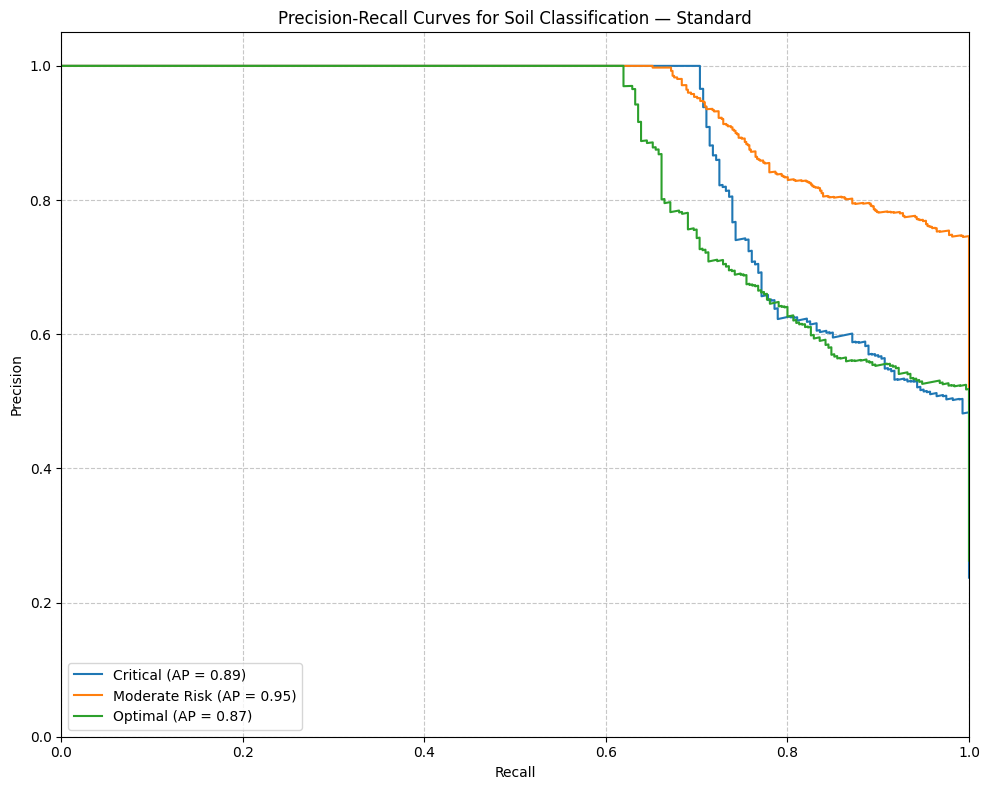

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(y_true, y_probs, class_names, title, filename):
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        # For multiclass, precision_recall_curve expects binary labels
        precision, recall, _ = precision_recall_curve(y_true == i, y_probs[:, i])
        avg_precision = average_precision_score(y_true == i, y_probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_precision:.2f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=300, bbox_inches='tight')
    plt.show()

# Disease PR Curve - Standard Inference
plot_pr_curve(
    standard_test["disease_true"],
    standard_test["disease_probs"],
    [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
    "Precision-Recall Curves for Disease Classification — Standard",
    "pr_curve_disease_standard.png"
)

# Soil PR Curve - Standard Inference
plot_pr_curve(
    standard_test["soil_true"],
    standard_test["soil_probs"],
    [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
    "Precision-Recall Curves for Soil Classification — Standard",
    "pr_curve_soil_standard.png"
)

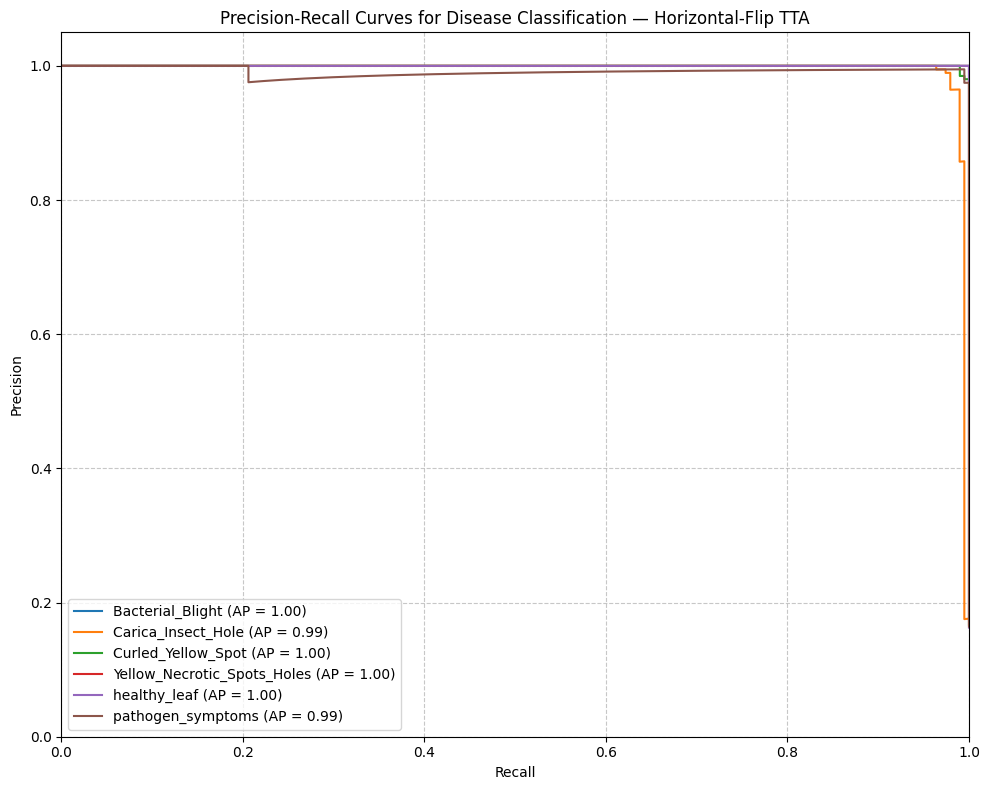

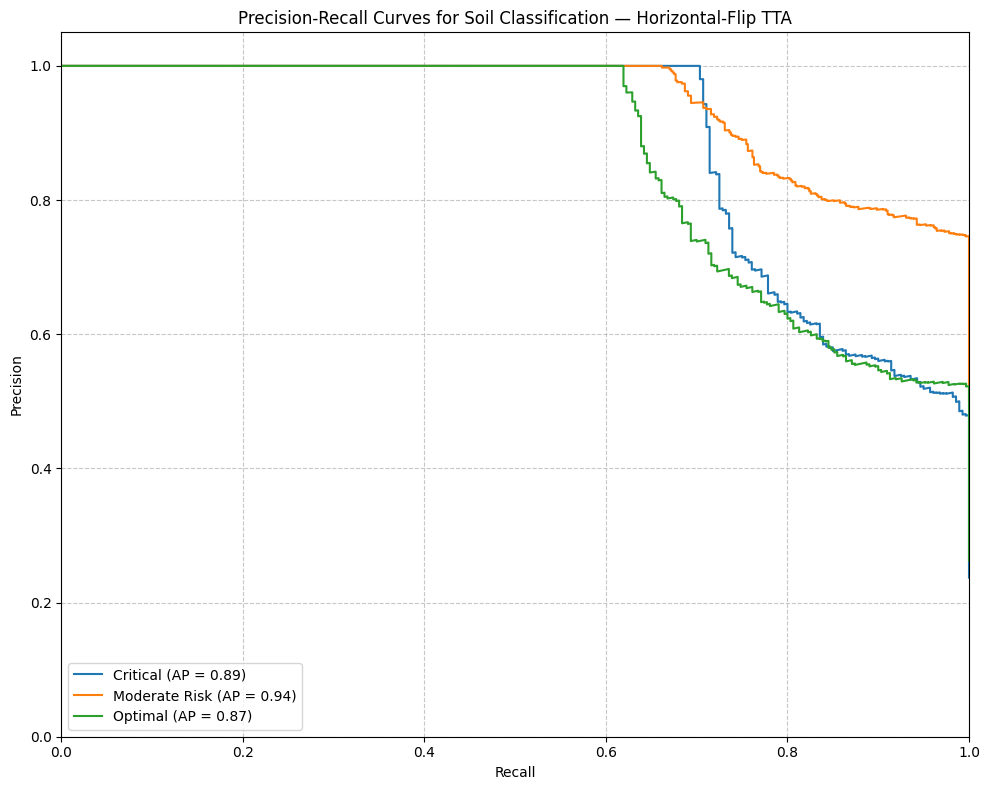

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

if 'tta_test' in globals() and tta_test is not None:
    # Disease PR Curve - Horizontal-Flip TTA
    plot_pr_curve(
        tta_test["disease_true"],
        tta_test["disease_probs"],
        [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
        "Precision-Recall Curves for Disease Classification — Horizontal-Flip TTA",
        "pr_curve_disease_tta.png"
    )

    # Soil PR Curve - Horizontal-Flip TTA
    plot_pr_curve(
        tta_test["soil_true"],
        tta_test["soil_probs"],
        [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
        "Precision-Recall Curves for Soil Classification — Horizontal-Flip TTA",
        "pr_curve_soil_tta.png"
    )
else:
    print("Horizontal-Flip TTA results not available for PR curves.")

## Receiver Operating Characteristic (ROC) Curves

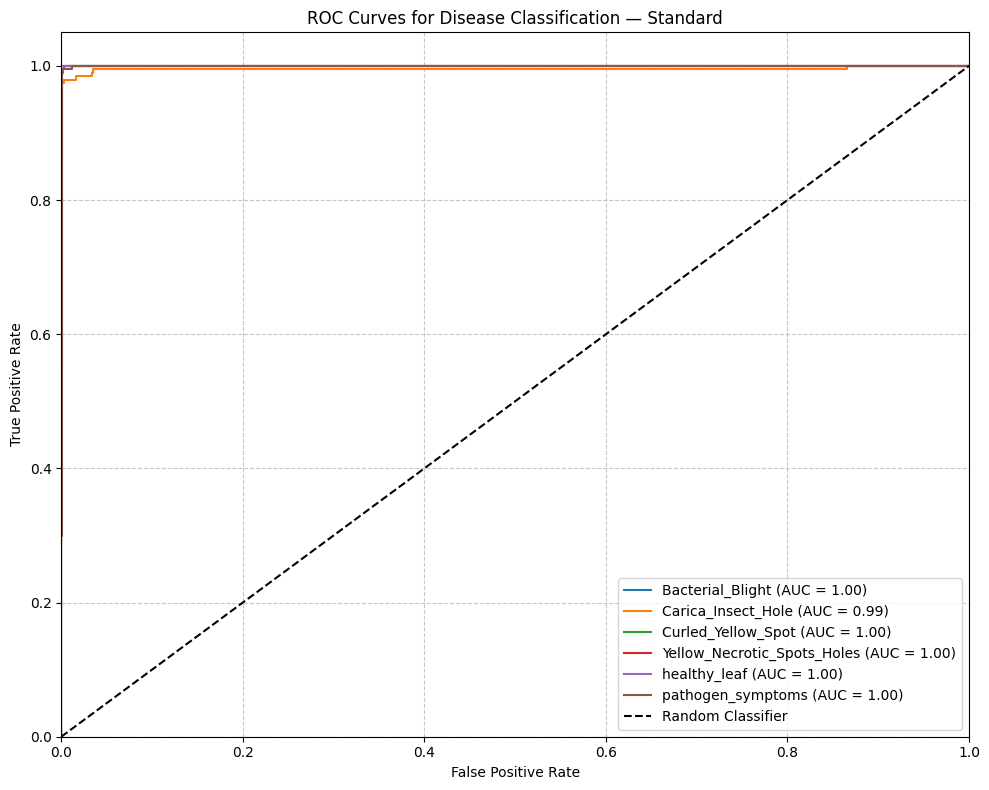

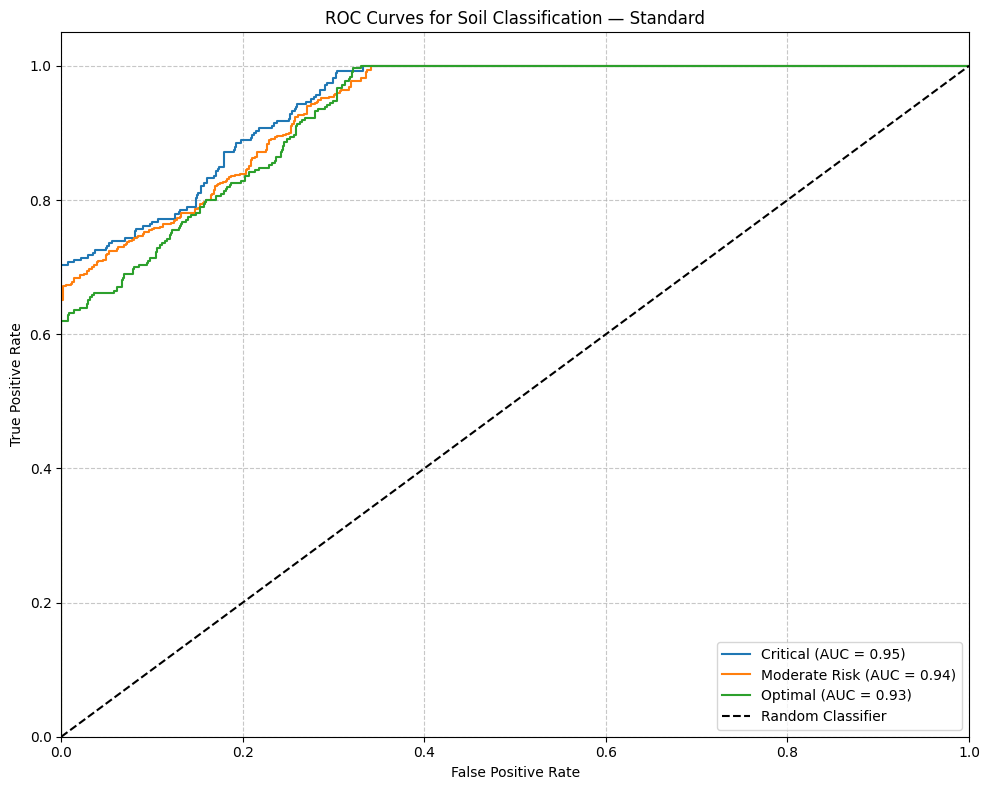

In [18]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_probs, class_names, title, filename):
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=300, bbox_inches='tight')
    plt.show()

# Disease ROC Curve - Standard Inference
plot_roc_curve(
    standard_test["disease_true"],
    standard_test["disease_probs"],
    [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
    "ROC Curves for Disease Classification — Standard",
    "roc_curve_disease_standard.png"
)

# Soil ROC Curve - Standard Inference
plot_roc_curve(
    standard_test["soil_true"],
    standard_test["soil_probs"],
    [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
    "ROC Curves for Soil Classification — Standard",
    "roc_curve_soil_standard.png"
)


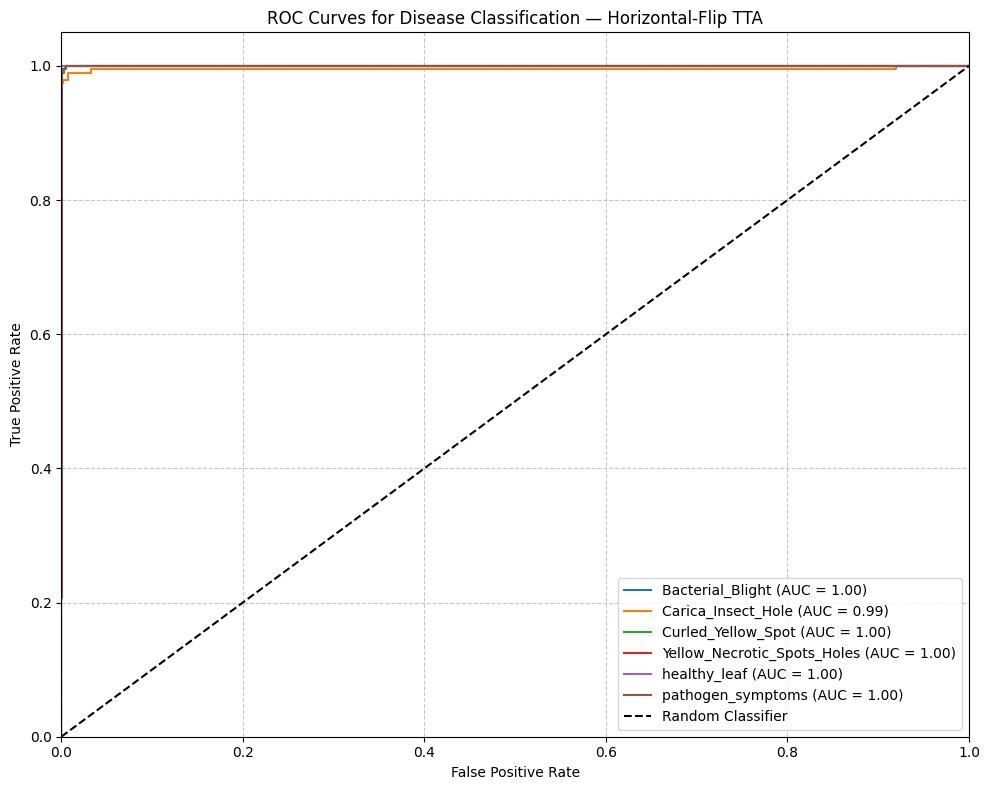

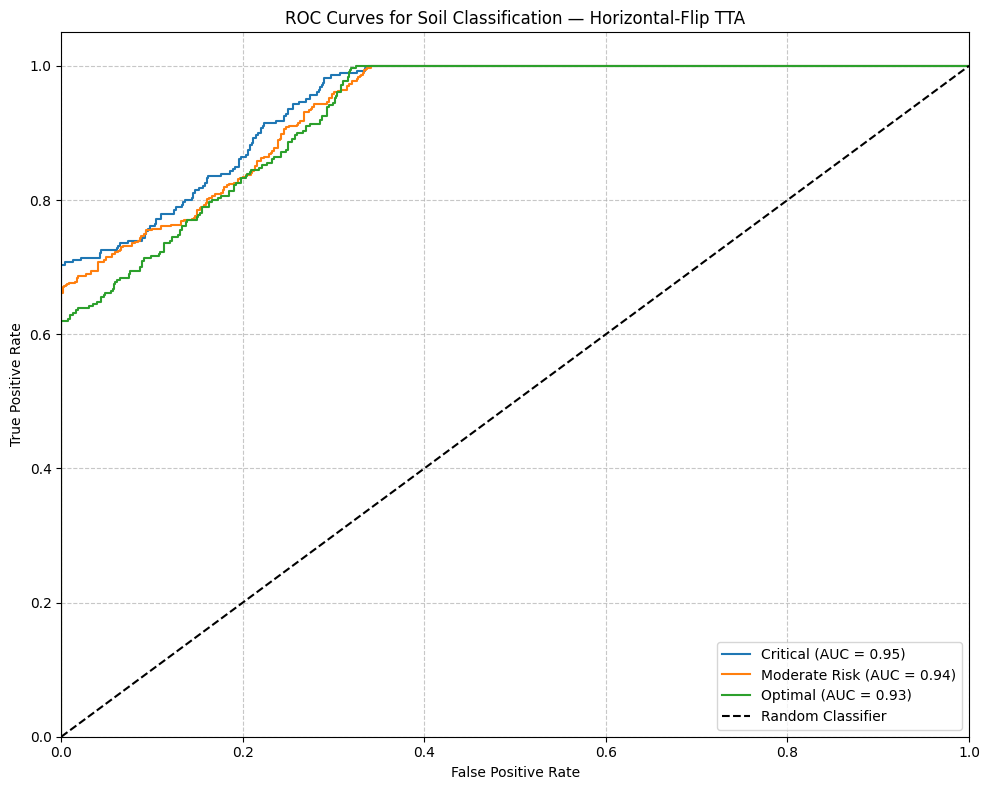

In [19]:
from sklearn.metrics import roc_curve, auc

if 'tta_test' in globals() and tta_test is not None:
    # Disease ROC Curve - Horizontal-Flip TTA
    plot_roc_curve(
        tta_test["disease_true"],
        tta_test["disease_probs"],
        [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
        "ROC Curves for Disease Classification — Horizontal-Flip TTA",
        "roc_curve_disease_tta.png"
    )

    # Soil ROC Curve - Horizontal-Flip TTA
    plot_roc_curve(
        tta_test["soil_true"],
        tta_test["soil_probs"],
        [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
        "ROC Curves for Soil Classification — Horizontal-Flip TTA",
        "roc_curve_soil_tta.png"
    )
else:
    print("Horizontal-Flip TTA results not available for ROC curves.")

## Precision-Recall (PR) Curves

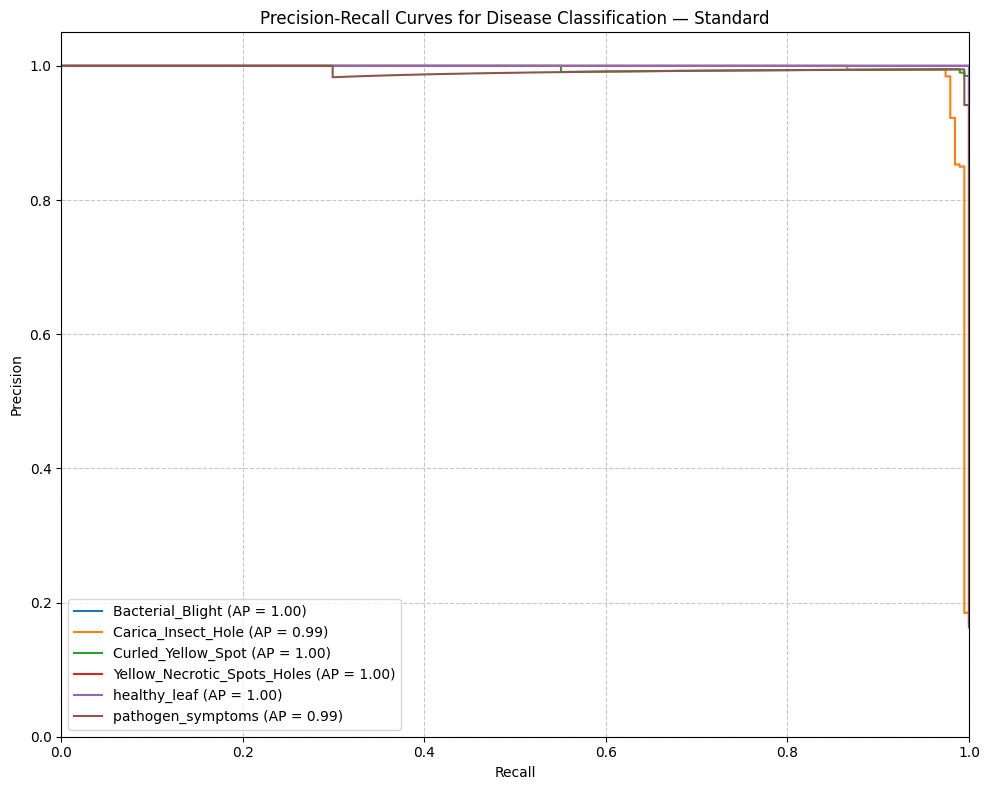

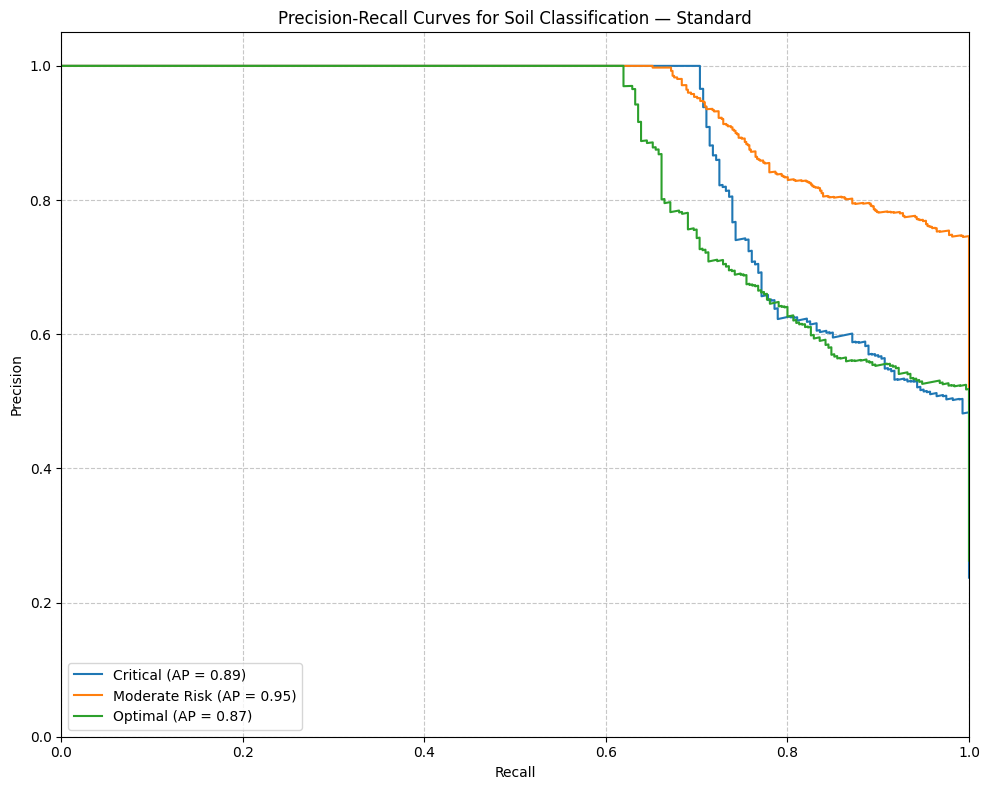

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(y_true, y_probs, class_names, title, filename):
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(y_true == i, y_probs[:, i])
        avg_precision = average_precision_score(y_true == i, y_probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_precision:.2f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=300, bbox_inches='tight')
    plt.show()

# Disease PR Curve - Standard Inference
plot_pr_curve(
    standard_test["disease_true"],
    standard_test["disease_probs"],
    [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
    "Precision-Recall Curves for Disease Classification — Standard",
    "pr_curve_disease_standard.png"
)

# Soil PR Curve - Standard Inference
plot_pr_curve(
    standard_test["soil_true"],
    standard_test["soil_probs"],
    [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
    "Precision-Recall Curves for Soil Classification — Standard",
    "pr_curve_soil_standard.png"
)

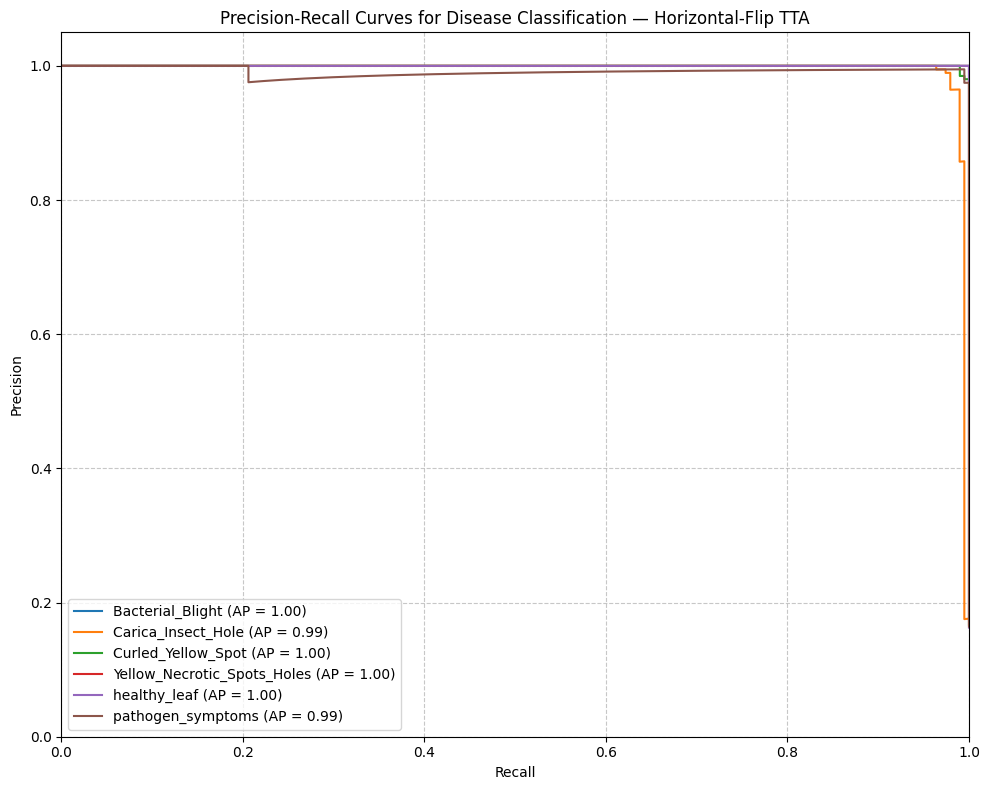

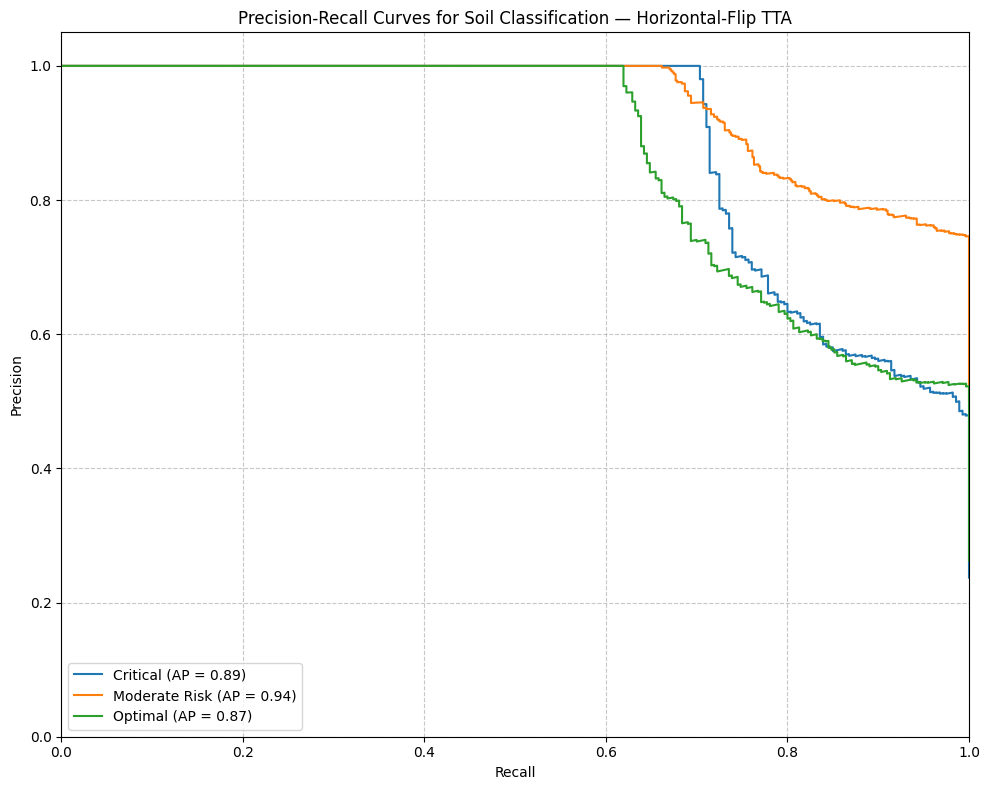

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

if 'tta_test' in globals() and tta_test is not None:
    # Disease PR Curve - Horizontal-Flip TTA
    plot_pr_curve(
        tta_test["disease_true"],
        tta_test["disease_probs"],
        [idx_to_disease[i] for i in range(NUM_DISEASE_CLASSES)],
        "Precision-Recall Curves for Disease Classification — Horizontal-Flip TTA",
        "pr_curve_disease_tta.png"
    )

    # Soil PR Curve - Horizontal-Flip TTA
    plot_pr_curve(
        tta_test["soil_true"],
        tta_test["soil_probs"],
        [idx_to_soil[i] for i in range(NUM_SOIL_CLASSES)],
        "Precision-Recall Curves for Soil Classification — Horizontal-Flip TTA",
        "pr_curve_soil_tta.png"
    )
else:
    print("Horizontal-Flip TTA results not available for PR curves.")

In [22]:
# ============================================================
# SAVE PUBLICATION PACKAGE
# ============================================================

import json
import copy
import torch
import pandas as pd
import numpy as np


print("\n" + "=" * 80)
print("SAVING PUBLICATION PACKAGE")
print("=" * 80)


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_objects = [
    "trainval_df",
    "test_df",
    "full_cv",
    "final_model",
    "standard_test",
    "final_test_results",
    "final_history_df",
    "epochs_final",
    "OUT"
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "The following required objects are missing:\n"
        + "\n".join(
            f"  - {x}"
            for x in missing
        )
    )


# ============================================================
# 2. OPTIONAL TTA CHECK
# ============================================================

has_tta = (
    "tta_test" in globals()
    and tta_test is not None
)


# ============================================================
# 3. CONVERT NUMPY/TORCH VALUES TO JSON-SAFE VALUES
# ============================================================

def json_safe(obj):

    if isinstance(
        obj,
        (
            np.integer,
            np.int8,
            np.int16,
            np.int32,
            np.int64
        )
    ):
        return int(obj)

    if isinstance(
        obj,
        (
            np.floating,
            np.float16,
            np.float32,
            np.float64
        )
    ):
        return float(obj)

    if isinstance(
        obj,
        np.ndarray
    ):
        return obj.tolist()

    if torch.is_tensor(obj):

        if obj.numel() == 1:
            return obj.detach().cpu().item()

        return obj.detach().cpu().tolist()

    if isinstance(
        obj,
        dict
    ):
        return {
            str(k): json_safe(v)
            for k, v in obj.items()
        }

    if isinstance(
        obj,
        (list, tuple)
    ):
        return [
            json_safe(v)
            for v in obj
        ]

    if pd.isna(obj):
        return None

    return obj


# ============================================================
# 4. CV RESULTS
# ============================================================

cv_records = json_safe(
    full_cv.to_dict(
        orient="records"
    )
)


# ============================================================
# 5. STANDARD TEST RESULTS
# ============================================================
#
# Do NOT save the full prediction arrays into metadata.
# They are saved separately below.
#
# ============================================================

standard_test_summary = {

    "inference":
        "standard",

    "disease_accuracy":
        float(
            standard_test[
                "disease_accuracy"
            ]
        ),

    "disease_macro_f1":
        float(
            standard_test[
                "disease_macro_f1"
            ]
        ),

    "disease_mcc":
        float(
            standard_test[
                "disease_mcc"
            ]
        ),

    "soil_accuracy":
        float(
            standard_test[
                "soil_accuracy"
            ]
        ),

    "soil_macro_f1":
        float(
            standard_test[
                "soil_macro_f1"
            ]
        ),

    "soil_mcc":
        float(
            standard_test[
                "soil_mcc"
            ]
        )
}


# ============================================================
# 6. TTA TEST RESULTS
# ============================================================

if has_tta:

    tta_test_summary = {

        "inference":
            "horizontal_flip_TTA",

        "disease_accuracy":
            float(
                tta_test[
                    "disease_accuracy"
                ]
            ),

        "disease_macro_f1":
            float(
                tta_test[
                    "disease_macro_f1"
                ]
            ),

        "disease_mcc":
            float(
                tta_test[
                    "disease_mcc"
                ]
            ),

        "soil_accuracy":
            float(
                tta_test[
                    "soil_accuracy"
                ]
            ),

        "soil_macro_f1":
            float(
                tta_test[
                    "soil_macro_f1"
                ]
            ),

        "soil_mcc":
            float(
                tta_test[
                    "soil_mcc"
                ]
            )
    }

else:

    tta_test_summary = None


# ============================================================
# 7. FINAL EXPERIMENT METADATA
# ============================================================

meta = {

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    "dataset": {

        "total_rows":
            int(
                len(
                    trainval_df
                )
                +
                len(
                    test_df
                )
            ),

        "trainval_n":
            int(
                len(
                    trainval_df
                )
            ),

        "test_n":
            int(
                len(
                    test_df
                )
            ),

        "image_size":
            int(
                IMAGE_SIZE
            )
    },


    # --------------------------------------------------------
    # Classes
    # --------------------------------------------------------

    "classes": {

        "disease_classes":
            [
                idx_to_disease[i]
                for i in range(
                    NUM_DISEASE_CLASSES
                )
            ],

        "soil_classes":
            [
                idx_to_soil[i]
                for i in range(
                    NUM_SOIL_CLASSES
                )
            ],

        "num_disease_classes":
            int(
                NUM_DISEASE_CLASSES
            ),

        "num_soil_classes":
            int(
                NUM_SOIL_CLASSES
            )
    },


    # --------------------------------------------------------
    # Data configuration
    # --------------------------------------------------------

    "data_configuration": {

        "disease_column":
            DISEASE_COLUMN,

        "soil_column":
            SOIL_COLUMN,

        "image_column":
            IMAGE_COLUMN,

        "group_column":
            GROUP_COLUMN
    },


    # --------------------------------------------------------
    # Architecture
    # --------------------------------------------------------

    "architecture": {

        "name":
            "SIKA-Net",

        "variant":
            "Full",

        "attention":
            True,

        "iso_gate":
            True,

        "sika_blocks":
            True,

        "architecture_description":
            "SIKA-Net with robust attention, "
            "SIKA convolutional blocks, "
            "ISO gating, and multitask "
            "disease/soil classification."
    },


    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    "training": {

        "seed":
            int(SEED),

        "cv_folds":
            int(N_FOLDS),

        "maximum_epochs":
            int(EPOCHS),

        "final_epochs":
            int(epochs_final),

        "cv_epochs":
            [
                int(x)
                for x in cv_epochs
            ],

        "median_cv_epochs":
            float(
                np.median(
                    cv_epochs
                )
            ),

        "batch_size":
            int(BATCH_SIZE),

        "learning_rate":
            float(LEARNING_RATE),

        "weight_decay":
            float(WEIGHT_DECAY),

        "dropout":
            float(DROPOUT),

        "patience":
            int(PATIENCE),

        "gradient_clipping":
            float(GRAD_CLIP),

        "num_workers":
            int(NUM_WORKERS)
    },


    # --------------------------------------------------------
    # Final evaluation protocol
    # --------------------------------------------------------

    "evaluation_protocol": {

        "final_refit":
            "Complete train/validation pool",

        "test_set_used_for_training":
            False,

        "test_set_used_for_checkpoint_selection":
            False,

        "test_set_used_for_hyperparameter_tuning":
            False,

        "test_evaluation":
            "After final refit",

        "standard_inference_reported":
            True,

        "horizontal_flip_TTA_reported":
            bool(has_tta)
    },


    # --------------------------------------------------------
    # 3-fold CV
    # --------------------------------------------------------

    "cross_validation": {

        "folds":
            cv_records,

        "result_file":
            "full_3fold_cv.csv"
    },


    # --------------------------------------------------------
    # Final untouched-test results
    # --------------------------------------------------------

    "test_results": {

        "standard":
            standard_test_summary,

        "horizontal_flip_TTA":
            tta_test_summary
    },


    # --------------------------------------------------------
    # Publication note
    # --------------------------------------------------------

    "publication_note":
        "The reported test performance is the observed "
        "performance on the previously untouched test set. "
        "No test-set performance was used for epoch selection, "
        "checkpoint selection, or hyperparameter tuning."
}


# ============================================================
# 8. SAVE METADATA JSON
# ============================================================

metadata_path = (
    OUT /
    "experiment_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(meta),
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 9. SAVE FINAL MODEL
# ============================================================

final_model_path = (
    OUT /
    "sika_net_final.pt"
)


final_checkpoint = {

    "model_state_dict":
        final_model.state_dict(),

    "architecture":
        "SIKA-Net",

    "variant":
        "Full",

    "disease_classes":
        [
            idx_to_disease[i]
            for i in range(
                NUM_DISEASE_CLASSES
            )
        ],

    "soil_classes":
        [
            idx_to_soil[i]
            for i in range(
                NUM_SOIL_CLASSES
            )
        ],

    "num_disease_classes":
        NUM_DISEASE_CLASSES,

    "num_soil_classes":
        NUM_SOIL_CLASSES,

    "image_size":
        IMAGE_SIZE,

    "final_epochs":
        epochs_final,

    "cv_epochs":
        cv_epochs.tolist(),

    "seed":
        SEED,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "dropout":
        DROPOUT
}


torch.save(
    final_checkpoint,
    final_model_path
)


# ============================================================
# 10. SAVE 3-FOLD CV RESULTS
# ============================================================

cv_path = (
    OUT /
    "full_3fold_cv.csv"
)

full_cv.to_csv(
    cv_path,
    index=False
)


# ============================================================
# 11. SAVE FINAL TEST RESULTS
# ============================================================

test_results_path = (
    OUT /
    "final_untouched_test_results.csv"
)

final_test_results.to_csv(
    test_results_path,
    index=False
)


# ============================================================
# 12. SAVE FINAL TRAINING HISTORY
# ============================================================

history_path = (
    OUT /
    "final_refit_training_history.csv"
)

final_history_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# 13. SAVE STANDARD DISEASE PREDICTIONS
# ============================================================

standard_predictions = pd.DataFrame({

    "true_disease":
        standard_test[
            "disease_true"
        ],

    "predicted_disease":
        standard_test[
            "disease_pred"
        ],

    "true_disease_name":
        [
            idx_to_disease[
                int(x)
            ]
            for x in standard_test[
                "disease_true"
            ]
        ],

    "predicted_disease_name":
        [
            idx_to_disease[
                int(x)
            ]
            for x in standard_test[
                "disease_pred"
            ]
        ]
})


standard_predictions.to_csv(
    OUT /
    "final_test_disease_predictions_standard.csv",
    index=False
)


# ============================================================
# 14. SAVE STANDARD SOIL PREDICTIONS
# ============================================================

standard_soil_predictions = pd.DataFrame({

    "true_soil":
        standard_test[
            "soil_true"
        ],

    "predicted_soil":
        standard_test[
            "soil_pred"
        ],

    "true_soil_name":
        [
            idx_to_soil[
                int(x)
            ]
            for x in standard_test[
                "soil_true"
            ]
        ],

    "predicted_soil_name":
        [
            idx_to_soil[
                int(x)
            ]
            for x in standard_test[
                "soil_pred"
            ]
        ]
})


standard_soil_predictions.to_csv(
    OUT /
    "final_test_soil_predictions_standard.csv",
    index=False
)


# ============================================================
# 15. SAVE TTA PREDICTIONS
# ============================================================

if has_tta:

    tta_predictions = pd.DataFrame({

        "true_disease":
            tta_test[
                "disease_true"
            ],

        "predicted_disease":
            tta_test[
                "disease_pred"
            ],

        "true_disease_name":
            [
                idx_to_disease[
                    int(x)
                ]
                for x in tta_test[
                    "disease_true"
                ]
            ],

        "predicted_disease_name":
            [
                idx_to_disease[
                    int(x)
                ]
                for x in tta_test[
                    "disease_pred"
                ]
            ]
    })


    tta_predictions.to_csv(
        OUT /
        "final_test_disease_predictions_TTA.csv",
        index=False
    )


    tta_soil_predictions = pd.DataFrame({

        "true_soil":
            tta_test[
                "soil_true"
            ],

        "predicted_soil":
            tta_test[
                "soil_pred"
            ],

        "true_soil_name":
            [
                idx_to_soil[
                    int(x)
                ]
                for x in tta_test[
                    "soil_true"
                ]
            ],

        "predicted_soil_name":
            [
                idx_to_soil[
                    int(x
                    )
                ]
                for x in tta_test[
                    "soil_pred"
                ]
            ]
    })


    tta_soil_predictions.to_csv(
        OUT /
        "final_test_soil_predictions_TTA.csv",
        index=False
    )


# ============================================================
# 16. SAVE CONFUSION MATRICES
# ============================================================

disease_cm_df = pd.DataFrame(

    standard_test[
        "disease_cm"
    ],

    index=[
        idx_to_disease[i]
        for i in range(
            NUM_DISEASE_CLASSES
        )
    ],

    columns=[
        idx_to_disease[i]
        for i in range(
            NUM_DISEASE_CLASSES
        )
    ]
)

disease_cm_df.to_csv(
    OUT /
    "final_test_disease_confusion_matrix.csv"
)


soil_cm_df = pd.DataFrame(

    standard_test[
        "soil_cm"
    ],

    index=[
        idx_to_soil[i]
        for i in range(
            NUM_SOIL_CLASSES
        )
    ],

    columns=[
        idx_to_soil[i]
        for i in range(
            NUM_SOIL_CLASSES
        )
    ]
)

soil_cm_df.to_csv(
    OUT /
    "final_test_soil_confusion_matrix.csv"
)


# ============================================================
# 17. SAVE CLASS PROBABILITIES
# ============================================================

disease_probability_df = pd.DataFrame(
    standard_test[
        "disease_probs"
    ],

    columns=[
        f"disease_prob_{idx_to_disease[i]}"
        for i in range(
            NUM_DISEASE_CLASSES
        )
    ]
)

disease_probability_df.to_csv(
    OUT /
    "final_test_disease_probabilities.csv",
    index=False
)


soil_probability_df = pd.DataFrame(
    standard_test[
        "soil_probs"
    ],

    columns=[
        f"soil_prob_{idx_to_soil[i]}"
        for i in range(
            NUM_SOIL_CLASSES
        )
    ]
)

soil_probability_df.to_csv(
    OUT /
    "final_test_soil_probabilities.csv",
    index=False
)


# ============================================================
# 18. FINAL PACKAGE SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("PUBLICATION PACKAGE SAVED")
print("=" * 80)

print(
    f"\nOutput directory:\n"
    f"{OUT.resolve()}"
)

print("\nFiles:")

for file in sorted(
    OUT.glob("*")
):

    if file.is_file():

        print(
            f"  - {file.name}"
        )


print("\n" + "=" * 80)
print("KEY FINAL RESULTS")
print("=" * 80)

print(
    f"\nFinal epochs: "
    f"{epochs_final}"
)

print(
    f"CV epochs: "
    f"{cv_epochs.astype(int).tolist()}"
)


print(
    f"\nStandard Disease Accuracy: "
    f"{standard_test['disease_accuracy']:.4f}"
)

print(
    f"Standard Disease Macro-F1: "
    f"{standard_test['disease_macro_f1']:.4f}"
)

print(
    f"Standard Disease MCC: "
    f"{standard_test['disease_mcc']:.4f}"
)

print(
    f"\nStandard Soil Accuracy: "
    f"{standard_test['soil_accuracy']:.4f}"
)

print(
    f"Standard Soil Macro-F1: "
    f"{standard_test['soil_macro_f1']:.4f}"
)

print(
    f"Standard Soil MCC: "
    f"{standard_test['soil_mcc']:.4f}"
)


if has_tta:

    print(
        f"\nTTA Disease Accuracy: "
        f"{tta_test['disease_accuracy']:.4f}"
    )

    print(
        f"TTA Disease Macro-F1: "
        f"{tta_test['disease_macro_f1']:.4f}"
    )

    print(
        f"TTA Disease MCC: "
        f"{tta_test['disease_mcc']:.4f}"
    )

    print(
        f"\nTTA Soil Accuracy: "
        f"{tta_test['soil_accuracy']:.4f}"
    )

    print(
        f"TTA Soil Macro-F1: "
        f"{tta_test['soil_macro_f1']:.4f}"
    )

    print(
        f"TTA Soil MCC: "
        f"{tta_test['soil_mcc']:.4f}"
    )


print("\n" + "=" * 80)
print("PUBLICATION PACKAGE COMPLETE")
print("=" * 80)


SAVING PUBLICATION PACKAGE


PUBLICATION PACKAGE SAVED

Output directory:
/content/sika_results

Files:
  - 08_ablation_study_performance_comparison.png
  - 3fold_ablation_results.csv
  - 3fold_ablation_summary.csv
  - 3fold_full_results.csv
  - Full_fold1_confusion_matrix.csv
  - Full_fold1_history.csv
  - Full_fold2_confusion_matrix.csv
  - Full_fold2_history.csv
  - Full_fold3_confusion_matrix.csv
  - Full_fold3_history.csv
  - Full_fold4_confusion_matrix.csv
  - Full_fold4_history.csv
  - Full_fold5_confusion_matrix.csv
  - Full_fold5_history.csv
  - No_Attention_fold1_confusion_matrix.csv
  - No_Attention_fold1_history.csv
  - No_Attention_fold2_confusion_matrix.csv
  - No_Attention_fold2_history.csv
  - No_Attention_fold3_confusion_matrix.csv
  - No_Attention_fold3_history.csv
  - No_Attention_fold4_confusion_matrix.csv
  - No_Attention_fold4_history.csv
  - No_Attention_fold5_confusion_matrix.csv
  - No_Attention_fold5_history.csv
  - No_ISO_fold1_confusion_matrix.csv
  - No_IS

In [23]:
# ============================================================
# SIKA-NET PUBLICATION GRAPH GENERATION
# CONTINUATION OF EXISTING COLAB PIPELINE
# ============================================================

import os
import json
import zipfile
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

OUT = Path("/content/sika_results")
OUT.mkdir(parents=True, exist_ok=True)

print("Output directory:")
print(OUT)

# ------------------------------------------------------------
# PUBLICATION PLOT STYLE
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 15
})

print("\nPlotting environment ready.")

Output directory:
/content/sika_results

Plotting environment ready.


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# ============================================================
# PAPAYA DATASET - COLAB DATA LOADING
# ============================================================

import os
import pandas as pd
from pathlib import Path

EXPECTED_N = 6000

# ------------------------------------------------------------
# Dataset locations used in your SIKA-Net setup
# ------------------------------------------------------------

DATA_ROOT = Path("/content")

CSV_NAME = "/content/drive/MyDrive/TEST6/papaya_dataset_balanced_6000.csv"

# ------------------------------------------------------------
# Find the uploaded CSV anywhere under /content
# ------------------------------------------------------------

# Original problematic line: matches = list(DATA_ROOT.rglob(CSV_NAME))
# Explanation: rglob expects a relative pattern, but CSV_NAME is an absolute path.
# Fix: Directly check if the absolute path exists.
csv_path_full = Path(CSV_NAME)
matches = []
if csv_path_full.is_file():
    matches = [csv_path_full]

if len(matches) == 0:

    # Also search for any CSV containing "papaya"
    matches = [
        p for p in DATA_ROOT.rglob("*.csv")
        if "papaya" in p.name.lower()
    ]

if len(matches) == 0:
    raise FileNotFoundError(
        "Papaya CSV was not found under /content.\n\n"
        "Please check that the dataset is uploaded/mounted in Colab."
    )

CSV_PATH = matches[0]

print("=" * 70)
print("PAPAYA DATASET FOUND")
print("=" * 70)
print("CSV:", CSV_PATH)

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------

trainval_df = pd.read_csv(CSV_PATH)

print("\nDataset loaded successfully.")
print("Shape:", trainval_df.shape)

# ------------------------------------------------------------
# Verify expected dataset size
# ------------------------------------------------------------

if len(trainval_df) != EXPECTED_N:
    print(
        f"\nWARNING: Expected {EXPECTED_N} rows, "
        f"but found {len(trainval_df)} rows."
    )
else:
    print(f"Verified: dataset contains {EXPECTED_N} rows.")

# ------------------------------------------------------------
# Display columns
# ------------------------------------------------------------

print("\nColumns:")
print(trainval_df.columns.tolist())

print("\nFirst 5 rows:")
display(trainval_df.head())

PAPAYA DATASET FOUND
CSV: /content/drive/MyDrive/TEST6/papaya_dataset_balanced_6000.csv

Dataset loaded successfully.
Shape: (6000, 16)
Verified: dataset contains 6000 rows.

Columns:
['image_id', 'disease_label', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'moisture', 'temperature', 'soil_health', 'yield_kg_per_plant', 'fruit_count', 'avg_fruit_weight_kg', 'marketable_yield_kg', 'season', 'source_image_id', 'augmentation_type']

First 5 rows:


,image_id,disease_label,soil_ph,nitrogen,phosphorus,potassium,moisture,temperature,soil_health,yield_kg_per_plant,fruit_count,avg_fruit_weight_kg,marketable_yield_kg,season,source_image_id,augmentation_type
0,cv2_shift_0_10_406.jpg,Carica_Insect_Hole,6.280,59.311,34.461,53.781,65.467,30.135,Moderate Risk,4.205,13,0.322,3.845,Spring,cv2_shift_0_10_406,synthetic_tabular_bootstrap_jitter
1,cv2_shift_-10_0_421.jpg,Yellow_Necrotic_Spots_Holes,5.500,29.027,27.688,30.617,73.494,34.646,Critical,2.025,4,0.426,1.710,Summer,cv2_shift_-10_0_421,synthetic_tabular_bootstrap_jitter
2,cv2_crop_0.8_686.jpg,Bacterial_Blight,5.949,55.781,26.609,48.300,69.470,31.766,Moderate Risk,1.658,5,0.311,1.474,Spring,cv2_crop_0.8_686,synthetic_tabular_bootstrap_jitter
3,cv2_crop_0.8_106.jpg,Curled_Yellow_Spot,4.953,26.998,25.811,25.171,77.473,33.801,Optimal,1.566,5,0.381,1.178,Spring,cv2_crop_0.8_106,synthetic_tabular_bootstrap_jitter
4,cv2_flip_h_406.jpg,pathogen_symptoms,6.488,62.074,32.579,52.732,71.745,28.429,Optimal,4.419,10,0.447,3.748,Winter,cv2_flip_h_406,synthetic_tabular_bootstrap_jitter


SOIL FEATURE CHECK
Available:
['soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'moisture', 'temperature']

Missing:
[]


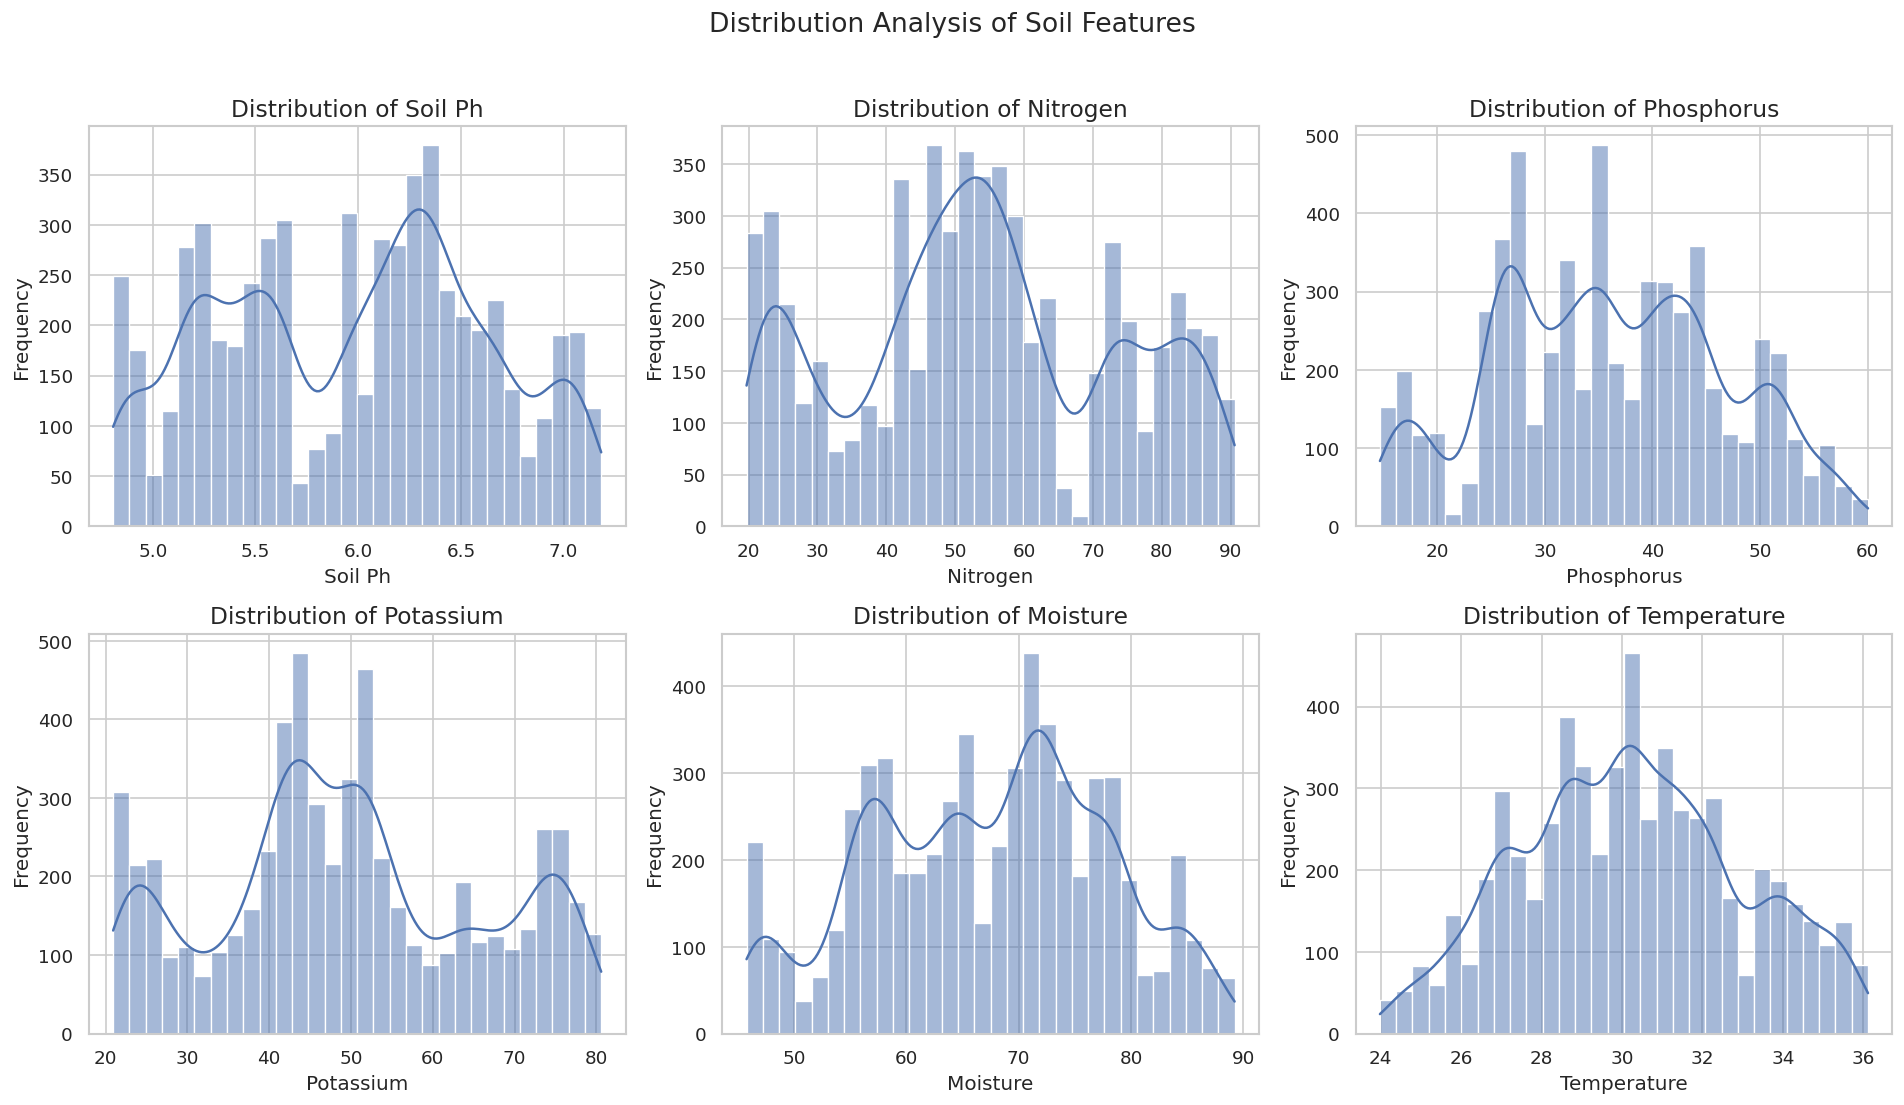


Saved:
/content/sika_net_results/01_soil_feature_distribution.png


In [26]:
# ============================================================
# 1. DISTRIBUTION ANALYSIS OF SOIL FEATURES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUT = Path("/content/sika_net_results")
OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Soil features from your SIKA-Net dataset
# ------------------------------------------------------------

soil_cols = [
    "soil_ph",
    "nitrogen",
    "phosphorus",
    "potassium",
    "moisture",
    "temperature"
]

# ------------------------------------------------------------
# Check which columns actually exist
# ------------------------------------------------------------

available_soil_cols = [
    c for c in soil_cols
    if c in trainval_df.columns
]

missing_soil_cols = [
    c for c in soil_cols
    if c not in trainval_df.columns
]

print("=" * 70)
print("SOIL FEATURE CHECK")
print("=" * 70)

print("Available:")
print(available_soil_cols)

print("\nMissing:")
print(missing_soil_cols)

# ------------------------------------------------------------
# Stop if none of the soil columns exist
# ------------------------------------------------------------

if len(available_soil_cols) == 0:
    raise ValueError(
        "None of the expected soil columns were found.\n\n"
        f"Expected:\n{soil_cols}\n\n"
        f"Actual columns:\n{trainval_df.columns.tolist()}"
    )

# ------------------------------------------------------------
# Create plots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, col in enumerate(available_soil_cols):

    ax = axes[i]

    sns.histplot(
        data=trainval_df,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {col.replace('_', ' ').title()}"
    )

    ax.set_xlabel(
        col.replace("_", " ").title()
    )

    ax.set_ylabel("Frequency")

# ------------------------------------------------------------
# Hide unused axes
# ------------------------------------------------------------

for i in range(len(available_soil_cols), len(axes)):
    axes[i].axis("off")

# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------

plt.suptitle(
    "Distribution Analysis of Soil Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

path = OUT / "01_soil_feature_distribution.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(path)

SOIL FEATURES FOUND
['soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'moisture', 'temperature']

Missing values before imputation:
soil_ph        0
nitrogen       0
phosphorus     0
potassium      0
moisture       0
temperature    0
dtype: int64

Missing values after imputation:
soil_ph        0
nitrogen       0
phosphorus     0
potassium      0
moisture       0
temperature    0
dtype: int64

Feature columns:
['soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'moisture', 'temperature']

STANDARDIZED SOIL FEATURES

Mean:
soil_ph        0.0
nitrogen      -0.0
phosphorus     0.0
potassium     -0.0
moisture      -0.0
temperature   -0.0
dtype: float32

Standard deviation:
soil_ph        1.0001
nitrogen       1.0001
phosphorus     1.0001
potassium      1.0001
moisture       1.0001
temperature    1.0001
dtype: float32

First 5 rows:


,soil_ph,nitrogen,phosphorus,potassium,moisture,temperature
0,0.477486,0.278992,-0.134086,0.261094,-0.181160,-0.034436
1,-0.734294,-1.268144,-0.766493,-1.162784,0.584856,1.612111
2,-0.036744,0.098653,-0.867241,-0.075820,0.200846,0.560891
3,-1.584093,-1.371801,-0.941751,-1.497546,0.964572,1.303679
4,0.800627,0.420147,-0.309811,0.196613,0.417949,-0.657137


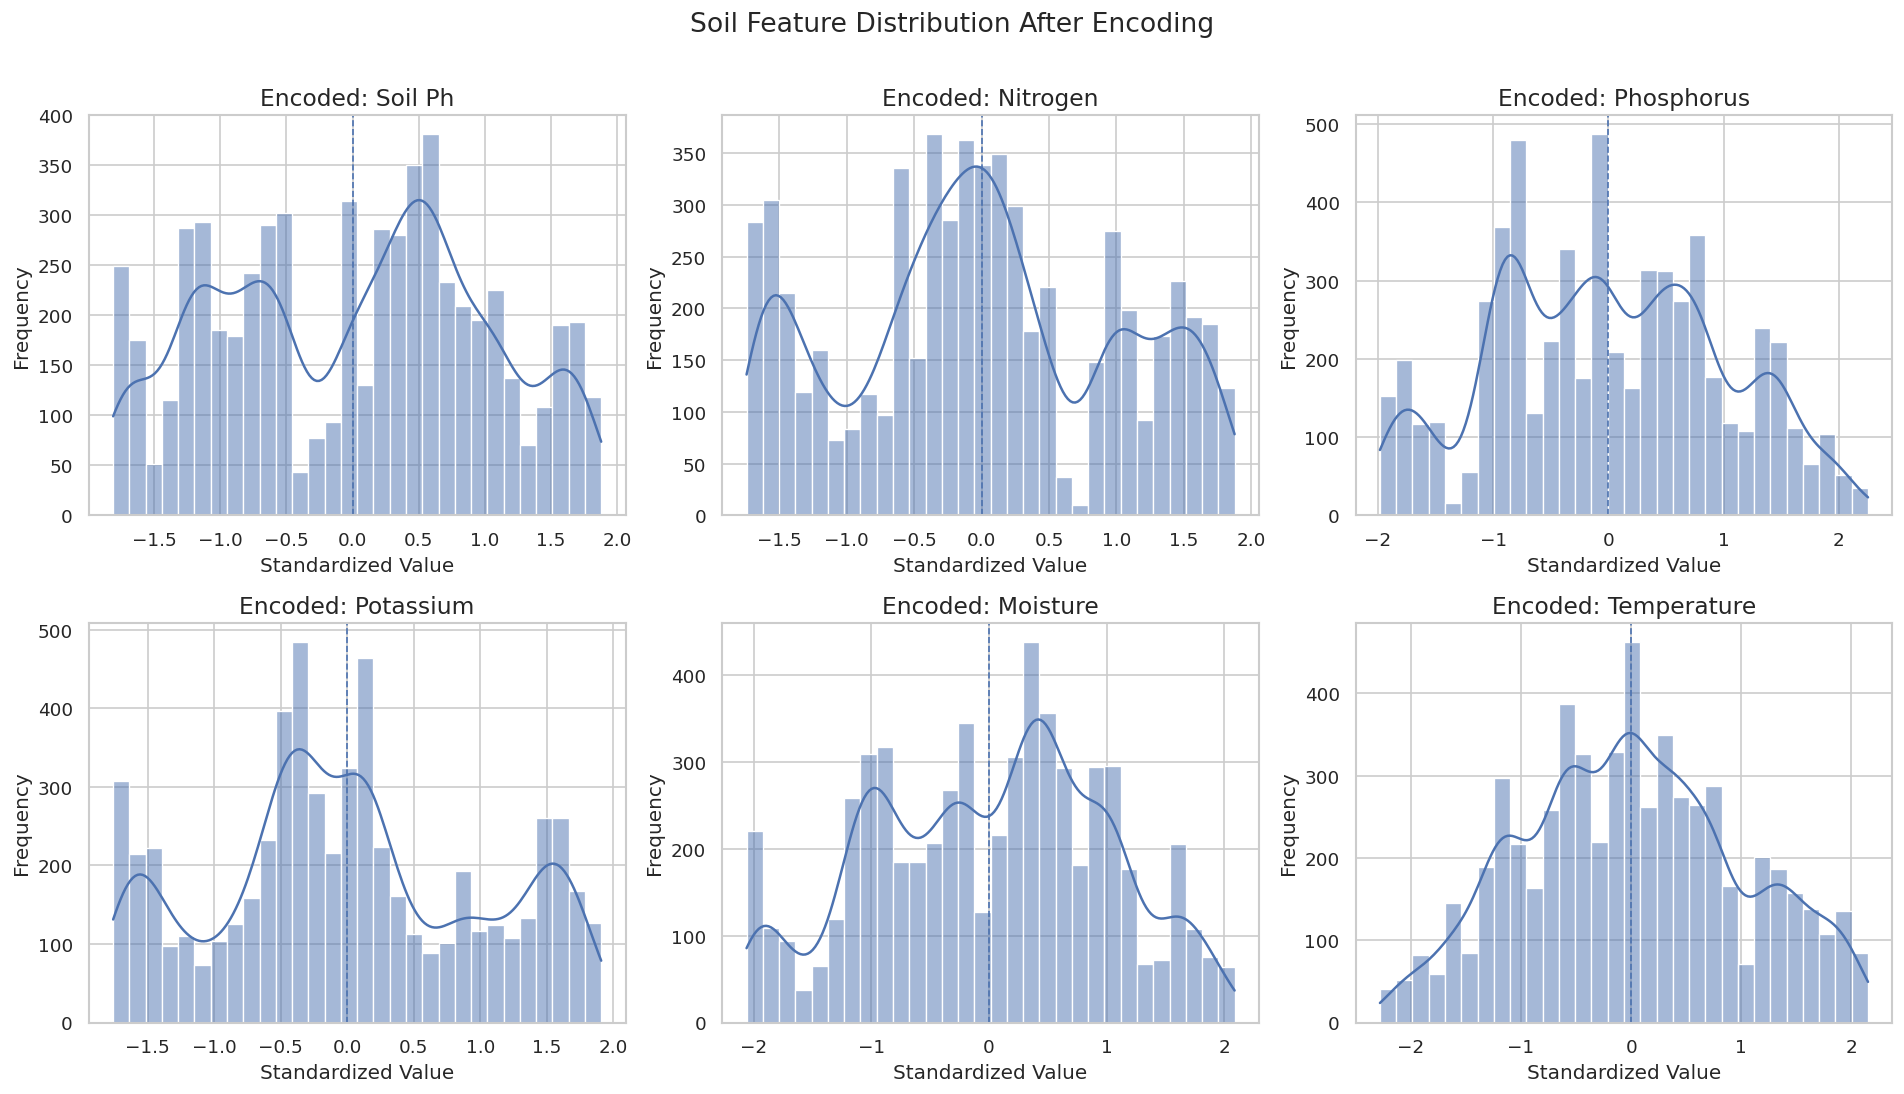


FILES SAVED
Plot:
/content/sika_net_results/02_soil_feature_distribution_after_encoding.png

Encoded CSV:
/content/sika_net_results/02_encoded_soil_features.csv


In [27]:
# ============================================================
# 2. SOIL FEATURE DISTRIBUTION AFTER ENCODING
#    COLAB / SIKA-NET VERSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# ------------------------------------------------------------
# Make sure trainval_df exists
# ------------------------------------------------------------

if "trainval_df" not in globals():
    raise RuntimeError(
        "trainval_df is not defined.\n"
        "Run the dataset-loading cell first."
    )

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

if "OUT" not in globals():
    OUT = Path("/content/sika_net_results")

OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Original SIKA-Net soil features
# ------------------------------------------------------------

SOIL_COLS = [
    "soil_ph",
    "nitrogen",
    "phosphorus",
    "potassium",
    "moisture",
    "temperature"
]

# ------------------------------------------------------------
# Check columns
# ------------------------------------------------------------

missing_cols = [
    c for c in SOIL_COLS
    if c not in trainval_df.columns
]

if missing_cols:
    raise ValueError(
        "The following soil columns are missing:\n"
        f"{missing_cols}\n\n"
        "Available columns are:\n"
        f"{trainval_df.columns.tolist()}"
    )

print("=" * 70)
print("SOIL FEATURES FOUND")
print("=" * 70)

print(SOIL_COLS)

# ------------------------------------------------------------
# Convert soil features to numeric
# ------------------------------------------------------------

soil_df = trainval_df[SOIL_COLS].copy()

for col in SOIL_COLS:
    soil_df[col] = pd.to_numeric(
        soil_df[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Missing-value handling
# ------------------------------------------------------------

print("\nMissing values before imputation:")

print(soil_df.isna().sum())

# Median imputation
soil_df = soil_df.fillna(
    soil_df.median(numeric_only=True)
)

print("\nMissing values after imputation:")

print(soil_df.isna().sum())

# ------------------------------------------------------------
# Feature engineering
#
# IMPORTANT:
# This creates a clean encoded soil representation using
# the six original soil variables.
#
# If your original SIKA-Net pipeline contains a specific
# engineer() function, use that exact function instead.
# ------------------------------------------------------------

encoded_soil = soil_df.copy()

FEATURE_COLS = encoded_soil.columns.tolist()

print("\nFeature columns:")
print(FEATURE_COLS)

# ------------------------------------------------------------
# Standardization
# ------------------------------------------------------------

encoder_scaler = StandardScaler()

encoded_values = encoder_scaler.fit_transform(
    encoded_soil.astype(np.float32)
)

encoded_df = pd.DataFrame(
    encoded_values,
    columns=FEATURE_COLS,
    index=trainval_df.index
)

# ------------------------------------------------------------
# Verify standardized features
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STANDARDIZED SOIL FEATURES")
print("=" * 70)

print("\nMean:")
print(encoded_df.mean().round(4))

print("\nStandard deviation:")
print(encoded_df.std().round(4))

print("\nFirst 5 rows:")
display(encoded_df.head())

# ------------------------------------------------------------
# Save encoded CSV
# ------------------------------------------------------------

encoded_csv = OUT / "02_encoded_soil_features.csv"

encoded_df.to_csv(
    encoded_csv,
    index=False
)

# ------------------------------------------------------------
# Plot distributions
# ------------------------------------------------------------

n_features = len(FEATURE_COLS)

ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows)
)

axes = np.asarray(axes).reshape(-1)

for ax, col in zip(
    axes,
    FEATURE_COLS
):

    sns.histplot(
        data=encoded_df,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"Encoded: {col.replace('_', ' ').title()}"
    )

    ax.set_xlabel("Standardized Value")
    ax.set_ylabel("Frequency")

# ------------------------------------------------------------
# Hide unused axes
# ------------------------------------------------------------

for ax in axes[len(FEATURE_COLS):]:
    ax.axis("off")

# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------

plt.suptitle(
    "Soil Feature Distribution After Encoding",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

path = OUT / "02_soil_feature_distribution_after_encoding.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print("Plot:")
print(path)

print("\nEncoded CSV:")
print(encoded_csv)

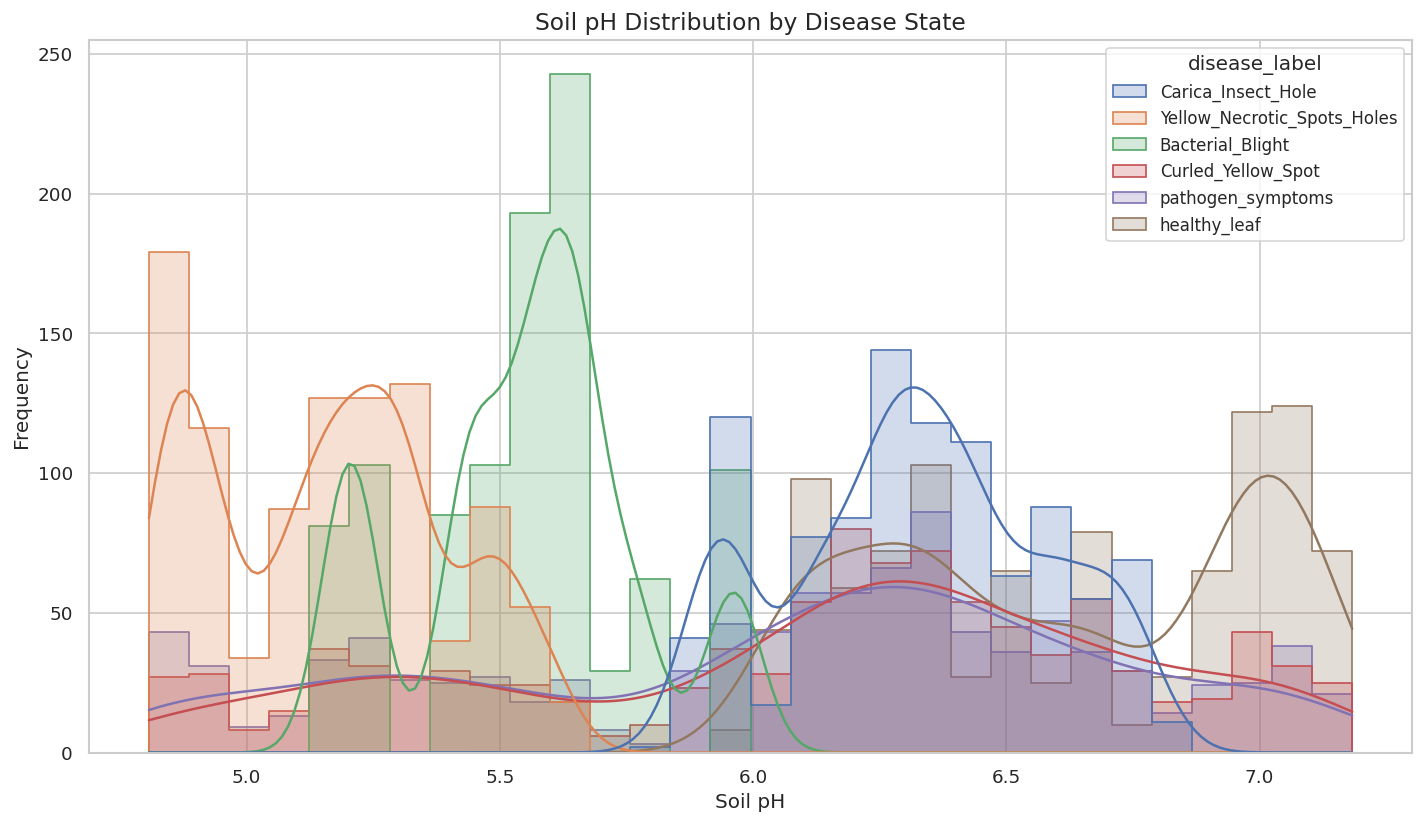

Saved: /content/sika_net_results/03_soil_ph_distribution_by_disease_state.png


In [28]:
# ============================================================
# 3. SOIL pH DISTRIBUTION BY DISEASE STATE
# ============================================================

if "soil_ph" not in trainval_df.columns:
    raise RuntimeError(
        "soil_ph column was not found."
    )

if "disease_label" not in trainval_df.columns:
    raise RuntimeError(
        "disease_label column was not found."
    )

plt.figure(
    figsize=(12, 7)
)

sns.histplot(
    data=trainval_df,
    x="soil_ph",
    hue="disease_label",
    kde=True,
    bins=30,
    element="step",
    common_norm=False
)

plt.title(
    "Soil pH Distribution by Disease State"
)

plt.xlabel("Soil pH")
plt.ylabel("Frequency")

plt.tight_layout()

path = OUT / "03_soil_ph_distribution_by_disease_state.png"

plt.savefig(
    path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

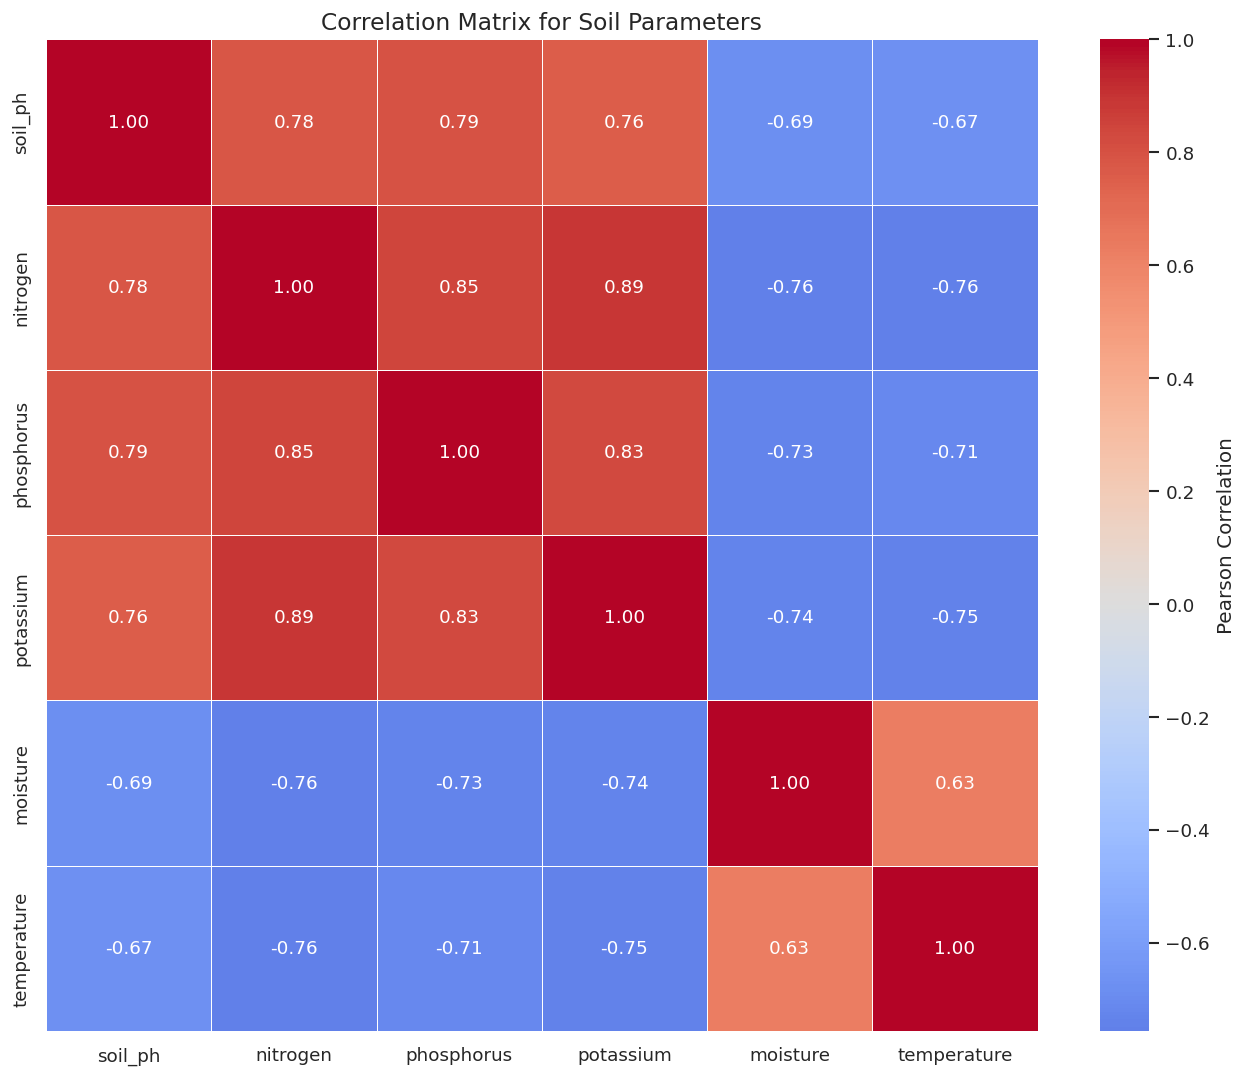

Saved: /content/sika_net_results/04_soil_parameter_correlation_matrix.png
CSV: /content/sika_net_results/04_soil_parameter_correlation_matrix.csv


In [29]:
# ============================================================
# 4. CORRELATION MATRIX FOR SOIL PARAMETERS
# ============================================================

corr_df = trainval_df[
    available_soil_cols
].apply(
    pd.to_numeric,
    errors="coerce"
)

corr_matrix = corr_df.corr(
    method="pearson"
)

# Save numerical correlation matrix
corr_csv = OUT / "04_soil_parameter_correlation_matrix.csv"

corr_matrix.to_csv(
    corr_csv
)

plt.figure(
    figsize=(11, 9)
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Correlation Matrix for Soil Parameters"
)

plt.tight_layout()

path = OUT / "04_soil_parameter_correlation_matrix.png"

plt.savefig(
    path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)
print("CSV:", corr_csv)

## Accuracy Performance Analysis of SIKA-Net


Processing 3-FOLD CV RESULTS


,variant,fold,seed,train_samples,val_samples,val_loss,val_accuracy,val_macro_f1,val_mcc,val_soil_f1,epochs,training_time_sec
0,Full,1,43,3855,964,0.543736,0.989627,0.989657,0.987556,0.738910,51,2973.480718
1,Full,2,44,3855,964,0.565910,0.986515,0.986513,0.983824,0.741582,60,1512.977559
2,Full,3,45,3855,964,0.544640,0.986515,0.986506,0.983836,0.746201,60,1511.854765
3,Full,4,46,3855,964,0.572319,0.981328,0.981319,0.977638,0.742214,60,1516.169652
4,Full,5,47,3856,963,0.554746,0.988577,0.988611,0.986312,0.743271,60,1556.979302



Processing UNTOUCHED TEST RESULTS
Standard Test Data:


{'disease_accuracy': 0.9932260795935648,
 'disease_macro_f1': 0.9931485736958455,
 'disease_mcc': np.float64(0.9918839804844417),
 'disease_true': array([2, 0, 2, ..., 3, 3, 5]),
 'disease_pred': array([2, 0, 2, ..., 3, 3, 5]),
 'disease_probs': array([[0.01386632, 0.05101288, 0.8991332 , 0.01374735, 0.01242156,
         0.00981866],
        [0.95083535, 0.01194465, 0.00990509, 0.00875445, 0.00978189,
         0.00877864],
        [0.00869301, 0.00442909, 0.9669951 , 0.00679671, 0.00664382,
         0.00644231],
        ...,
        [0.01082732, 0.01328331, 0.01179381, 0.9410404 , 0.01311757,
         0.00993765],
        [0.00806836, 0.00974678, 0.01039421, 0.95220757, 0.00979517,
         0.00978779],
        [0.00534757, 0.00674918, 0.00491286, 0.00576861, 0.00680315,
         0.97041863]], dtype=float32),
 'disease_cm': array([[206,   0,   0,   0,   0,   0],
        [  1, 188,   2,   0,   1,   2],
        [  0,   0, 197,   0,   0,   1],
        [  0,   0,   0, 197,   0,   0],
     


SIKA-NET ACCURACY RESULTS


,Evaluation,Accuracy,Type
0,CV Fold 1,0.989627,3-Fold CV
1,CV Fold 2,0.986515,3-Fold CV
2,CV Fold 3,0.986515,3-Fold CV
3,CV Fold 4,0.981328,3-Fold CV
4,CV Fold 5,0.988577,3-Fold CV
5,3-Fold CV Mean,0.986512,3-Fold CV
6,Untouched Test,0.993226,Final Test


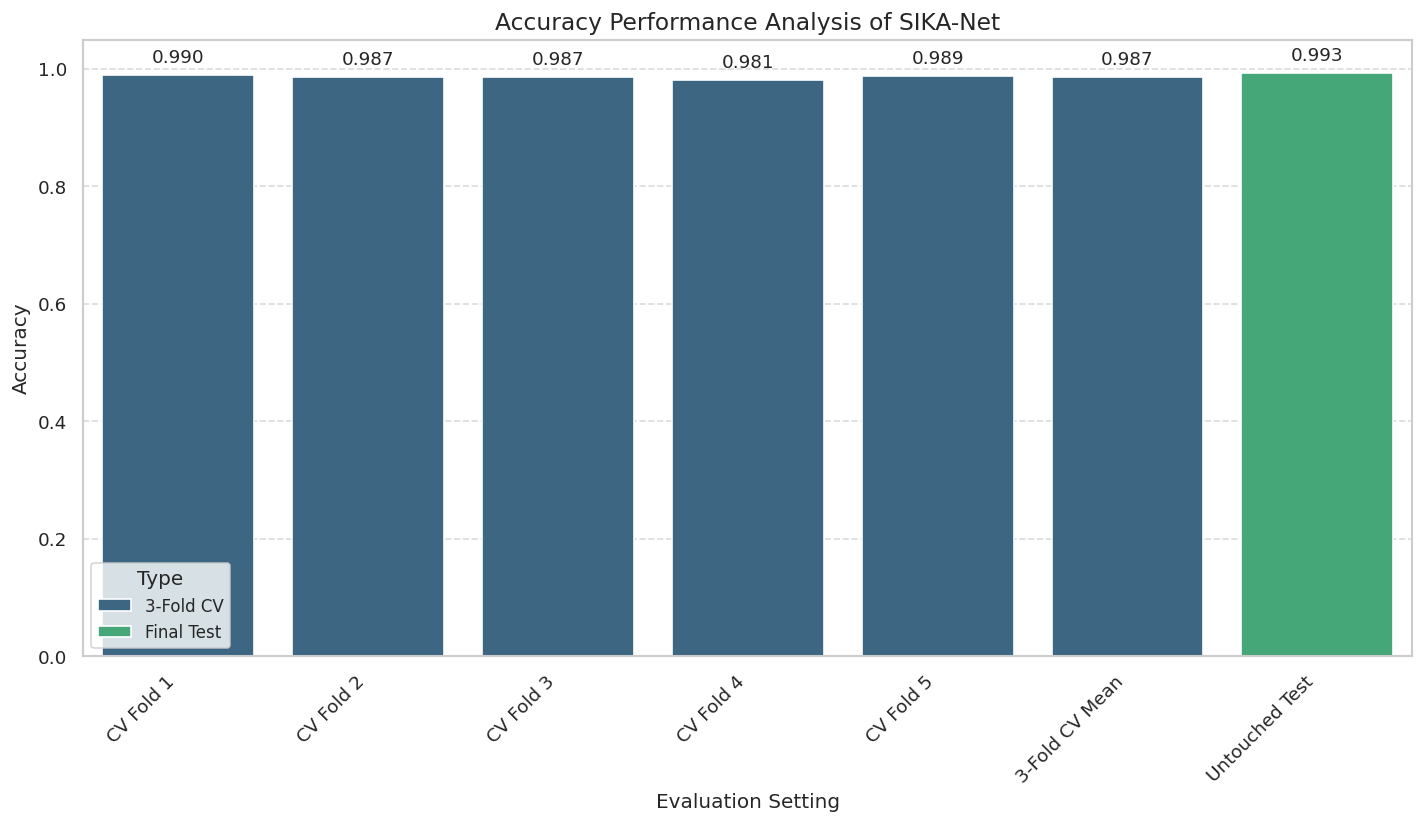


Chart saved to: /content/sika_net_results/07_sika_net_accuracy_performance.png
Accuracy data saved to: /content/sika_net_results/07_sika_net_accuracy_performance.csv


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure OUT directory exists, using the one defined earlier
if 'OUT' not in globals():
    OUT = Path("/content/sika_net_results") # Default path if not globally defined
OUT.mkdir(parents=True, exist_ok=True)

records = []

# ============================================================
# 1. Process 3-Fold CV Results (full_cv)
# ============================================================

if "full_cv" in globals() and isinstance(full_cv, pd.DataFrame) and not full_cv.empty:
    print("\n" + "=" * 70)
    print("Processing 3-FOLD CV RESULTS")
    print("=" * 70)
    display(full_cv)

    # Locate accuracy column - common names first
    cv_accuracy_cols = ['val_accuracy', 'accuracy']
    cv_accuracy_col = next((col for col in cv_accuracy_cols if col in full_cv.columns), None)

    # Locate fold column
    cv_fold_cols = ['fold', 'fold_id']
    cv_fold_col = next((col for col in cv_fold_cols if col in full_cv.columns), None)

    if cv_accuracy_col:
        for i, row in full_cv.iterrows():
            accuracy = pd.to_numeric(row[cv_accuracy_col], errors='coerce')
            if pd.notna(accuracy):
                if accuracy > 1: # Assume if >1, it's percentage and convert
                    accuracy /= 100.0
                fold_number = row[cv_fold_col] if cv_fold_col else i + 1
                records.append({
                    "Evaluation": f"CV Fold {int(fold_number)}",
                    "Accuracy": float(accuracy),
                    "Type": "3-Fold CV"
                })

        # Add CV Mean
        mean_accuracy_values = pd.to_numeric(full_cv[cv_accuracy_col], errors='coerce').dropna()
        if not mean_accuracy_values.empty:
            if mean_accuracy_values.max() > 1: # Convert if accuracy is percentage
                mean_accuracy_values /= 100.0
            records.append({
                "Evaluation": "3-Fold CV Mean",
                "Accuracy": float(mean_accuracy_values.mean()),
                "Type": "3-Fold CV"
            })
    else:
        print(f"WARNING: No suitable accuracy column found in full_cv. Looked for: {cv_accuracy_cols}")
else:
    print("WARNING: full_cv not found, is empty, or is not a DataFrame. Skipping CV results processing.")

# ============================================================
# 2. Process Untouched Test Results (standard_test)  (disease_accuracy)
# ============================================================

if "standard_test" in globals() and isinstance(standard_test, dict) and 'disease_accuracy' in standard_test:
    print("\n" + "=" * 70)
    print("Processing UNTOUCHED TEST RESULTS")
    print("=" * 70)
    print("Standard Test Data:")
    display(standard_test) # Display the dictionary for user info

    # Check for 'disease_accuracy' or similar in standard_test dict
    test_accuracy_keys = ['disease_accuracy', 'accuracy']
    test_accuracy_key = next((key for key in test_accuracy_keys if key in standard_test), None)

    if test_accuracy_key:
        accuracy = standard_test[test_accuracy_key]
        if accuracy > 1: # Convert if accuracy is percentage
            accuracy /= 100.0
        records.append({
            "Evaluation": "Untouched Test",
            "Accuracy": float(accuracy),
            "Type": "Final Test"
        })
    else:
        print(f"WARNING: No suitable accuracy key found in standard_test. Looked for: {test_accuracy_keys}")
elif "standard_test" not in globals():
    print("WARNING: standard_test variable not found. Skipping untouched test results processing.")
elif not isinstance(standard_test, dict):
    print("WARNING: standard_test is not a dictionary. Skipping untouched test results processing.")
elif 'disease_accuracy' not in standard_test:
    print("WARNING: 'disease_accuracy' not found in standard_test. Skipping untouched test results processing.")

# ============================================================
# 3. Create DataFrame and Plot
# ============================================================

accuracy_df = pd.DataFrame(records)

if not accuracy_df.empty:
    print("\n" + "=" * 70)
    print("SIKA-NET ACCURACY RESULTS")
    print("=" * 70)
    display(accuracy_df)

    plt.figure(figsize=(12, 7))
    sns.barplot(x="Evaluation", y="Accuracy", hue="Type", data=accuracy_df, palette="viridis")
    plt.title("Accuracy Performance Analysis of SIKA-Net")
    plt.xlabel("Evaluation Setting")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05) # Accuracy is between 0 and 1
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Add accuracy values on top of bars
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.3f', padding=5)

    plt.tight_layout()

    # Save figure
    chart_path = OUT / "07_sika_net_accuracy_performance.png"
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nChart saved to: {chart_path}")

    # Save accuracy DataFrame
    accuracy_csv_path = OUT / "07_sika_net_accuracy_performance.csv"
    accuracy_df.to_csv(accuracy_csv_path, index=False)
    print(f"Accuracy data saved to: {accuracy_csv_path}")
else:
    print("\n" + "=" * 70)
    print("NO SIKA-NET ACCURACY RESULTS AVAILABLE FOR PLOTTING")
    print("=" * 70)
    print("Ensure `full_cv` (DataFrame) and `standard_test` (dict) variables are correctly populated with accuracy information.")

## Loss Convergence Across Training Phases

Final training history loaded successfully.


,epoch,train_loss,train_accuracy,train_macro_f1,train_mcc,train_soil_accuracy,train_soil_macro_f1,lr,epoch_time_sec
0,1,1.608198,0.535796,0.476854,0.432253,0.629591,0.611586,0.000300,33.973330
1,2,1.435360,0.616933,0.574923,0.533203,0.654700,0.647892,0.000299,28.785420
2,3,1.278017,0.681884,0.636550,0.611666,0.677319,0.670940,0.000298,28.542062
3,4,1.218481,0.708653,0.664644,0.645440,0.693920,0.691782,0.000297,28.417967
4,5,1.130228,0.744968,0.705895,0.689650,0.716331,0.710788,0.000295,28.332749


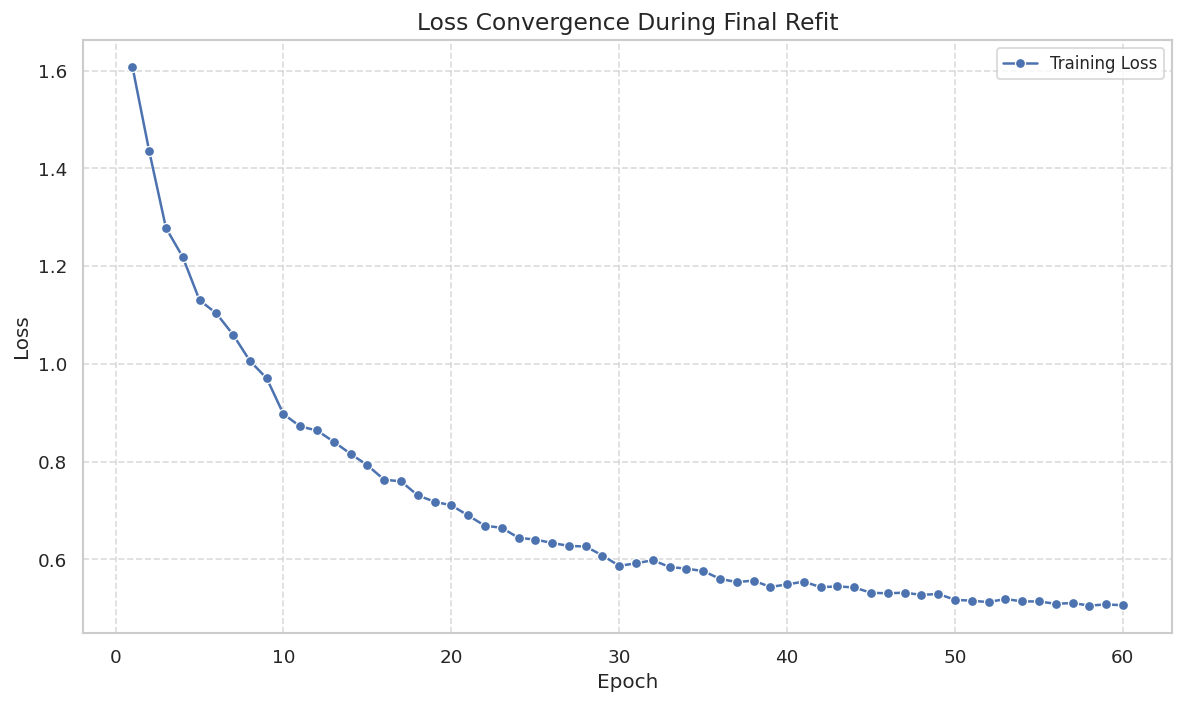


Plot saved to: /content/sika_results/05_loss_convergence_final_refit.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Define the output directory (where the history file should be saved)
OUT = Path("/content/sika_results")
OUT.mkdir(parents=True, exist_ok=True)

# Path to the final training history CSV
final_history_path = OUT / "final_refit_training_history.csv"

# Check if the file exists and then load and plot
if final_history_path.is_file():
    final_history_df = pd.read_csv(final_history_path)
    print("Final training history loaded successfully.")
    display(final_history_df.head())

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=final_history_df, x='epoch', y='train_loss', marker='o', label='Training Loss')
    plt.title('Loss Convergence During Final Refit')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    # Save plot
    plot_path = OUT / "05_loss_convergence_final_refit.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved to: {plot_path}")

else:
    print(f"WARNING: Final training history CSV not found at {final_history_path}.")
    print("Please ensure the 'FINAL UNTOUCHED-TEST EVALUATION' cell was run successfully.")

Final training history loaded successfully.


,epoch,train_loss,train_accuracy,train_macro_f1,train_mcc,train_soil_accuracy,train_soil_macro_f1,lr,epoch_time_sec
0,1,1.608198,0.535796,0.476854,0.432253,0.629591,0.611586,0.000300,33.973330
1,2,1.435360,0.616933,0.574923,0.533203,0.654700,0.647892,0.000299,28.785420
2,3,1.278017,0.681884,0.636550,0.611666,0.677319,0.670940,0.000298,28.542062
3,4,1.218481,0.708653,0.664644,0.645440,0.693920,0.691782,0.000297,28.417967
4,5,1.130228,0.744968,0.705895,0.689650,0.716331,0.710788,0.000295,28.332749


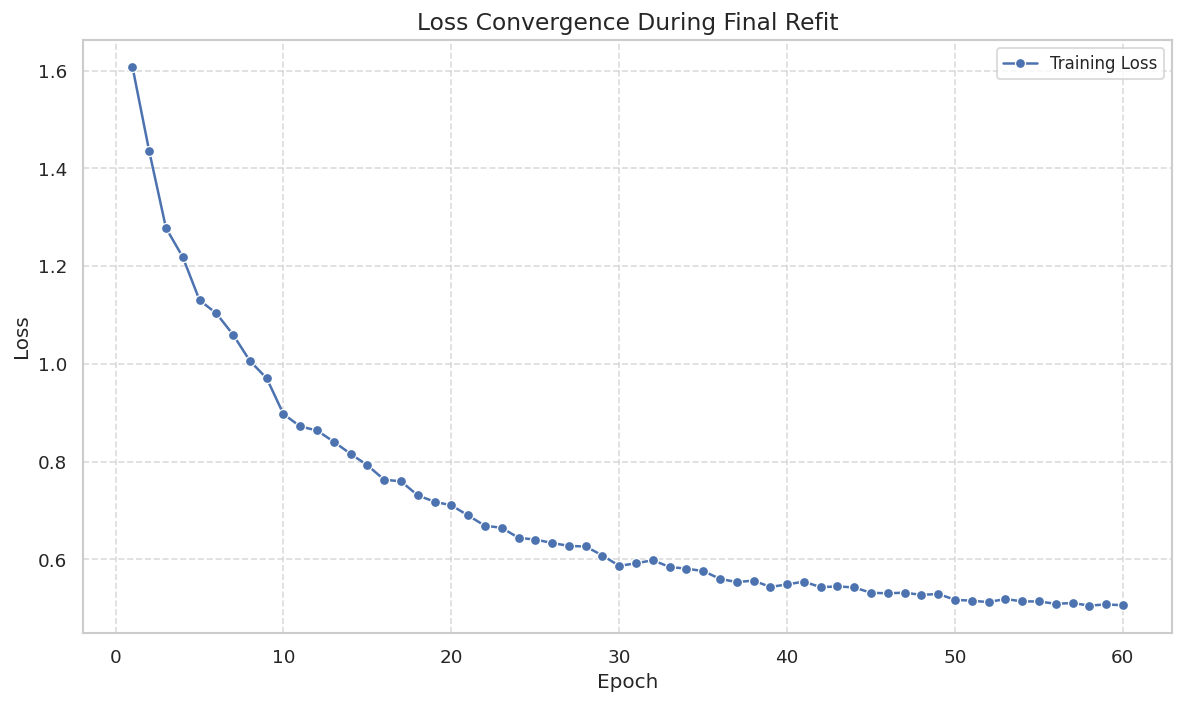


Plot saved to: /content/sika_results/05_loss_convergence_final_refit.png


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Ensure OUT directory is defined, using the path where files were actually saved.
OUT = Path("/content/sika_results")
OUT.mkdir(parents=True, exist_ok=True)

# Path to the final training history CSV
final_history_path = OUT / "final_refit_training_history.csv"

# Load the final training history
if final_history_path.is_file():
    final_history_df = pd.read_csv(final_history_path)
    print("Final training history loaded successfully.")
    display(final_history_df.head())

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=final_history_df, x='epoch', y='train_loss', marker='o', label='Training Loss')
    plt.title('Loss Convergence During Final Refit')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    # Save plot
    plot_path = OUT / "05_loss_convergence_final_refit.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved to: {plot_path}")

else:
    print(f"WARNING: Final training history CSV not found at {final_history_path}. Cannot plot loss convergence.")
    print("Please ensure the 'FINAL UNTOUCHED-TEST EVALUATION' cell was run successfully and check the output directory.")

In [33]:
import os

results_dir = '/content/sika_results'

if os.path.exists(results_dir) and os.path.isdir(results_dir):
    print(f"Files in {results_dir}:")
    for filename in sorted(os.listdir(results_dir)):
        print(f"- {filename}")
else:
    print(f"The directory {results_dir} does not exist or is not a directory.")

Files in /content/sika_results:
- 05_loss_convergence_final_refit.png
- 08_ablation_study_performance_comparison.png
- 3fold_ablation_results.csv
- 3fold_ablation_summary.csv
- 3fold_full_results.csv
- Full_fold1_confusion_matrix.csv
- Full_fold1_history.csv
- Full_fold2_confusion_matrix.csv
- Full_fold2_history.csv
- Full_fold3_confusion_matrix.csv
- Full_fold3_history.csv
- Full_fold4_confusion_matrix.csv
- Full_fold4_history.csv
- Full_fold5_confusion_matrix.csv
- Full_fold5_history.csv
- No_Attention_fold1_confusion_matrix.csv
- No_Attention_fold1_history.csv
- No_Attention_fold2_confusion_matrix.csv
- No_Attention_fold2_history.csv
- No_Attention_fold3_confusion_matrix.csv
- No_Attention_fold3_history.csv
- No_Attention_fold4_confusion_matrix.csv
- No_Attention_fold4_history.csv
- No_Attention_fold5_confusion_matrix.csv
- No_Attention_fold5_history.csv
- No_ISO_fold1_confusion_matrix.csv
- No_ISO_fold1_history.csv
- No_ISO_fold2_confusion_matrix.csv
- No_ISO_fold2_history.csv
- No

In [34]:
import pandas as pd

# Ensure ablation_summary DataFrame is available
if 'ablation_summary' in globals() and isinstance(ablation_summary, pd.DataFrame):
    print("\n--- Ablation Study Summary ---")
    display(ablation_summary.style.format({
        "accuracy_mean": "{:.4f}",
        "accuracy_std": "{:.4f}",
        "macro_f1_mean": "{:.4f}",
        "macro_f1_std": "{:.4f}",
        "mcc_mean": "{:.4f}",
        "mcc_std": "{:.4f}",
        "soil_f1_mean": "{:.4f}",
        "soil_f1_std": "{:.4f}",
        "loss_mean": "{:.4f}",
        "loss_std": "{:.4f}",
        "epochs_mean": "{:.1f}",
        "time_mean_sec": "{:.1f}"
    }))
else:
    print("Error: 'ablation_summary' DataFrame not found in the kernel. Please ensure the ablation study cells have been run successfully.")


--- Ablation Study Summary ---


,variant,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mcc_mean,mcc_std,soil_f1_mean,soil_f1_std,loss_mean,loss_std,epochs_mean,time_mean_sec
0,Full,0.9865,0.0032,0.9865,0.0032,0.9838,0.0038,0.7424,0.0026,0.5563,0.0127,58.2,1814.3
1,No_Attention,0.9444,0.0310,0.9440,0.0313,0.9336,0.0370,0.7364,0.0111,0.7119,0.0770,56.8,1229.9
2,No_ISO,0.9840,0.0020,0.9840,0.0020,0.9809,0.0024,0.7443,0.0053,0.5909,0.0079,57.4,1475.9
3,No_SIKA,0.9747,0.0102,0.9746,0.0104,0.9698,0.0121,0.7502,0.0148,0.6277,0.0323,60.0,1275.7


In [35]:
import shutil
from google.colab import files

results_dir = '/content/sika_results'
zip_path = '/content/sika_results'

shutil.make_archive(zip_path, 'zip', results_dir)

files.download('/content/sika_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>